In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

file_path = Path.home() / "Downloads" / "wgidataset_with_sourcedata-2025.xlsx"

df = pd.read_excel(file_path, sheet_name="Feuil2")

print(df.head())
print(df.columns)

   Year        CC        rl        rq        ge        pv        va  \
0  1996 -0.105042  0.436313 -0.362897 -0.002761 -0.392173 -0.657704   
1  1997 -0.120000  0.450000 -0.300000  0.000000 -0.290000 -0.630000   
2  1998 -0.090658  0.252351 -0.022928 -0.006963 -0.008786 -0.456582   
3  2000 -0.283116  0.214198 -0.020139 -0.005510 -0.378918 -0.703345   
4  2002 -0.123071 -0.158080 -0.239043 -0.267586 -0.308378 -0.592418   

   indice gouv  fdi (% du PIB)           FDI   LOG FDI   gov pol  gov inst  
0    -0.180711        0.828037  3.573938e+08  8.553147 -0.524938 -0.008597  
1    -0.148333        2.757090  1.079341e+09  9.033159 -0.460000  0.007500  
2    -0.055594        0.663931  3.087122e+08  8.489554 -0.232684  0.032951  
3    -0.196138        1.787417  8.269740e+08  8.917492 -0.541132 -0.023642  
4    -0.281429        0.991582  4.265533e+08  8.629973 -0.450398 -0.196945  
Index(['Year', 'CC', 'rl', 'rq', 'ge', 'pv', 'va', 'indice gouv',
       'fdi (% du PIB)', 'FDI', 'LOG FDI', 'g

In [2]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(%_du_pib)", "pct_pib", regex=False)
)

print(df.columns)

Index(['year', 'cc', 'rl', 'rq', 'ge', 'pv', 'va', 'indice_gouv',
       'fdi_pct_pib', 'fdi', 'log_fdi', 'gov_pol', 'gov_inst'],
      dtype='object')


In [3]:
df["lide"] = np.log(df["ide"])

df["change_instab"] = abs(100 * (df["change"] / df["change"].shift(1) - 1))

model_base = df[["year", "lide", "frazer", "change_instab", "gdp", "open_services"]].copy()

for c in ["year", "lide", "frazer", "change_instab", "gdp", "open_services"]:
    model_base[c] = pd.to_numeric(model_base[c], errors="coerce")

model_base = model_base.dropna()
model_base["year"] = model_base["year"].astype(int)
model_base = model_base.set_index("year")

print(model_base.head(10))
print(model_base.shape)

KeyError: 'ide'

In [4]:
print(df.columns.tolist())

['year', 'cc', 'rl', 'rq', 'ge', 'pv', 'va', 'indice_gouv', 'fdi_pct_pib', 'fdi', 'log_fdi', 'gov_pol', 'gov_inst']


In [5]:
import pandas as pd
import numpy as np
from pathlib import Path

file_path = Path.home() / "Downloads" / "wgidataset_with_sourcedata-2025.xlsx"

df = pd.read_excel(file_path, sheet_name="Feuil2")

# Nettoyage robuste des noms de colonnes
df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("%", "pct", regex=False)
)

print(df.columns.tolist())
print(df.shape)

['year', 'cc', 'rl', 'rq', 'ge', 'pv', 'va', 'indice_gouv', 'fdi_pct_du_pib', 'fdi', 'log_fdi', 'gov_pol', 'gov_inst']
(27, 13)


In [6]:
# LIDE = log(IDE)
df["lide"] = np.log(df["ide"])

# Instabilité du taux de change
df["change_instab"] = abs(100 * (df["change"] / df["change"].shift(1) - 1))

# Base finale du modèle ARDL validé
model_base = df[["year", "lide", "frazer", "change_instab", "gdp", "open_services"]].copy()

for c in ["year", "lide", "frazer", "change_instab", "gdp", "open_services"]:
    model_base[c] = pd.to_numeric(model_base[c], errors="coerce")

model_base = model_base.dropna()
model_base["year"] = model_base["year"].astype(int)
model_base = model_base.set_index("year")

print(model_base.head(10))
print(model_base.shape)

KeyError: 'ide'

In [7]:
df["lide"] = df["log_fdi"]

In [8]:
import pandas as pd
import numpy as np
from pathlib import Path

file_path = Path.home() / "Downloads" / "wgidataset_with_sourcedata-2025.xlsx"

df = pd.read_excel(file_path, sheet_name="Feuil2", header=0)

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("%", "pct", regex=False)
)

print(df.columns.tolist())
print(df.shape)

['year', 'cc', 'rl', 'rq', 'ge', 'pv', 'va', 'indice_gouv', 'fdi_pct_du_pib', 'fdi', 'log_fdi', 'gov_pol', 'gov_inst']
(27, 13)


In [9]:
df["lide"] = np.log(df["ide"])
df["change_instab"] = abs(100 * (df["change"] / df["change"].shift(1) - 1))

model_base = df[["year", "lide", "frazer", "change_instab", "gdp", "open_services"]].copy()

for c in ["year", "lide", "frazer", "change_instab", "gdp", "open_services"]:
    model_base[c] = pd.to_numeric(model_base[c], errors="coerce")

model_base = model_base.dropna()
model_base["year"] = model_base["year"].astype(int)
model_base = model_base.set_index("year")

print(model_base.head(10))
print(model_base.shape)

KeyError: 'ide'

In [10]:
import pandas as pd
import numpy as np
from pathlib import Path

# Chemin du fichier
file_path = Path.home() / "Downloads" / "wgidataset_with_sourcedata-2025.xlsx"

# Lire la feuille complète
df = pd.read_excel(file_path, sheet_name="Feuil2")

# Nettoyer les noms des colonnes
df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("%", "pct", regex=False)
)

print("Colonnes après nettoyage :")
print(df.columns.tolist())
print("Shape :", df.shape)

Colonnes après nettoyage :
['year', 'cc', 'rl', 'rq', 'ge', 'pv', 'va', 'indice_gouv', 'fdi_pct_du_pib', 'fdi', 'log_fdi', 'gov_pol', 'gov_inst']
Shape : (27, 13)


In [11]:
# Créer les variables du modèle validé
df["lide"] = np.log(df["ide"])

df["change_instab"] = abs(
    100 * (df["change"] / df["change"].shift(1) - 1)
)

# Base finale du modèle
model_base = df[["year", "lide", "frazer", "change_instab", "gdp", "open_services"]].copy()

for c in ["year", "lide", "frazer", "change_instab", "gdp", "open_services"]:
    model_base[c] = pd.to_numeric(model_base[c], errors="coerce")

model_base = model_base.dropna()
model_base["year"] = model_base["year"].astype(int)
model_base = model_base.set_index("year")

print(model_base.head(10))
print(model_base.shape)

KeyError: 'ide'

In [12]:
import pandas as pd
from pathlib import Path

# Essaie d'abord dans Dashboard_ARDL
folder = Path.home() / "Downloads" / "Dashboard_ARDL"

if (folder / "ardl_data.csv").exists():
    model_base = pd.read_csv(folder / "ardl_data.csv")
else:
    # Sinon essaie directement dans Downloads
    folder = Path.home() / "Downloads"
    model_base = pd.read_csv(folder / "ardl_data.csv")

print("Fichier utilisé :", folder / "ardl_data.csv")
print(model_base.head())
print(model_base.columns.tolist())
print(model_base.shape)

Fichier utilisé : C:\Users\dell\Downloads\Dashboard_ARDL\ardl_data.csv
   year       lide  frazer  change_instab       gdp  open_services        ce
0  1995  19.628948    5.69       0.219941  1.900000      11.980000 -0.281479
1  1996  19.694349    5.66       0.769527  1.110732      12.081366 -0.181533
2  1997  20.799616    5.65       0.339567  2.237249      12.542441  0.753576
3  1998  19.547582    5.70       2.664699  3.503266      11.991741 -0.741671
4  2000  20.533284    5.72       0.002328  3.300539      12.871254  0.350294
['year', 'lide', 'frazer', 'change_instab', 'gdp', 'open_services', 'ce']
(29, 7)


In [13]:
model_base["year"] = model_base["year"].astype(int)
model_base = model_base.set_index("year")

y = model_base["lide"]
X_base = model_base[["frazer", "change_instab", "gdp", "open_services"]]

print(model_base.head())
print(model_base.shape)

           lide  frazer  change_instab       gdp  open_services        ce
year                                                                     
1995  19.628948    5.69       0.219941  1.900000      11.980000 -0.281479
1996  19.694349    5.66       0.769527  1.110732      12.081366 -0.181533
1997  20.799616    5.65       0.339567  2.237249      12.542441  0.753576
1998  19.547582    5.70       2.664699  3.503266      11.991741 -0.741671
2000  20.533284    5.72       0.002328  3.300539      12.871254  0.350294
(29, 6)


In [14]:
print(model_base.head())
print(model_base.columns.tolist())
print(model_base.shape)

           lide  frazer  change_instab       gdp  open_services        ce
year                                                                     
1995  19.628948    5.69       0.219941  1.900000      11.980000 -0.281479
1996  19.694349    5.66       0.769527  1.110732      12.081366 -0.181533
1997  20.799616    5.65       0.339567  2.237249      12.542441  0.753576
1998  19.547582    5.70       2.664699  3.503266      11.991741 -0.741671
2000  20.533284    5.72       0.002328  3.300539      12.871254  0.350294
['lide', 'frazer', 'change_instab', 'gdp', 'open_services', 'ce']
(29, 6)


In [15]:
y = model_base["lide"]
X_base = model_base[["frazer", "change_instab", "gdp", "open_services"]]

In [16]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from statsmodels.tsa.ardl import ARDL

def longrun_coef_delta(res, y_name="lide", x_name="frazer"):
    """
    Calcule le coefficient de long terme de x_name dans un modèle ARDL,
    avec erreur standard, z-stat et p-value approximative.
    """
    params = res.params
    cov = res.cov_params()
    
    # Retards de la variable dépendante
    ar_names = [name for name in params.index if name.startswith(f"{y_name}.L")]
    
    # Retards de la variable explicative ciblée
    x_names = [name for name in params.index if name.startswith(f"{x_name}.L")]
    
    if len(x_names) == 0:
        return np.nan, np.nan, np.nan, np.nan
    
    # Dénominateur de long terme
    A = 1 - params[ar_names].sum() if len(ar_names) > 0 else 1
    
    # Numérateur de long terme
    B = params[x_names].sum()
    
    lr = B / A
    
    # Méthode delta
    grad = pd.Series(0.0, index=params.index)
    
    for xn in x_names:
        grad[xn] = 1 / A
    
    for an in ar_names:
        grad[an] = B / (A ** 2)
    
    var_lr = float(grad.T @ cov @ grad)
    se_lr = np.sqrt(var_lr) if var_lr >= 0 else np.nan
    
    z_stat = lr / se_lr if se_lr and se_lr > 0 else np.nan
    p_value = 2 * (1 - norm.cdf(abs(z_stat))) if not np.isnan(z_stat) else np.nan
    
    return lr, se_lr, z_stat, p_value

In [17]:
results = []

for p in [1, 2]:
    for q_frazer in [0, 1, 2, 3]:
        for q_change in [0, 1, 2]:
            for q_gdp in [0, 1, 2, 3]:
                for q_open in [0, 1, 2, 3]:
                    
                    try:
                        model = ARDL(
                            endog=y,
                            lags=p,
                            exog=X_base,
                            order={
                                "frazer": q_frazer,
                                "change_instab": q_change,
                                "gdp": q_gdp,
                                "open_services": q_open
                            },
                            trend="c"
                        )
                        
                        res = model.fit()
                        
                        lr_frazer_alt, se_frazer_alt, z_frazer_alt, p_frazer_alt = longrun_coef_delta(
                            res,
                            y_name="lide",
                            x_name="frazer"
                        )
                        
                        results.append({
                            "model": f"ARDL({p},{q_frazer},{q_change},{q_gdp},{q_open})",
                            "p_lide": p,
                            "q_frazer": q_frazer,
                            "q_change": q_change,
                            "q_gdp": q_gdp,
                            "q_open": q_open,
                            "AIC": res.aic,
                            "BIC": res.bic,
                            "FRAZER_LR": lr_frazer_alt,
                            "FRAZER_SE": se_frazer_alt,
                            "FRAZER_z": z_frazer_alt,
                            "FRAZER_pvalue": p_frazer_alt,
                            "FRAZER_positive": lr_frazer_alt > 0,
                            "FRAZER_significant_5pct": p_frazer_alt < 0.05,
                            "FRAZER_significant_10pct": p_frazer_alt < 0.10,
                            "nobs": res.nobs
                        })
                        
                    except Exception:
                        pass

search_results = pd.DataFrame(results)
search_results = search_results.sort_values("AIC")

print(search_results.shape)
display(search_results.head(20))

C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecast

(384, 16)


C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecast

,model,p_lide,q_frazer,q_change,q_gdp,q_open,AIC,BIC,FRAZER_LR,FRAZER_SE,FRAZER_z,FRAZER_pvalue,FRAZER_positive,FRAZER_significant_5pct,FRAZER_significant_10pct,nobs
383,"ARDL(2,3,2,3,3)",2,3,2,3,3,25.404949,50.025850,-0.175676,0.451883,-0.388764,0.697451,False,False,False,27
382,"ARDL(2,3,2,3,2)",2,3,2,3,2,26.949692,50.274756,0.080245,0.417509,0.192200,0.847586,True,False,False,27
174,"ARDL(1,3,1,3,2)",1,3,1,3,2,28.808868,50.124140,-0.195826,0.519296,-0.377098,0.706101,False,False,False,28
366,"ARDL(2,3,1,3,2)",2,3,1,3,2,29.109443,51.138670,0.005943,0.443104,0.013413,0.989298,True,False,False,27
367,"ARDL(2,3,1,3,3)",2,3,1,3,3,29.125188,52.450251,-0.215124,0.499593,-0.430599,0.666760,False,False,False,27
190,"ARDL(1,3,2,3,2)",1,3,2,3,2,29.804089,52.451566,-0.211986,0.559661,-0.378776,0.704854,False,False,False,28
175,"ARDL(1,3,1,3,3)",1,3,1,3,3,30.334640,52.982116,-0.364589,0.670464,-0.543786,0.586589,False,False,False,28
191,"ARDL(1,3,2,3,3)",1,3,2,3,3,31.347724,55.327405,-0.381494,0.725592,-0.525770,0.599048,False,False,False,28
335,"ARDL(2,2,2,3,3)",2,2,2,3,3,33.091436,56.416500,-0.169578,0.539963,-0.314054,0.753480,False,False,False,27
334,"ARDL(2,2,2,3,2)",2,2,2,3,2,33.176145,55.205372,0.075202,0.486352,0.154625,0.877117,True,False,False,27


In [18]:
print(search_results.shape)
search_results.head(20)

(384, 16)


,model,p_lide,q_frazer,q_change,q_gdp,q_open,AIC,BIC,FRAZER_LR,FRAZER_SE,FRAZER_z,FRAZER_pvalue,FRAZER_positive,FRAZER_significant_5pct,FRAZER_significant_10pct,nobs
383,"ARDL(2,3,2,3,3)",2,3,2,3,3,25.404949,50.025850,-0.175676,0.451883,-0.388764,0.697451,False,False,False,27
382,"ARDL(2,3,2,3,2)",2,3,2,3,2,26.949692,50.274756,0.080245,0.417509,0.192200,0.847586,True,False,False,27
174,"ARDL(1,3,1,3,2)",1,3,1,3,2,28.808868,50.124140,-0.195826,0.519296,-0.377098,0.706101,False,False,False,28
366,"ARDL(2,3,1,3,2)",2,3,1,3,2,29.109443,51.138670,0.005943,0.443104,0.013413,0.989298,True,False,False,27
367,"ARDL(2,3,1,3,3)",2,3,1,3,3,29.125188,52.450251,-0.215124,0.499593,-0.430599,0.666760,False,False,False,27
190,"ARDL(1,3,2,3,2)",1,3,2,3,2,29.804089,52.451566,-0.211986,0.559661,-0.378776,0.704854,False,False,False,28
175,"ARDL(1,3,1,3,3)",1,3,1,3,3,30.334640,52.982116,-0.364589,0.670464,-0.543786,0.586589,False,False,False,28
191,"ARDL(1,3,2,3,3)",1,3,2,3,3,31.347724,55.327405,-0.381494,0.725592,-0.525770,0.599048,False,False,False,28
335,"ARDL(2,2,2,3,3)",2,2,2,3,3,33.091436,56.416500,-0.169578,0.539963,-0.314054,0.753480,False,False,False,27
334,"ARDL(2,2,2,3,2)",2,2,2,3,2,33.176145,55.205372,0.075202,0.486352,0.154625,0.877117,True,False,False,27


In [19]:
frazer_positive = search_results[
    search_results["FRAZER_positive"] == True
].sort_values("AIC")

display(frazer_positive.head(30))

,model,p_lide,q_frazer,q_change,q_gdp,q_open,AIC,BIC,FRAZER_LR,FRAZER_SE,FRAZER_z,FRAZER_pvalue,FRAZER_positive,FRAZER_significant_5pct,FRAZER_significant_10pct,nobs
382,"ARDL(2,3,2,3,2)",2,3,2,3,2,26.949692,50.274756,0.080245,0.417509,0.192200,0.847586,True,False,False,27
366,"ARDL(2,3,1,3,2)",2,3,1,3,2,29.109443,51.138670,0.005943,0.443104,0.013413,0.989298,True,False,False,27
334,"ARDL(2,2,2,3,2)",2,2,2,3,2,33.176145,55.205372,0.075202,0.486352,0.154625,0.877117,True,False,False,27
318,"ARDL(2,2,1,3,2)",2,2,1,3,2,33.775282,54.508672,0.004341,0.501892,0.008649,0.993099,True,False,False,27
125,"ARDL(1,2,1,3,1)",1,2,1,3,1,38.902258,57.553122,0.528897,0.577656,0.915591,0.359881,True,False,False,28
173,"ARDL(1,3,1,3,1)",1,3,1,3,1,39.794231,59.777299,0.658112,0.594344,1.107290,0.268168,True,False,False,28
141,"ARDL(1,2,2,3,1)",1,2,2,3,1,40.476293,60.459361,0.535094,0.626574,0.854001,0.393105,True,False,False,28
317,"ARDL(2,2,1,3,1)",2,2,1,3,1,40.631121,60.068674,0.636379,0.509539,1.248931,0.211690,True,False,False,27
189,"ARDL(1,3,2,3,1)",1,3,2,3,1,41.158089,62.473361,0.684085,0.648947,1.054146,0.291816,True,False,False,28
333,"ARDL(2,2,2,3,1)",2,2,2,3,1,41.203192,61.936582,0.706825,0.507497,1.392768,0.163690,True,False,False,27


In [20]:
frazer_positive_sig_10 = search_results[
    (search_results["FRAZER_positive"] == True) &
    (search_results["FRAZER_significant_10pct"] == True)
].sort_values("AIC")

display(frazer_positive_sig_10)

,model,p_lide,q_frazer,q_change,q_gdp,q_open,AIC,BIC,FRAZER_LR,FRAZER_SE,FRAZER_z,FRAZER_pvalue,FRAZER_positive,FRAZER_significant_5pct,FRAZER_significant_10pct,nobs
124,"ARDL(1,2,1,3,0)",1,2,1,3,0,45.322481,62.641139,1.276207,0.659960,1.933762,0.053142,True,False,True,28
160,"ARDL(1,3,1,0,0)",1,3,1,0,0,45.464115,60.118364,1.421139,0.667987,2.127494,0.033379,True,True,True,28
112,"ARDL(1,2,1,0,0)",1,2,1,0,0,46.555821,59.877866,1.199903,0.560888,2.139291,0.032412,True,True,True,28
172,"ARDL(1,3,1,3,0)",1,3,1,3,0,47.195216,65.846079,1.343949,0.727596,1.847108,0.064732,True,False,True,28
176,"ARDL(1,3,2,0,0)",1,3,2,0,0,47.463368,63.449822,1.418619,0.699373,2.028415,0.042518,True,True,True,28
164,"ARDL(1,3,1,1,0)",1,3,1,1,0,47.463855,63.450309,1.425141,0.768779,1.853773,0.063772,True,False,True,28
28,"ARDL(1,0,1,3,0)",1,0,1,3,0,47.623425,62.277675,0.890580,0.529213,1.682838,0.092407,True,False,True,28
116,"ARDL(1,2,1,1,0)",1,2,1,1,0,48.498722,63.152972,1.144932,0.647188,1.769089,0.076879,True,False,True,28
128,"ARDL(1,2,2,0,0)",1,2,2,0,0,48.555439,63.209689,1.201510,0.587882,2.043796,0.040974,True,True,True,28
44,"ARDL(1,0,2,3,0)",1,0,2,3,0,48.818725,64.805180,0.842293,0.505135,1.667461,0.095423,True,False,True,28


In [21]:
frazer_positive_sig_5 = search_results[
    (search_results["FRAZER_positive"] == True) &
    (search_results["FRAZER_significant_5pct"] == True)
].sort_values("AIC")

display(frazer_positive_sig_5)

,model,p_lide,q_frazer,q_change,q_gdp,q_open,AIC,BIC,FRAZER_LR,FRAZER_SE,FRAZER_z,FRAZER_pvalue,FRAZER_positive,FRAZER_significant_5pct,FRAZER_significant_10pct,nobs
160,"ARDL(1,3,1,0,0)",1,3,1,0,0,45.464115,60.118364,1.421139,0.667987,2.127494,0.033379,True,True,True,28
112,"ARDL(1,2,1,0,0)",1,2,1,0,0,46.555821,59.877866,1.199903,0.560888,2.139291,0.032412,True,True,True,28
176,"ARDL(1,3,2,0,0)",1,3,2,0,0,47.463368,63.449822,1.418619,0.699373,2.028415,0.042518,True,True,True,28
128,"ARDL(1,2,2,0,0)",1,2,2,0,0,48.555439,63.209689,1.201510,0.587882,2.043796,0.040974,True,True,True,28


In [22]:
search_results[search_results["model"] == "ARDL(2,3,2,3,3)"]

,model,p_lide,q_frazer,q_change,q_gdp,q_open,AIC,BIC,FRAZER_LR,FRAZER_SE,FRAZER_z,FRAZER_pvalue,FRAZER_positive,FRAZER_significant_5pct,FRAZER_significant_10pct,nobs
383,"ARDL(2,3,2,3,3)",2,3,2,3,3,25.404949,50.02585,-0.175676,0.451883,-0.388764,0.697451,False,False,False,27


In [23]:
display(frazer_positive_sig_10)
display(frazer_positive_sig_5)
search_results.head(10)

,model,p_lide,q_frazer,q_change,q_gdp,q_open,AIC,BIC,FRAZER_LR,FRAZER_SE,FRAZER_z,FRAZER_pvalue,FRAZER_positive,FRAZER_significant_5pct,FRAZER_significant_10pct,nobs
124,"ARDL(1,2,1,3,0)",1,2,1,3,0,45.322481,62.641139,1.276207,0.659960,1.933762,0.053142,True,False,True,28
160,"ARDL(1,3,1,0,0)",1,3,1,0,0,45.464115,60.118364,1.421139,0.667987,2.127494,0.033379,True,True,True,28
112,"ARDL(1,2,1,0,0)",1,2,1,0,0,46.555821,59.877866,1.199903,0.560888,2.139291,0.032412,True,True,True,28
172,"ARDL(1,3,1,3,0)",1,3,1,3,0,47.195216,65.846079,1.343949,0.727596,1.847108,0.064732,True,False,True,28
176,"ARDL(1,3,2,0,0)",1,3,2,0,0,47.463368,63.449822,1.418619,0.699373,2.028415,0.042518,True,True,True,28
164,"ARDL(1,3,1,1,0)",1,3,1,1,0,47.463855,63.450309,1.425141,0.768779,1.853773,0.063772,True,False,True,28
28,"ARDL(1,0,1,3,0)",1,0,1,3,0,47.623425,62.277675,0.890580,0.529213,1.682838,0.092407,True,False,True,28
116,"ARDL(1,2,1,1,0)",1,2,1,1,0,48.498722,63.152972,1.144932,0.647188,1.769089,0.076879,True,False,True,28
128,"ARDL(1,2,2,0,0)",1,2,2,0,0,48.555439,63.209689,1.201510,0.587882,2.043796,0.040974,True,True,True,28
44,"ARDL(1,0,2,3,0)",1,0,2,3,0,48.818725,64.805180,0.842293,0.505135,1.667461,0.095423,True,False,True,28


,model,p_lide,q_frazer,q_change,q_gdp,q_open,AIC,BIC,FRAZER_LR,FRAZER_SE,FRAZER_z,FRAZER_pvalue,FRAZER_positive,FRAZER_significant_5pct,FRAZER_significant_10pct,nobs
160,"ARDL(1,3,1,0,0)",1,3,1,0,0,45.464115,60.118364,1.421139,0.667987,2.127494,0.033379,True,True,True,28
112,"ARDL(1,2,1,0,0)",1,2,1,0,0,46.555821,59.877866,1.199903,0.560888,2.139291,0.032412,True,True,True,28
176,"ARDL(1,3,2,0,0)",1,3,2,0,0,47.463368,63.449822,1.418619,0.699373,2.028415,0.042518,True,True,True,28
128,"ARDL(1,2,2,0,0)",1,2,2,0,0,48.555439,63.209689,1.201510,0.587882,2.043796,0.040974,True,True,True,28


,model,p_lide,q_frazer,q_change,q_gdp,q_open,AIC,BIC,FRAZER_LR,FRAZER_SE,FRAZER_z,FRAZER_pvalue,FRAZER_positive,FRAZER_significant_5pct,FRAZER_significant_10pct,nobs
383,"ARDL(2,3,2,3,3)",2,3,2,3,3,25.404949,50.025850,-0.175676,0.451883,-0.388764,0.697451,False,False,False,27
382,"ARDL(2,3,2,3,2)",2,3,2,3,2,26.949692,50.274756,0.080245,0.417509,0.192200,0.847586,True,False,False,27
174,"ARDL(1,3,1,3,2)",1,3,1,3,2,28.808868,50.124140,-0.195826,0.519296,-0.377098,0.706101,False,False,False,28
366,"ARDL(2,3,1,3,2)",2,3,1,3,2,29.109443,51.138670,0.005943,0.443104,0.013413,0.989298,True,False,False,27
367,"ARDL(2,3,1,3,3)",2,3,1,3,3,29.125188,52.450251,-0.215124,0.499593,-0.430599,0.666760,False,False,False,27
190,"ARDL(1,3,2,3,2)",1,3,2,3,2,29.804089,52.451566,-0.211986,0.559661,-0.378776,0.704854,False,False,False,28
175,"ARDL(1,3,1,3,3)",1,3,1,3,3,30.334640,52.982116,-0.364589,0.670464,-0.543786,0.586589,False,False,False,28
191,"ARDL(1,3,2,3,3)",1,3,2,3,3,31.347724,55.327405,-0.381494,0.725592,-0.525770,0.599048,False,False,False,28
335,"ARDL(2,2,2,3,3)",2,2,2,3,3,33.091436,56.416500,-0.169578,0.539963,-0.314054,0.753480,False,False,False,27
334,"ARDL(2,2,2,3,2)",2,2,2,3,2,33.176145,55.205372,0.075202,0.486352,0.154625,0.877117,True,False,False,27


In [24]:
display(frazer_positive_sig_10)
display(frazer_positive_sig_5)
search_results.head(10)

,model,p_lide,q_frazer,q_change,q_gdp,q_open,AIC,BIC,FRAZER_LR,FRAZER_SE,FRAZER_z,FRAZER_pvalue,FRAZER_positive,FRAZER_significant_5pct,FRAZER_significant_10pct,nobs
124,"ARDL(1,2,1,3,0)",1,2,1,3,0,45.322481,62.641139,1.276207,0.659960,1.933762,0.053142,True,False,True,28
160,"ARDL(1,3,1,0,0)",1,3,1,0,0,45.464115,60.118364,1.421139,0.667987,2.127494,0.033379,True,True,True,28
112,"ARDL(1,2,1,0,0)",1,2,1,0,0,46.555821,59.877866,1.199903,0.560888,2.139291,0.032412,True,True,True,28
172,"ARDL(1,3,1,3,0)",1,3,1,3,0,47.195216,65.846079,1.343949,0.727596,1.847108,0.064732,True,False,True,28
176,"ARDL(1,3,2,0,0)",1,3,2,0,0,47.463368,63.449822,1.418619,0.699373,2.028415,0.042518,True,True,True,28
164,"ARDL(1,3,1,1,0)",1,3,1,1,0,47.463855,63.450309,1.425141,0.768779,1.853773,0.063772,True,False,True,28
28,"ARDL(1,0,1,3,0)",1,0,1,3,0,47.623425,62.277675,0.890580,0.529213,1.682838,0.092407,True,False,True,28
116,"ARDL(1,2,1,1,0)",1,2,1,1,0,48.498722,63.152972,1.144932,0.647188,1.769089,0.076879,True,False,True,28
128,"ARDL(1,2,2,0,0)",1,2,2,0,0,48.555439,63.209689,1.201510,0.587882,2.043796,0.040974,True,True,True,28
44,"ARDL(1,0,2,3,0)",1,0,2,3,0,48.818725,64.805180,0.842293,0.505135,1.667461,0.095423,True,False,True,28


,model,p_lide,q_frazer,q_change,q_gdp,q_open,AIC,BIC,FRAZER_LR,FRAZER_SE,FRAZER_z,FRAZER_pvalue,FRAZER_positive,FRAZER_significant_5pct,FRAZER_significant_10pct,nobs
160,"ARDL(1,3,1,0,0)",1,3,1,0,0,45.464115,60.118364,1.421139,0.667987,2.127494,0.033379,True,True,True,28
112,"ARDL(1,2,1,0,0)",1,2,1,0,0,46.555821,59.877866,1.199903,0.560888,2.139291,0.032412,True,True,True,28
176,"ARDL(1,3,2,0,0)",1,3,2,0,0,47.463368,63.449822,1.418619,0.699373,2.028415,0.042518,True,True,True,28
128,"ARDL(1,2,2,0,0)",1,2,2,0,0,48.555439,63.209689,1.201510,0.587882,2.043796,0.040974,True,True,True,28


,model,p_lide,q_frazer,q_change,q_gdp,q_open,AIC,BIC,FRAZER_LR,FRAZER_SE,FRAZER_z,FRAZER_pvalue,FRAZER_positive,FRAZER_significant_5pct,FRAZER_significant_10pct,nobs
383,"ARDL(2,3,2,3,3)",2,3,2,3,3,25.404949,50.025850,-0.175676,0.451883,-0.388764,0.697451,False,False,False,27
382,"ARDL(2,3,2,3,2)",2,3,2,3,2,26.949692,50.274756,0.080245,0.417509,0.192200,0.847586,True,False,False,27
174,"ARDL(1,3,1,3,2)",1,3,1,3,2,28.808868,50.124140,-0.195826,0.519296,-0.377098,0.706101,False,False,False,28
366,"ARDL(2,3,1,3,2)",2,3,1,3,2,29.109443,51.138670,0.005943,0.443104,0.013413,0.989298,True,False,False,27
367,"ARDL(2,3,1,3,3)",2,3,1,3,3,29.125188,52.450251,-0.215124,0.499593,-0.430599,0.666760,False,False,False,27
190,"ARDL(1,3,2,3,2)",1,3,2,3,2,29.804089,52.451566,-0.211986,0.559661,-0.378776,0.704854,False,False,False,28
175,"ARDL(1,3,1,3,3)",1,3,1,3,3,30.334640,52.982116,-0.364589,0.670464,-0.543786,0.586589,False,False,False,28
191,"ARDL(1,3,2,3,3)",1,3,2,3,3,31.347724,55.327405,-0.381494,0.725592,-0.525770,0.599048,False,False,False,28
335,"ARDL(2,2,2,3,3)",2,2,2,3,3,33.091436,56.416500,-0.169578,0.539963,-0.314054,0.753480,False,False,False,27
334,"ARDL(2,2,2,3,2)",2,2,2,3,2,33.176145,55.205372,0.075202,0.486352,0.154625,0.877117,True,False,False,27


In [25]:
model_var = model_base.copy()

model_var["d_frazer"] = model_var["frazer"].diff()

model_var = model_var.dropna()

y_var = model_var["lide"]
X_var = model_var[["d_frazer", "change_instab", "gdp", "open_services"]]

print(model_var.head())
print(model_var.shape)

           lide  frazer  change_instab       gdp  open_services        ce  \
year                                                                        
1996  19.694349    5.66       0.769527  1.110732      12.081366 -0.181533   
1997  20.799616    5.65       0.339567  2.237249      12.542441  0.753576   
1998  19.547582    5.70       2.664699  3.503266      11.991741 -0.741671   
2000  20.533284    5.72       0.002328  3.300539      12.871254  0.350294   
2001  19.187849    5.82       1.330521  3.910230      13.675468 -1.264353   

      d_frazer  
year            
1996     -0.03  
1997     -0.01  
1998      0.05  
2000      0.02  
2001      0.10  
(28, 7)


In [26]:
results_dfrazer = []

for p in [1, 2]:
    for q_dfrazer in [0, 1, 2, 3]:
        for q_change in [0, 1, 2]:
            for q_gdp in [0, 1, 2, 3]:
                for q_open in [0, 1, 2, 3]:
                    
                    try:
                        model = ARDL(
                            endog=y_var,
                            lags=p,
                            exog=X_var,
                            order={
                                "d_frazer": q_dfrazer,
                                "change_instab": q_change,
                                "gdp": q_gdp,
                                "open_services": q_open
                            },
                            trend="c"
                        )
                        
                        res = model.fit()
                        
                        lr_dfrazer, se_dfrazer, z_dfrazer, p_dfrazer = longrun_coef_delta(
                            res,
                            y_name="lide",
                            x_name="d_frazer"
                        )
                        
                        results_dfrazer.append({
                            "model": f"ARDL({p},{q_dfrazer},{q_change},{q_gdp},{q_open})",
                            "AIC": res.aic,
                            "BIC": res.bic,
                            "D_FRAZER_LR": lr_dfrazer,
                            "D_FRAZER_SE": se_dfrazer,
                            "D_FRAZER_z": z_dfrazer,
                            "D_FRAZER_pvalue": p_dfrazer,
                            "D_FRAZER_positive": lr_dfrazer > 0,
                            "D_FRAZER_significant_5pct": p_dfrazer < 0.05,
                            "D_FRAZER_significant_10pct": p_dfrazer < 0.10,
                            "nobs": res.nobs
                        })
                        
                    except Exception:
                        pass

results_dfrazer = pd.DataFrame(results_dfrazer).sort_values("AIC")

display(results_dfrazer.head(20))

C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecast

,model,AIC,BIC,D_FRAZER_LR,D_FRAZER_SE,D_FRAZER_z,D_FRAZER_pvalue,D_FRAZER_positive,D_FRAZER_significant_5pct,D_FRAZER_significant_10pct,nobs
335,"ARDL(2,2,2,3,3)",24.831849,47.477587,3.959251,1.482640,2.670406,0.007576,True,True,True,26
334,"ARDL(2,2,2,3,2)",25.872046,47.259687,3.766139,1.606070,2.344940,0.019030,True,True,True,26
318,"ARDL(2,2,1,3,2)",26.055314,46.184859,2.875935,1.192599,2.411485,0.015888,True,True,True,26
319,"ARDL(2,2,1,3,3)",26.231094,47.618735,2.956984,1.129845,2.617160,0.008866,True,True,True,26
383,"ARDL(2,3,2,3,3)",26.240440,50.144274,4.125976,1.600437,2.578031,0.009937,True,True,True,26
367,"ARDL(2,3,1,3,3)",26.289125,48.934862,3.574106,1.364019,2.620276,0.008786,True,True,True,26
126,"ARDL(1,2,1,3,2)",26.942454,46.380007,3.326419,1.530933,2.172805,0.029795,True,True,True,27
382,"ARDL(2,3,2,3,2)",27.792607,50.438345,3.721959,1.717971,2.166486,0.030274,True,True,True,26
366,"ARDL(2,3,1,3,2)",27.912820,49.300462,3.027646,1.435968,2.108435,0.034993,True,True,True,26
142,"ARDL(1,2,2,3,2)",28.704612,49.438002,3.772576,2.257892,1.670840,0.094753,True,False,True,27


In [27]:
dfrazer_positive_sig_10 = results_dfrazer[
    (results_dfrazer["D_FRAZER_positive"] == True) &
    (results_dfrazer["D_FRAZER_significant_10pct"] == True)
].sort_values("AIC")

display(dfrazer_positive_sig_10)

,model,AIC,BIC,D_FRAZER_LR,D_FRAZER_SE,D_FRAZER_z,D_FRAZER_pvalue,D_FRAZER_positive,D_FRAZER_significant_5pct,D_FRAZER_significant_10pct,nobs
335,"ARDL(2,2,2,3,3)",24.831849,47.477587,3.959251,1.482640,2.670406,0.007576,True,True,True,26
334,"ARDL(2,2,2,3,2)",25.872046,47.259687,3.766139,1.606070,2.344940,0.019030,True,True,True,26
318,"ARDL(2,2,1,3,2)",26.055314,46.184859,2.875935,1.192599,2.411485,0.015888,True,True,True,26
319,"ARDL(2,2,1,3,3)",26.231094,47.618735,2.956984,1.129845,2.617160,0.008866,True,True,True,26
383,"ARDL(2,3,2,3,3)",26.240440,50.144274,4.125976,1.600437,2.578031,0.009937,True,True,True,26
367,"ARDL(2,3,1,3,3)",26.289125,48.934862,3.574106,1.364019,2.620276,0.008786,True,True,True,26
126,"ARDL(1,2,1,3,2)",26.942454,46.380007,3.326419,1.530933,2.172805,0.029795,True,True,True,27
382,"ARDL(2,3,2,3,2)",27.792607,50.438345,3.721959,1.717971,2.166486,0.030274,True,True,True,26
366,"ARDL(2,3,1,3,2)",27.912820,49.300462,3.027646,1.435968,2.108435,0.034993,True,True,True,26
142,"ARDL(1,2,2,3,2)",28.704612,49.438002,3.772576,2.257892,1.670840,0.094753,True,False,True,27


In [28]:
dfrazer_positive_sig_5 = results_dfrazer[
    (results_dfrazer["D_FRAZER_positive"] == True) &
    (results_dfrazer["D_FRAZER_significant_5pct"] == True)
].sort_values("AIC")

display(dfrazer_positive_sig_5)

,model,AIC,BIC,D_FRAZER_LR,D_FRAZER_SE,D_FRAZER_z,D_FRAZER_pvalue,D_FRAZER_positive,D_FRAZER_significant_5pct,D_FRAZER_significant_10pct,nobs
335,"ARDL(2,2,2,3,3)",24.831849,47.477587,3.959251,1.482640,2.670406,0.007576,True,True,True,26
334,"ARDL(2,2,2,3,2)",25.872046,47.259687,3.766139,1.606070,2.344940,0.019030,True,True,True,26
318,"ARDL(2,2,1,3,2)",26.055314,46.184859,2.875935,1.192599,2.411485,0.015888,True,True,True,26
319,"ARDL(2,2,1,3,3)",26.231094,47.618735,2.956984,1.129845,2.617160,0.008866,True,True,True,26
383,"ARDL(2,3,2,3,3)",26.240440,50.144274,4.125976,1.600437,2.578031,0.009937,True,True,True,26
367,"ARDL(2,3,1,3,3)",26.289125,48.934862,3.574106,1.364019,2.620276,0.008786,True,True,True,26
126,"ARDL(1,2,1,3,2)",26.942454,46.380007,3.326419,1.530933,2.172805,0.029795,True,True,True,27
382,"ARDL(2,3,2,3,2)",27.792607,50.438345,3.721959,1.717971,2.166486,0.030274,True,True,True,26
366,"ARDL(2,3,1,3,2)",27.912820,49.300462,3.027646,1.435968,2.108435,0.034993,True,True,True,26
127,"ARDL(1,2,1,3,3)",28.911061,49.644451,3.359642,1.632684,2.057742,0.039615,True,True,True,27


In [29]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.ardl import ARDL
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch, het_breuschpagan
import matplotlib.pyplot as plt
from pathlib import Path

# Copier la base finale
model_var = model_base.copy()

# Créer la variation de FRAZER
model_var["d_frazer"] = model_var["frazer"].diff()

# Supprimer les valeurs manquantes créées par la différence
model_var = model_var.dropna()

print(model_var.head())
print(model_var.shape)

           lide  frazer  change_instab       gdp  open_services        ce  \
year                                                                        
1996  19.694349    5.66       0.769527  1.110732      12.081366 -0.181533   
1997  20.799616    5.65       0.339567  2.237249      12.542441  0.753576   
1998  19.547582    5.70       2.664699  3.503266      11.991741 -0.741671   
2000  20.533284    5.72       0.002328  3.300539      12.871254  0.350294   
2001  19.187849    5.82       1.330521  3.910230      13.675468 -1.264353   

      d_frazer  
year            
1996     -0.03  
1997     -0.01  
1998      0.05  
2000      0.02  
2001      0.10  
(28, 7)


In [30]:
y_var = model_var["lide"]

X_var = model_var[[
    "d_frazer",
    "change_instab",
    "gdp",
    "open_services"
]]

print(y_var.head())
print(X_var.head())

year
1996    19.694349
1997    20.799616
1998    19.547582
2000    20.533284
2001    19.187849
Name: lide, dtype: float64
      d_frazer  change_instab       gdp  open_services
year                                                  
1996     -0.03       0.769527  1.110732      12.081366
1997     -0.01       0.339567  2.237249      12.542441
1998      0.05       2.664699  3.503266      11.991741
2000      0.02       0.002328  3.300539      12.871254
2001      0.10       1.330521  3.910230      13.675468


In [31]:
model_final = ARDL(
    endog=y_var,
    lags=2,
    exog=X_var,
    order={
        "d_frazer": 2,
        "change_instab": 2,
        "gdp": 3,
        "open_services": 3
    },
    trend="c"
)

res_final = model_final.fit()

print(res_final.summary())

                               ARDL Model Results                              
Dep. Variable:                    lide   No. Observations:                   28
Model:             ARDL(2, 2, 2, 3, 3)   Log Likelihood                   5.584
Method:                Conditional MLE   S.D. of innovations              0.195
Date:                 Wed, 13 May 2026   AIC                             24.832
Time:                         22:02:24   BIC                             47.478
Sample:                              3   HQIC                            31.353
                                    28                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               40.7153      8.479      4.802      0.001      21.534      59.896
lide.L1             -0.7410      0.290     -2.558      0.031      -1.396      -0.086
lide.L2             

C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [32]:
params = res_final.params

phi = 1 - params["lide.L1"] - params["lide.L2"]

lr_d_frazer = (
    params["d_frazer.L0"] +
    params["d_frazer.L1"] +
    params["d_frazer.L2"]
) / phi

print("phi =", phi)
print("Long-run D_FRAZER =", lr_d_frazer)

phi = 2.250400647965968
Long-run D_FRAZER = 3.959250564300607


In [33]:
lr_d_frazer, se_d_frazer, z_d_frazer, p_d_frazer = longrun_coef_delta(
    res_final,
    y_name="lide",
    x_name="d_frazer"
)

print("D_FRAZER long-run coefficient =", lr_d_frazer)
print("SE =", se_d_frazer)
print("z =", z_d_frazer)
print("p-value =", p_d_frazer)

D_FRAZER long-run coefficient = 3.959250564300607
SE = 1.482640119042441
z = 2.6704056591006577
p-value = 0.007575965757058212


In [34]:
lr_d_frazer, se_d_frazer, z_d_frazer, p_d_frazer = longrun_coef_delta(
    res_final,
    y_name="lide",
    x_name="d_frazer"
)

print("D_FRAZER long-run coefficient =", lr_d_frazer)
print("SE =", se_d_frazer)
print("z =", z_d_frazer)
print("p-value =", p_d_frazer)

D_FRAZER long-run coefficient = 3.959250564300607
SE = 1.482640119042441
z = 2.6704056591006577
p-value = 0.007575965757058212


In [35]:
res_final = model_final.fit()

In [36]:
import numpy as np
import pandas as pd
from scipy.stats import norm

def longrun_coef_delta(res, y_name, x_name):
    """
    Calcule le coefficient de long terme d'une variable dans un modèle ARDL
    avec erreur standard, z-stat et p-value approximative.
    """
    params = res.params
    cov = res.cov_params()
    
    ar_names = [name for name in params.index if name.startswith(f"{y_name}.L")]
    x_names = [name for name in params.index if name.startswith(f"{x_name}.L")]
    
    if len(x_names) == 0:
        return np.nan, np.nan, np.nan, np.nan
    
    A = 1 - params[ar_names].sum() if len(ar_names) > 0 else 1
    B = params[x_names].sum()
    
    lr = B / A
    
    grad = pd.Series(0.0, index=params.index)
    
    for xn in x_names:
        grad[xn] = 1 / A
    
    for an in ar_names:
        grad[an] = B / (A ** 2)
    
    var_lr = float(grad.T @ cov @ grad)
    se_lr = np.sqrt(var_lr) if var_lr >= 0 else np.nan
    
    z_stat = lr / se_lr if se_lr and se_lr > 0 else np.nan
    p_value = 2 * (1 - norm.cdf(abs(z_stat))) if not np.isnan(z_stat) else np.nan
    
    return lr, se_lr, z_stat, p_value

In [38]:
import numpy as np
import pandas as pd
from scipy.stats import norm

def longrun_coef_delta(res, y_name, x_name):
    """
    Calcule le coefficient de long terme d'une variable dans un modèle ARDL
    avec erreur standard, z-stat et p-value approximative.
    """
    params = res.params
    cov = res.cov_params()
    
    ar_names = [name for name in params.index if name.startswith(f"{y_name}.L")]
    x_names = [name for name in params.index if name.startswith(f"{x_name}.L")]
    
    if len(x_names) == 0:
        return np.nan, np.nan, np.nan, np.nan
    
    A = 1 - params[ar_names].sum() if len(ar_names) > 0 else 1
    B = params[x_names].sum()
    
    lr = B / A
    
    grad = pd.Series(0.0, index=params.index)
    
    for xn in x_names:
        grad[xn] = 1 / A
    
    for an in ar_names:
        grad[an] = B / (A ** 2)
    
    var_lr = float(grad.T @ cov @ grad)
    se_lr = np.sqrt(var_lr) if var_lr >= 0 else np.nan
    
    z_stat = lr / se_lr if se_lr and se_lr > 0 else np.nan
    p_value = 2 * (1 - norm.cdf(abs(z_stat))) if not np.isnan(z_stat) else np.nan
    
    return lr, se_lr, z_stat, p_value

In [39]:
# Coefficients de long terme
lr_d_frazer, se_d_frazer, z_d_frazer, p_d_frazer = longrun_coef_delta(
    res_final, y_name="lide", x_name="d_frazer"
)

lr_change, se_change, z_change, p_change = longrun_coef_delta(
    res_final, y_name="lide", x_name="change_instab"
)

lr_gdp, se_gdp, z_gdp, p_gdp = longrun_coef_delta(
    res_final, y_name="lide", x_name="gdp"
)

lr_open, se_open, z_open, p_open = longrun_coef_delta(
    res_final, y_name="lide", x_name="open_services"
)

# Constante de long terme
params = res_final.params
phi = 1 - params["lide.L1"] - params["lide.L2"]
lr_const = params["const"] / phi

longrun_final = pd.DataFrame({
    "Variable": [
        "D_FRAZER",
        "CHANGE_INSTAB",
        "GDP",
        "OPEN_SERVICES",
        "CONST"
    ],
    "Long_run_coefficient": [
        lr_d_frazer,
        lr_change,
        lr_gdp,
        lr_open,
        lr_const
    ],
    "Std_Error": [
        se_d_frazer,
        se_change,
        se_gdp,
        se_open,
        np.nan
    ],
    "z_stat": [
        z_d_frazer,
        z_change,
        z_gdp,
        z_open,
        np.nan
    ],
    "p_value": [
        p_d_frazer,
        p_change,
        p_gdp,
        p_open,
        np.nan
    ]
})

display(longrun_final)

print("phi =", phi)

,Variable,Long_run_coefficient,Std_Error,z_stat,p_value
0,D_FRAZER,3.959251,1.482640,2.670406,0.007576
1,CHANGE_INSTAB,0.089137,0.089525,0.995670,0.319410
2,GDP,0.116384,0.027838,4.180791,0.000029
3,OPEN_SERVICES,0.129161,0.012839,10.060223,0.000000
4,CONST,18.092450,NaN,NaN,NaN


phi = 2.250400647965968


In [40]:
# Coefficients de long terme
lr_d_frazer, se_d_frazer, z_d_frazer, p_d_frazer = longrun_coef_delta(
    res_final, y_name="lide", x_name="d_frazer"
)

lr_change, se_change, z_change, p_change = longrun_coef_delta(
    res_final, y_name="lide", x_name="change_instab"
)

lr_gdp, se_gdp, z_gdp, p_gdp = longrun_coef_delta(
    res_final, y_name="lide", x_name="gdp"
)

lr_open, se_open, z_open, p_open = longrun_coef_delta(
    res_final, y_name="lide", x_name="open_services"
)

# Constante de long terme
params = res_final.params
phi = 1 - params["lide.L1"] - params["lide.L2"]
lr_const = params["const"] / phi

longrun_final = pd.DataFrame({
    "Variable": [
        "D_FRAZER",
        "CHANGE_INSTAB",
        "GDP",
        "OPEN_SERVICES",
        "CONST"
    ],
    "Long_run_coefficient": [
        lr_d_frazer,
        lr_change,
        lr_gdp,
        lr_open,
        lr_const
    ],
    "Std_Error": [
        se_d_frazer,
        se_change,
        se_gdp,
        se_open,
        np.nan
    ],
    "z_stat": [
        z_d_frazer,
        z_change,
        z_gdp,
        z_open,
        np.nan
    ],
    "p_value": [
        p_d_frazer,
        p_change,
        p_gdp,
        p_open,
        np.nan
    ]
})

display(longrun_final)

print("phi =", phi)

,Variable,Long_run_coefficient,Std_Error,z_stat,p_value
0,D_FRAZER,3.959251,1.482640,2.670406,0.007576
1,CHANGE_INSTAB,0.089137,0.089525,0.995670,0.319410
2,GDP,0.116384,0.027838,4.180791,0.000029
3,OPEN_SERVICES,0.129161,0.012839,10.060223,0.000000
4,CONST,18.092450,NaN,NaN,NaN


phi = 2.250400647965968


In [41]:
model_var["ce"] = (
    model_var["lide"]
    - (
        lr_const
        + lr_d_frazer * model_var["d_frazer"]
        + lr_change * model_var["change_instab"]
        + lr_gdp * model_var["gdp"]
        + lr_open * model_var["open_services"]
    )
)

model_var["ce_lag"] = model_var["ce"].shift(1)

display(model_var[["lide", "d_frazer", "ce", "ce_lag"]].head(10))

,lide,d_frazer,ce,ce_lag
year,,,,
1996,19.694349,-0.03,-0.037630,NaN
1997,20.799616,-0.01,0.836115,-0.037630
1998,19.547582,0.05,-0.936943,0.836115
2000,20.533284,0.02,0.314847,-0.936943
2001,19.187849,0.10,-1.640550,0.314847
2002,21.710470,-0.08,1.542152,-1.640550
2003,19.809958,0.08,-1.229545,1.542152
2004,21.526298,0.09,0.759419,-1.229545
2005,20.453809,0.13,-0.747898,0.759419


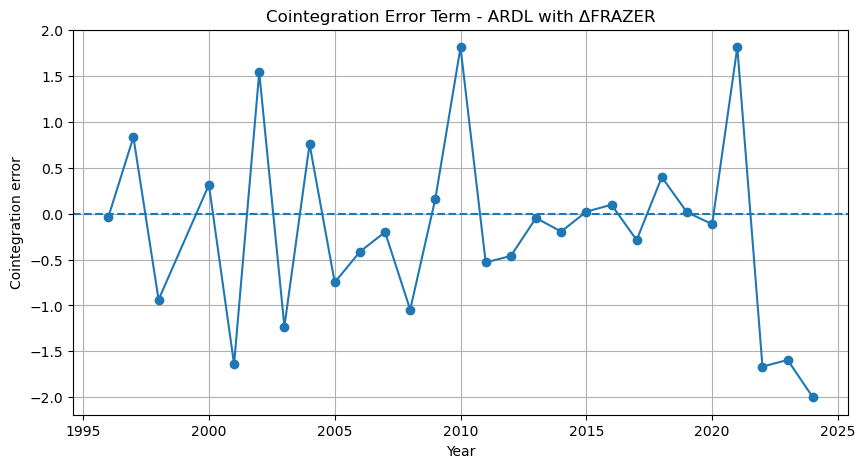

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(model_var.index, model_var["ce"], marker="o")
plt.axhline(0, linestyle="--")
plt.title("Cointegration Error Term - ARDL with ΔFRAZER")
plt.xlabel("Year")
plt.ylabel("Cointegration error")
plt.grid(True)
plt.show()

In [43]:
ΔLIDE(-1)
ΔD_FRAZER, ΔD_FRAZER(-1)
ΔCHANGE_INSTAB, ΔCHANGE_INSTAB(-1)
ΔGDP, ΔGDP(-1), ΔGDP(-2)
ΔOPEN_SERVICES, ΔOPEN_SERVICES(-1), ΔOPEN_SERVICES(-2)
CE(-1)

NameError: name 'ΔLIDE' is not defined

In [44]:
ecm_data = model_var.copy()

# Variable dépendante en différence
ecm_data["d_lide"] = ecm_data["lide"].diff()
ecm_data["d_lide_l1"] = ecm_data["d_lide"].shift(1)

# D_FRAZER est déjà une variation de frazer.
# Donc ici on prend la variation de D_FRAZER = accélération institutionnelle.
ecm_data["dd_frazer"] = ecm_data["d_frazer"].diff()
ecm_data["dd_frazer_l1"] = ecm_data["dd_frazer"].shift(1)

# Change instability
ecm_data["d_change_instab"] = ecm_data["change_instab"].diff()
ecm_data["d_change_instab_l1"] = ecm_data["d_change_instab"].shift(1)

# GDP
ecm_data["d_gdp"] = ecm_data["gdp"].diff()
ecm_data["d_gdp_l1"] = ecm_data["d_gdp"].shift(1)
ecm_data["d_gdp_l2"] = ecm_data["d_gdp"].shift(2)

# Open services
ecm_data["d_open_services"] = ecm_data["open_services"].diff()
ecm_data["d_open_services_l1"] = ecm_data["d_open_services"].shift(1)
ecm_data["d_open_services_l2"] = ecm_data["d_open_services"].shift(2)

# Terme de correction d'erreur retardé
ecm_data["ce_lag"] = ecm_data["ce"].shift(1)

# Nettoyage
ecm_data = ecm_data.dropna()

print(ecm_data.shape)
display(ecm_data.head())

(25, 20)


,lide,frazer,change_instab,gdp,open_services,ce,d_frazer,ce_lag,d_lide,d_lide_l1,dd_frazer,dd_frazer_l1,d_change_instab,d_change_instab_l1,d_gdp,d_gdp_l1,d_gdp_l2,d_open_services,d_open_services_l1,d_open_services_l2
year,,,,,,,,,,,,,,,,,,,,
2000,20.533284,5.72,0.002328,3.300539,12.871254,0.314847,0.02,-0.936943,0.985701,-1.252033,-0.03,0.06,-2.662371,2.325132,-0.202727,1.266017,1.126517,0.879514,-0.550700,0.461074
2001,19.187849,5.82,1.330521,3.910230,13.675468,-1.640550,0.10,0.314847,-1.345434,0.985701,0.08,-0.03,1.328193,-2.662371,0.609691,-0.202727,1.266017,0.804214,0.879514,-0.550700
2002,21.710470,5.74,0.969691,2.187734,15.883700,1.542152,-0.08,-1.640550,2.522620,-1.345434,-0.18,0.08,-0.360830,1.328193,-1.722496,0.609691,-0.202727,2.208232,0.804214,0.879514
2003,19.809958,5.82,4.044147,1.026498,16.648686,-1.229545,0.08,1.542152,-1.900512,2.522620,0.16,-0.18,3.074456,-0.360830,-1.161236,-1.722496,0.609691,0.764986,2.208232,0.804214
2004,21.526298,5.91,0.451370,1.087537,16.655875,0.759419,0.09,-1.229545,1.716340,-1.900512,0.01,0.16,-3.592777,3.074456,0.061039,-1.161236,-1.722496,0.007189,0.764986,2.208232


In [45]:
import statsmodels.api as sm

Y_ecm = ecm_data["d_lide"]

X_ecm = ecm_data[[
    "ce_lag",
    "d_lide_l1",
    "dd_frazer",
    "dd_frazer_l1",
    "d_change_instab",
    "d_change_instab_l1",
    "d_gdp",
    "d_gdp_l1",
    "d_gdp_l2",
    "d_open_services",
    "d_open_services_l1",
    "d_open_services_l2"
]]

X_ecm = sm.add_constant(X_ecm)

ecm_final = sm.OLS(Y_ecm, X_ecm).fit()

print(ecm_final.summary())

                            OLS Regression Results                            
Dep. Variable:                 d_lide   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     19.39
Date:                Wed, 13 May 2026   Prob (F-statistic):           5.19e-06
Time:                        22:10:15   Log-Likelihood:                 4.8790
No. Observations:                  25   AIC:                             16.24
Df Residuals:                      12   BIC:                             32.09
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const              -8.292e-15      0

In [46]:
ardl_results_final = pd.DataFrame({
    "Variable": res_final.params.index,
    "Coefficient": res_final.params.values,
    "Std_Error": res_final.bse.values,
    "t_stat": res_final.tvalues.values,
    "p_value": res_final.pvalues.values
})

display(ardl_results_final)

,Variable,Coefficient,Std_Error,t_stat,p_value
0,const,40.715261,8.479072,4.801853,0.000971
1,lide.L1,-0.741017,0.289704,-2.557843,0.030796
2,lide.L2,-0.509384,0.280928,-1.813217,0.103207
3,d_frazer.L0,0.002860,1.627677,0.001757,0.998636
4,d_frazer.L1,5.244274,2.371341,2.211523,0.054310
5,d_frazer.L2,3.662766,1.968980,1.860235,0.095778
6,change_instab.L0,0.017532,0.078665,0.222875,0.828609
7,change_instab.L1,0.331726,0.080581,4.116667,0.002611
8,change_instab.L2,-0.148665,0.140640,-1.057059,0.318031
9,gdp.L0,0.036775,0.019945,1.843842,0.098309


In [47]:
ecm_results_final = pd.DataFrame({
    "Variable": ecm_final.params.index,
    "Coefficient": ecm_final.params.values,
    "Std_Error": ecm_final.bse.values,
    "t_stat": ecm_final.tvalues.values,
    "p_value": ecm_final.pvalues.values
})

display(ecm_results_final)

,Variable,Coefficient,Std_Error,t_stat,p_value
0,const,-8.291978e-15,0.064637,-1.282844e-13,1.000000
1,ce_lag,-2.250401e+00,0.344056,-6.540791e+00,0.000028
2,d_lide_l1,5.093840e-01,0.194314,2.621441e+00,0.022325
3,dd_frazer,2.859948e-03,0.947043,3.019871e-03,0.997640
4,dd_frazer_l1,-3.662766e+00,1.456443,-2.514870e+00,0.027164
5,d_change_instab,1.753235e-02,0.045650,3.840565e-01,0.707655
6,d_change_instab_l1,1.486648e-01,0.052336,2.840602e+00,0.014880
7,d_gdp,3.677478e-02,0.010569,3.479413e+00,0.004551
8,d_gdp_l1,-1.415799e-01,0.025385,-5.577366e+00,0.000120
9,d_gdp_l2,-9.410252e-02,0.018494,-5.088260e+00,0.000267


In [48]:
ecm_results_final = pd.DataFrame({
    "Variable": ecm_final.params.index,
    "Coefficient": ecm_final.params.values,
    "Std_Error": ecm_final.bse.values,
    "t_stat": ecm_final.tvalues.values,
    "p_value": ecm_final.pvalues.values
})

display(ecm_results_final)

,Variable,Coefficient,Std_Error,t_stat,p_value
0,const,-8.291978e-15,0.064637,-1.282844e-13,1.000000
1,ce_lag,-2.250401e+00,0.344056,-6.540791e+00,0.000028
2,d_lide_l1,5.093840e-01,0.194314,2.621441e+00,0.022325
3,dd_frazer,2.859948e-03,0.947043,3.019871e-03,0.997640
4,dd_frazer_l1,-3.662766e+00,1.456443,-2.514870e+00,0.027164
5,d_change_instab,1.753235e-02,0.045650,3.840565e-01,0.707655
6,d_change_instab_l1,1.486648e-01,0.052336,2.840602e+00,0.014880
7,d_gdp,3.677478e-02,0.010569,3.479413e+00,0.004551
8,d_gdp_l1,-1.415799e-01,0.025385,-5.577366e+00,0.000120
9,d_gdp_l2,-9.410252e-02,0.018494,-5.088260e+00,0.000267


In [49]:
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

residuals_ardl_final = res_final.resid

# Normalité
jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(residuals_ardl_final)

# Autocorrélation
lb_test = acorr_ljungbox(residuals_ardl_final, lags=[1, 2, 3], return_df=True)

# Hétéroscédasticité ARCH
arch_test = het_arch(residuals_ardl_final)

diag_ardl_final = pd.DataFrame({
    "Test": [
        "Jarque-Bera normality",
        "Ljung-Box autocorrelation lag 1",
        "Ljung-Box autocorrelation lag 2",
        "Ljung-Box autocorrelation lag 3",
        "ARCH heteroskedasticity"
    ],
    "Statistic": [
        jb_stat,
        lb_test["lb_stat"].iloc[0],
        lb_test["lb_stat"].iloc[1],
        lb_test["lb_stat"].iloc[2],
        arch_test[0]
    ],
    "p_value": [
        jb_pvalue,
        lb_test["lb_pvalue"].iloc[0],
        lb_test["lb_pvalue"].iloc[1],
        lb_test["lb_pvalue"].iloc[2],
        arch_test[1]
    ]
})

display(diag_ardl_final)

,Test,Statistic,p_value
0,Jarque-Bera normality,0.099717,0.951364
1,Ljung-Box autocorrelation lag 1,0.413681,0.520107
2,Ljung-Box autocorrelation lag 2,0.914651,0.632974
3,Ljung-Box autocorrelation lag 3,1.283171,0.733133
4,ARCH heteroskedasticity,4.687043,0.455254


In [50]:
from statsmodels.stats.diagnostic import het_breuschpagan

residuals_ecm_final = ecm_final.resid

# Normalité
jb_ecm_stat, jb_ecm_pvalue, skew_ecm, kurtosis_ecm = jarque_bera(residuals_ecm_final)

# Autocorrélation
lb_ecm = acorr_ljungbox(residuals_ecm_final, lags=[1, 2, 3], return_df=True)

# Hétéroscédasticité Breusch-Pagan
bp_test = het_breuschpagan(residuals_ecm_final, ecm_final.model.exog)

diag_ecm_final = pd.DataFrame({
    "Test": [
        "Jarque-Bera normality",
        "Ljung-Box autocorrelation lag 1",
        "Ljung-Box autocorrelation lag 2",
        "Ljung-Box autocorrelation lag 3",
        "Breusch-Pagan heteroskedasticity LM",
        "Breusch-Pagan heteroskedasticity F"
    ],
    "Statistic": [
        jb_ecm_stat,
        lb_ecm["lb_stat"].iloc[0],
        lb_ecm["lb_stat"].iloc[1],
        lb_ecm["lb_stat"].iloc[2],
        bp_test[0],
        bp_test[2]
    ],
    "p_value": [
        jb_ecm_pvalue,
        lb_ecm["lb_pvalue"].iloc[0],
        lb_ecm["lb_pvalue"].iloc[1],
        lb_ecm["lb_pvalue"].iloc[2],
        bp_test[1],
        bp_test[3]
    ]
})

display(diag_ecm_final)

,Test,Statistic,p_value
0,Jarque-Bera normality,0.099717,0.951364
1,Ljung-Box autocorrelation lag 1,0.413681,0.520107
2,Ljung-Box autocorrelation lag 2,0.914651,0.632974
3,Ljung-Box autocorrelation lag 3,1.283171,0.733133
4,Breusch-Pagan heteroskedasticity LM,8.400448,0.753106
5,Breusch-Pagan heteroskedasticity F,0.506065,0.873842


In [51]:
from statsmodels.stats.diagnostic import het_breuschpagan

residuals_ecm_final = ecm_final.resid

# Normalité
jb_ecm_stat, jb_ecm_pvalue, skew_ecm, kurtosis_ecm = jarque_bera(residuals_ecm_final)

# Autocorrélation
lb_ecm = acorr_ljungbox(residuals_ecm_final, lags=[1, 2, 3], return_df=True)

# Hétéroscédasticité Breusch-Pagan
bp_test = het_breuschpagan(residuals_ecm_final, ecm_final.model.exog)

diag_ecm_final = pd.DataFrame({
    "Test": [
        "Jarque-Bera normality",
        "Ljung-Box autocorrelation lag 1",
        "Ljung-Box autocorrelation lag 2",
        "Ljung-Box autocorrelation lag 3",
        "Breusch-Pagan heteroskedasticity LM",
        "Breusch-Pagan heteroskedasticity F"
    ],
    "Statistic": [
        jb_ecm_stat,
        lb_ecm["lb_stat"].iloc[0],
        lb_ecm["lb_stat"].iloc[1],
        lb_ecm["lb_stat"].iloc[2],
        bp_test[0],
        bp_test[2]
    ],
    "p_value": [
        jb_ecm_pvalue,
        lb_ecm["lb_pvalue"].iloc[0],
        lb_ecm["lb_pvalue"].iloc[1],
        lb_ecm["lb_pvalue"].iloc[2],
        bp_test[1],
        bp_test[3]
    ]
})

display(diag_ecm_final)

,Test,Statistic,p_value
0,Jarque-Bera normality,0.099717,0.951364
1,Ljung-Box autocorrelation lag 1,0.413681,0.520107
2,Ljung-Box autocorrelation lag 2,0.914651,0.632974
3,Ljung-Box autocorrelation lag 3,1.283171,0.733133
4,Breusch-Pagan heteroskedasticity LM,8.400448,0.753106
5,Breusch-Pagan heteroskedasticity F,0.506065,0.873842


In [52]:
model_summary_final = pd.DataFrame({
    "Indicator": [
        "Model",
        "Dependent variable",
        "Institutional variable",
        "AIC",
        "BIC",
        "Number of observations",
        "Long-run D_FRAZER coefficient",
        "Long-run D_FRAZER p-value",
        "Interpretation"
    ],
    "Value": [
        "ARDL(2,2,2,3,3)",
        "LIDE = log(IDE)",
        "D_FRAZER = variation of FRAZER",
        res_final.aic,
        res_final.bic,
        res_final.nobs,
        lr_d_frazer,
        p_d_frazer,
        "Effect of institutional improvement on FDI"
    ]
})

display(model_summary_final)

,Indicator,Value
0,Model,"ARDL(2,2,2,3,3)"
1,Dependent variable,LIDE = log(IDE)
2,Institutional variable,D_FRAZER = variation of FRAZER
3,AIC,24.831849
4,BIC,47.477587
5,Number of observations,26
6,Long-run D_FRAZER coefficient,3.959251
7,Long-run D_FRAZER p-value,0.007576
8,Interpretation,Effect of institutional improvement on FDI


In [53]:
from pathlib import Path

output = Path.home() / "Downloads" / "Dashboard_ARDL_Variation_FRAZER"
output.mkdir(exist_ok=True)

model_var.reset_index().to_csv(output / "ardl_data_dfrazer.csv", index=False)
ardl_results_final.to_csv(output / "ardl_results_dfrazer.csv", index=False)
longrun_final.to_csv(output / "ardl_longrun_dfrazer.csv", index=False)
ecm_results_final.to_csv(output / "ecm_results_dfrazer.csv", index=False)
diag_ardl_final.to_csv(output / "diag_ardl_dfrazer.csv", index=False)
diag_ecm_final.to_csv(output / "diag_ecm_dfrazer.csv", index=False)
model_summary_final.to_csv(output / "model_summary_dfrazer.csv", index=False)

with pd.ExcelWriter(output / "ARDL_DFRAZER_results_tables.xlsx") as writer:
    model_summary_final.to_excel(writer, sheet_name="Model Summary", index=False)
    ardl_results_final.to_excel(writer, sheet_name="ARDL Results", index=False)
    longrun_final.to_excel(writer, sheet_name="Long-run", index=False)
    ecm_results_final.to_excel(writer, sheet_name="ECM", index=False)
    diag_ardl_final.to_excel(writer, sheet_name="Diagnostics ARDL", index=False)
    diag_ecm_final.to_excel(writer, sheet_name="Diagnostics ECM", index=False)

print("Résultats exportés dans :", output)

Résultats exportés dans : C:\Users\dell\Downloads\Dashboard_ARDL_Variation_FRAZER


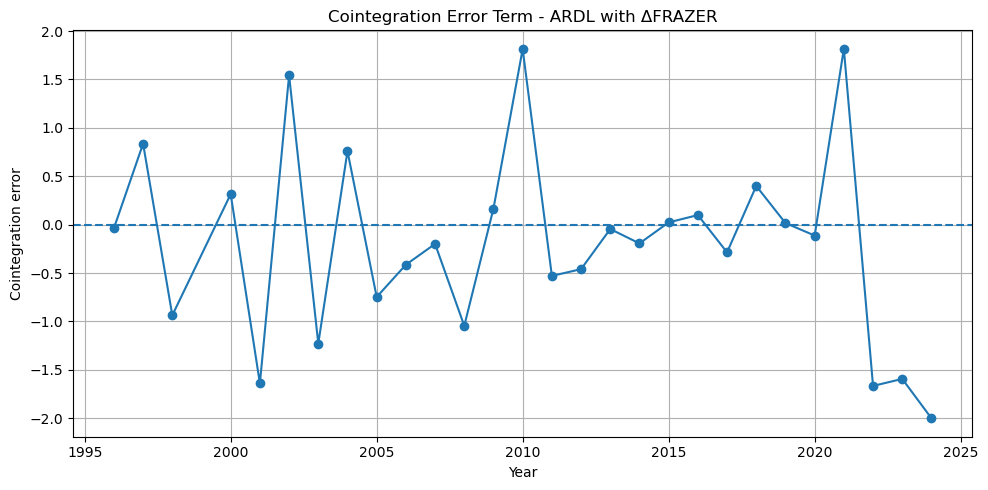

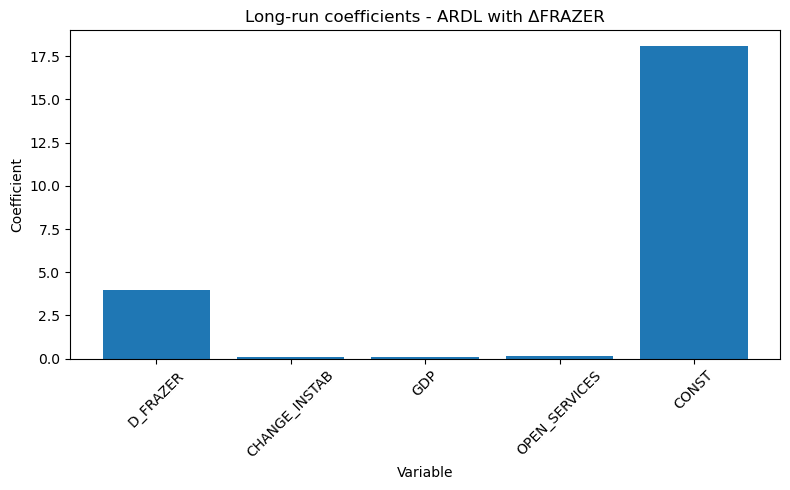

In [54]:
plt.figure(figsize=(10, 5))
plt.plot(model_var.index, model_var["ce"], marker="o")
plt.axhline(0, linestyle="--")
plt.title("Cointegration Error Term - ARDL with ΔFRAZER")
plt.xlabel("Year")
plt.ylabel("Cointegration error")
plt.grid(True)
plt.tight_layout()
plt.savefig(output / "cointegration_dfrazer.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(longrun_final["Variable"], longrun_final["Long_run_coefficient"])
plt.title("Long-run coefficients - ARDL with ΔFRAZER")
plt.xlabel("Variable")
plt.ylabel("Coefficient")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(output / "longrun_coefficients_dfrazer.png", dpi=300)
plt.show()

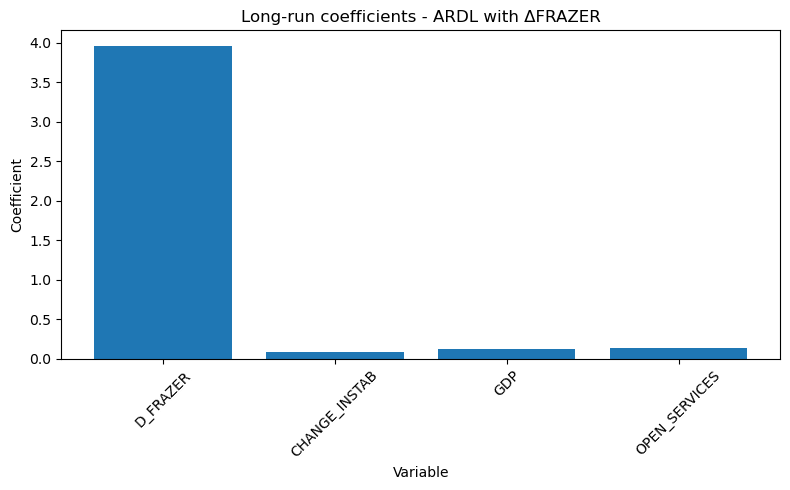

In [55]:
longrun_no_const = longrun_final[
    longrun_final["Variable"] != "CONST"
]

plt.figure(figsize=(8, 5))
plt.bar(longrun_no_const["Variable"], longrun_no_const["Long_run_coefficient"])
plt.title("Long-run coefficients - ARDL with ΔFRAZER")
plt.xlabel("Variable")
plt.ylabel("Coefficient")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [1]:
import matplotlib.pyplot as plt

# Variables du modèle final avec variation de FRAZER
vars_to_plot = [
    "lide",
    "d_frazer",
    "change_instab",
    "gdp",
    "open_services"
]

# Vérifier que les variables existent
print(model_var[vars_to_plot].head())

# Graphiques séparés dans une même figure
fig, axes = plt.subplots(len(vars_to_plot), 1, figsize=(10, 14), sharex=True)

for ax, var in zip(axes, vars_to_plot):
    ax.plot(model_var.index, model_var[var], marker="o")
    ax.set_title(f"Trend of {var}")
    ax.set_ylabel(var)
    ax.grid(True)

axes[-1].set_xlabel("Year")

plt.tight_layout()
plt.show()

NameError: name 'model_var' is not defined

NameError: name 'model_var' is not defined

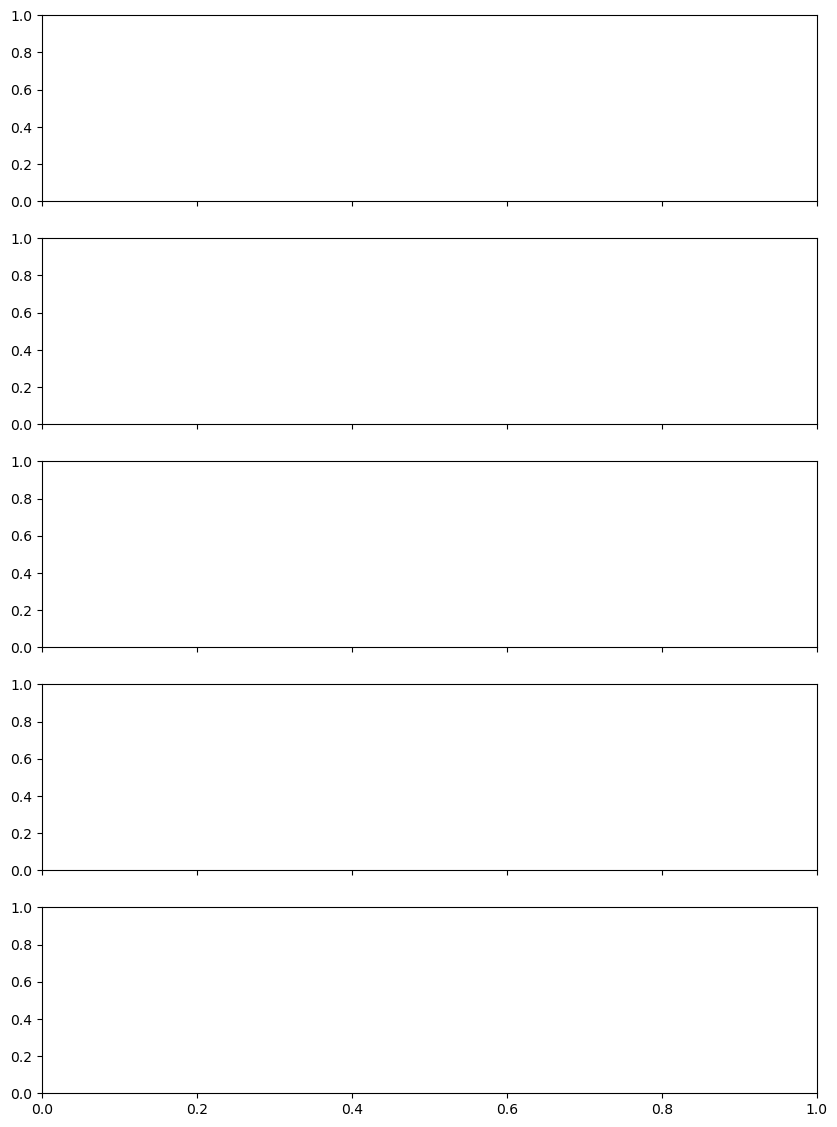

In [2]:
titles = {
    "lide": "Logarithme des IDE",
    "d_frazer": "Variation de l’indice FRAZER",
    "change_instab": "Instabilité du taux de change",
    "gdp": "Croissance du PIB",
    "open_services": "Ouverture des services"
}

fig, axes = plt.subplots(len(vars_to_plot), 1, figsize=(10, 14), sharex=True)

for ax, var in zip(axes, vars_to_plot):
    ax.plot(model_var.index, model_var[var], marker="o")
    ax.set_title(titles[var])
    ax.set_ylabel(var)
    ax.grid(True)

axes[-1].set_xlabel("Année")

plt.tight_layout()
plt.savefig(output / "tendances_variables_modele_final.png", dpi=300)
plt.show()

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Charger la base finale déjà exportée
folder = Path.home() / "Downloads" / "Dashboard_ARDL_Variation_FRAZER"

model_var = pd.read_csv(folder / "ardl_data_dfrazer.csv")

# Mettre year comme index
model_var["year"] = model_var["year"].astype(int)
model_var = model_var.set_index("year")

print(model_var.head())
print(model_var.columns.tolist())

           lide  frazer  change_instab       gdp  open_services        ce  \
year                                                                        
1996  19.694349    5.66       0.769527  1.110732      12.081366 -0.037630   
1997  20.799616    5.65       0.339567  2.237249      12.542441  0.836115   
1998  19.547582    5.70       2.664699  3.503266      11.991741 -0.936943   
2000  20.533284    5.72       0.002328  3.300539      12.871254  0.314847   
2001  19.187849    5.82       1.330521  3.910230      13.675468 -1.640550   

      d_frazer    ce_lag  
year                      
1996     -0.03       NaN  
1997     -0.01 -0.037630  
1998      0.05  0.836115  
2000      0.02 -0.936943  
2001      0.10  0.314847  
['lide', 'frazer', 'change_instab', 'gdp', 'open_services', 'ce', 'd_frazer', 'ce_lag']


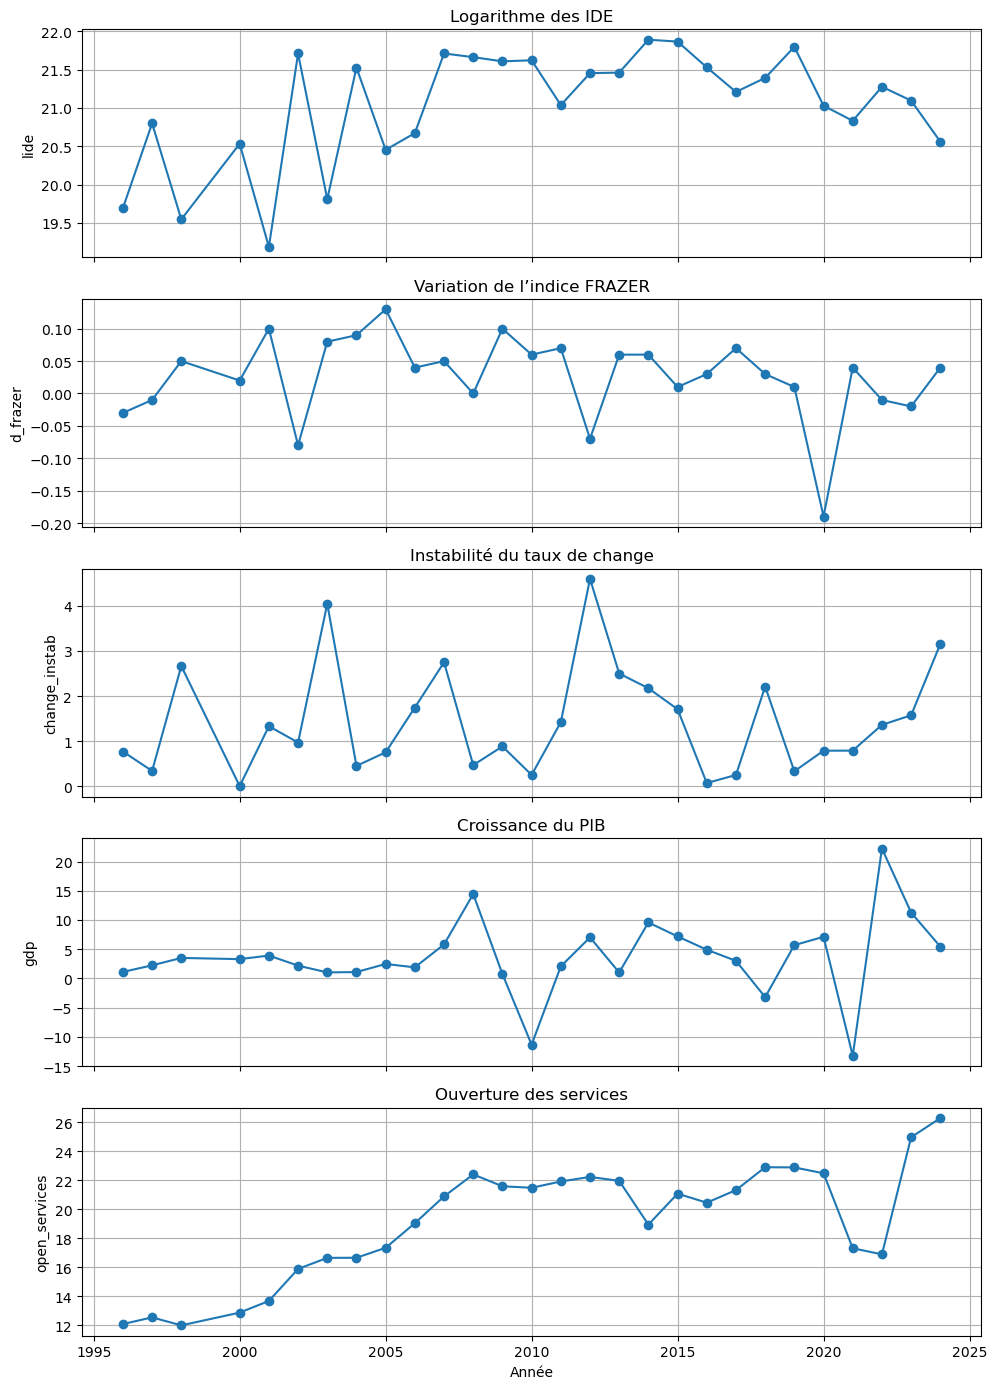

In [4]:
# Variables du modèle final
vars_to_plot = [
    "lide",
    "d_frazer",
    "change_instab",
    "gdp",
    "open_services"
]

titles = {
    "lide": "Logarithme des IDE",
    "d_frazer": "Variation de l’indice FRAZER",
    "change_instab": "Instabilité du taux de change",
    "gdp": "Croissance du PIB",
    "open_services": "Ouverture des services"
}

fig, axes = plt.subplots(len(vars_to_plot), 1, figsize=(10, 14), sharex=True)

for ax, var in zip(axes, vars_to_plot):
    ax.plot(model_var.index, model_var[var], marker="o")
    ax.set_title(titles[var])
    ax.set_ylabel(var)
    ax.grid(True)

axes[-1].set_xlabel("Année")

plt.tight_layout()
plt.show()

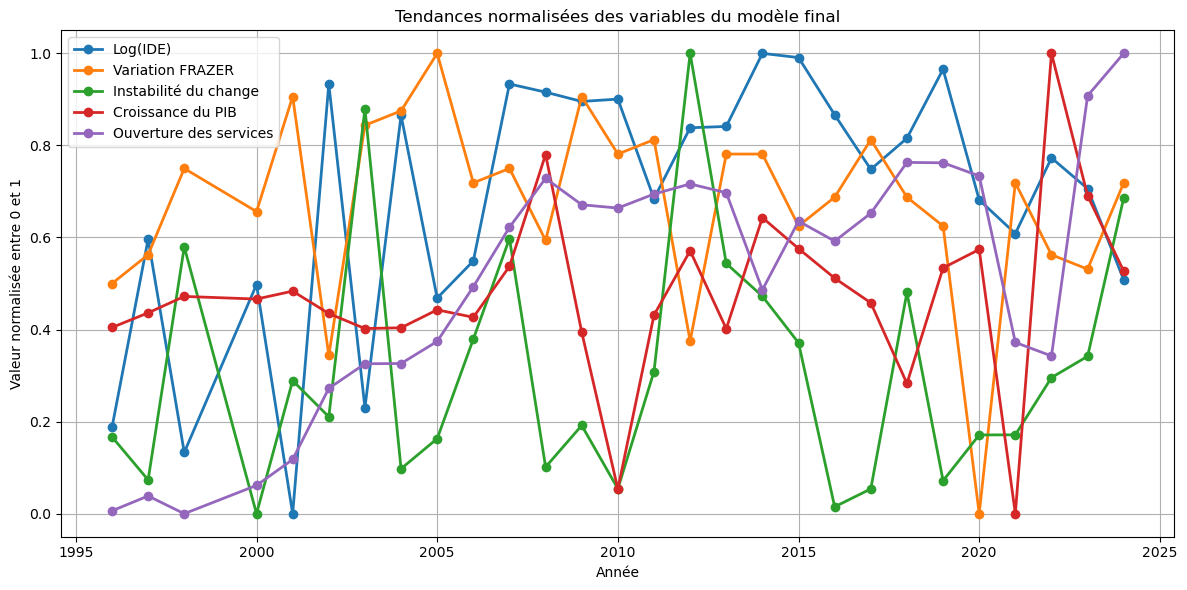

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Charger la base finale
folder = Path.home() / "Downloads" / "Dashboard_ARDL_Variation_FRAZER"
model_var = pd.read_csv(folder / "ardl_data_dfrazer.csv")

# Mettre l'année comme index
model_var["year"] = model_var["year"].astype(int)
model_var = model_var.set_index("year")

# Variables à représenter
vars_to_plot = [
    "lide",
    "d_frazer",
    "change_instab",
    "gdp",
    "open_services"
]

# Titres propres
labels = {
    "lide": "Log(IDE)",
    "d_frazer": "Variation FRAZER",
    "change_instab": "Instabilité du change",
    "gdp": "Croissance du PIB",
    "open_services": "Ouverture des services"
}

# Normalisation min-max entre 0 et 1
trend_norm = model_var[vars_to_plot].copy()
trend_norm = (trend_norm - trend_norm.min()) / (trend_norm.max() - trend_norm.min())

# Graphique unique
plt.figure(figsize=(12, 6))

for var in vars_to_plot:
    plt.plot(
        trend_norm.index,
        trend_norm[var],
        marker="o",
        linewidth=2,
        label=labels[var]
    )

plt.title("Tendances normalisées des variables du modèle final")
plt.xlabel("Année")
plt.ylabel("Valeur normalisée entre 0 et 1")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Sauvegarde
output = Path.home() / "Downloads" / "Dashboard_ARDL_Variation_FRAZER"
plt.savefig(output / "tendances_normalisees_toutes_variables.png", dpi=300)

plt.show()

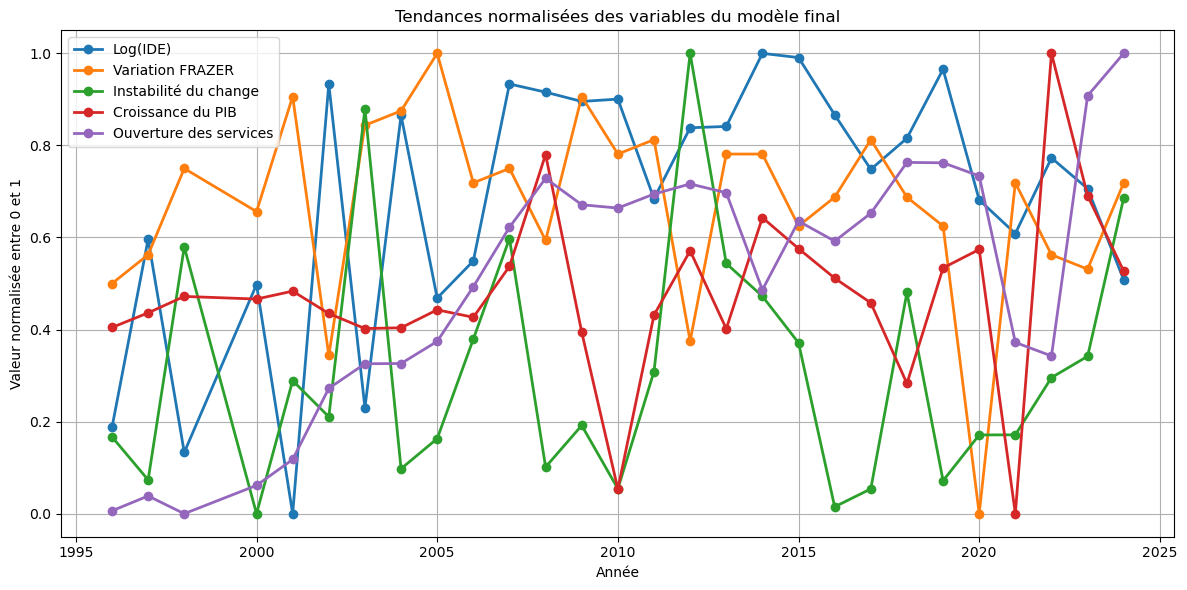

Image exportée ici : C:\Users\dell\Desktop\tendances_normalisees_variables_modele_final.png


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Charger la base finale
folder = Path.home() / "Downloads" / "Dashboard_ARDL_Variation_FRAZER"
model_var = pd.read_csv(folder / "ardl_data_dfrazer.csv")

# Mettre l'année comme index
model_var["year"] = model_var["year"].astype(int)
model_var = model_var.set_index("year")

# Variables à représenter
vars_to_plot = [
    "lide",
    "d_frazer",
    "change_instab",
    "gdp",
    "open_services"
]

# Titres propres
labels = {
    "lide": "Log(IDE)",
    "d_frazer": "Variation FRAZER",
    "change_instab": "Instabilité du change",
    "gdp": "Croissance du PIB",
    "open_services": "Ouverture des services"
}

# Normalisation min-max entre 0 et 1
trend_norm = model_var[vars_to_plot].copy()
trend_norm = (trend_norm - trend_norm.min()) / (trend_norm.max() - trend_norm.min())

# Graphique unique
plt.figure(figsize=(12, 6))

for var in vars_to_plot:
    plt.plot(
        trend_norm.index,
        trend_norm[var],
        marker="o",
        linewidth=2,
        label=labels[var]
    )

plt.title("Tendances normalisées des variables du modèle final")
plt.xlabel("Année")
plt.ylabel("Valeur normalisée entre 0 et 1")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Exporter sur le Bureau
desktop = Path.home() / "Desktop"
file_path = desktop / "tendances_normalisees_variables_modele_final.png"

plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

print("Image exportée ici :", file_path)

In [7]:
import pandas as pd
import numpy as np
from pathlib import Path

# Charger la base finale avec D_FRAZER
folder = Path.home() / "Downloads" / "Dashboard_ARDL_Variation_FRAZER"
model_var = pd.read_csv(folder / "ardl_data_dfrazer.csv")

# Vérifier les colonnes
print(model_var.columns.tolist())
print(model_var.head())

['year', 'lide', 'frazer', 'change_instab', 'gdp', 'open_services', 'ce', 'd_frazer', 'ce_lag']
   year       lide  frazer  change_instab       gdp  open_services        ce  \
0  1996  19.694349    5.66       0.769527  1.110732      12.081366 -0.037630   
1  1997  20.799616    5.65       0.339567  2.237249      12.542441  0.836115   
2  1998  19.547582    5.70       2.664699  3.503266      11.991741 -0.936943   
3  2000  20.533284    5.72       0.002328  3.300539      12.871254  0.314847   
4  2001  19.187849    5.82       1.330521  3.910230      13.675468 -1.640550   

   d_frazer    ce_lag  
0     -0.03       NaN  
1     -0.01 -0.037630  
2      0.05  0.836115  
3      0.02 -0.936943  
4      0.10  0.314847  


In [8]:
coef_long_term_dfrazer = 3.959251

# Variations réalistes de FRAZER
variations = [0.01, 0.05, 0.10]

effects = []

for v in variations:
    percent_effect = (np.exp(coef_long_term_dfrazer * v) - 1) * 100
    dollar_effect = ide_recent_mean * percent_effect / 100
    
    effects.append({
        "Variation de FRAZER": v,
        "Effet sur les IDE (%)": percent_effect,
        "Effet estimé en valeur": dollar_effect
    })

effects_df = pd.DataFrame(effects)

 display(effects_df)

NameError: name 'ide_recent_mean' is not defined

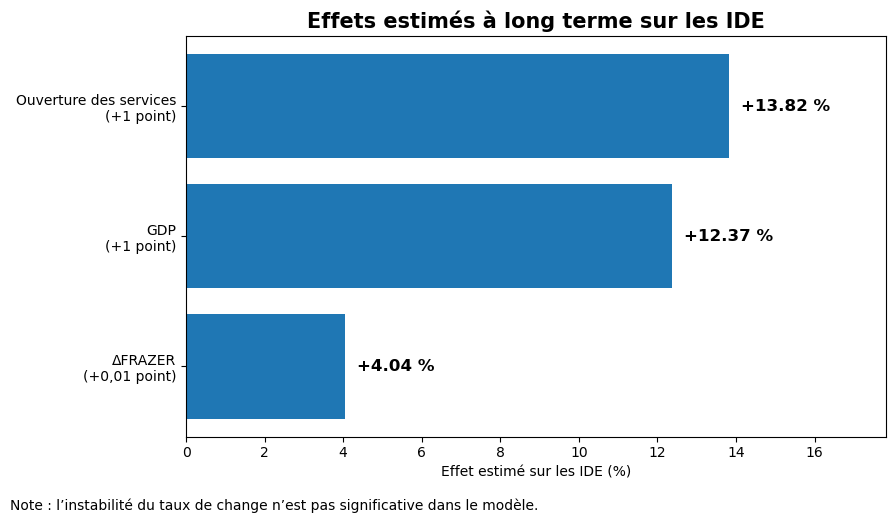

Graphique exporté ici : C:\Users\dell\Desktop\effets_long_terme_IDE.png


In [9]:
import matplotlib.pyplot as plt
from pathlib import Path

# Résultats long terme significatifs
variables = ["ΔFRAZER\n(+0,01 point)", "GDP\n(+1 point)", "Ouverture des services\n(+1 point)"]
effets = [4.04, 12.37, 13.82]

# Création du graphique
plt.figure(figsize=(9, 5))
bars = plt.barh(variables, effets)

# Ajouter les valeurs sur les barres
for bar, value in zip(bars, effets):
    plt.text(
        value + 0.3,
        bar.get_y() + bar.get_height()/2,
        f"+{value:.2f} %",
        va="center",
        fontsize=12,
        fontweight="bold"
    )

# Mise en forme
plt.title("Effets estimés à long terme sur les IDE", fontsize=15, fontweight="bold")
plt.xlabel("Effet estimé sur les IDE (%)")
plt.xlim(0, max(effets) + 4)

# Note
plt.figtext(
    0.01, -0.03,
    "Note : l’instabilité du taux de change n’est pas significative dans le modèle.",
    ha="left",
    fontsize=10
)

plt.tight_layout()

# Export vers le bureau
desktop = Path.home() / "Desktop"
file_path = desktop / "effets_long_terme_IDE.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")

plt.show()

print("Graphique exporté ici :", file_path)

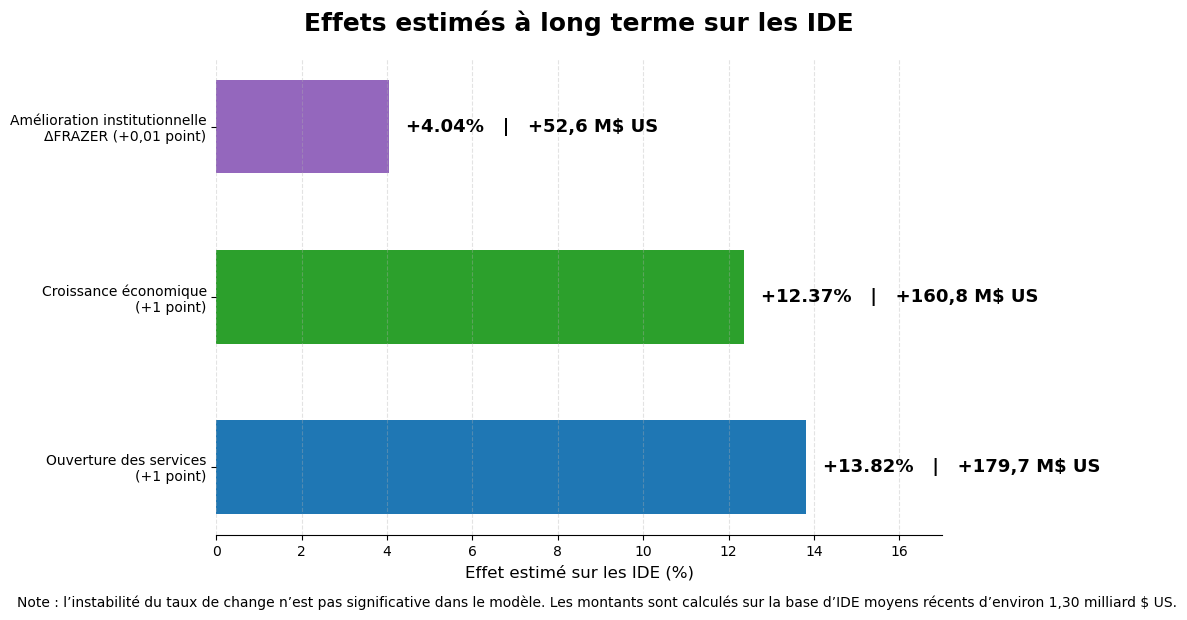

Graphique exporté ici : C:\Users\dell\Desktop\graphique_creatif_effets_long_terme_IDE.png


In [10]:
import matplotlib.pyplot as plt
from pathlib import Path

# Données long terme
variables = [
    "Ouverture des services\n(+1 point)",
    "Croissance économique\n(+1 point)",
    "Amélioration institutionnelle\nΔFRAZER (+0,01 point)"
]

effets = [13.82, 12.37, 4.04]

montants = [
    "+179,7 M$ US",
    "+160,8 M$ US",
    "+52,6 M$ US"
]

# Couleurs sobres pour PPT
colors = ["#1F77B4", "#2CA02C", "#9467BD"]

plt.figure(figsize=(11, 6))

bars = plt.barh(variables, effets, color=colors, height=0.55)

# Ajouter les pourcentages + montants à droite
for bar, effet, montant in zip(bars, effets, montants):
    plt.text(
        effet + 0.4,
        bar.get_y() + bar.get_height()/2,
        f"+{effet:.2f}%   |   {montant}",
        va="center",
        fontsize=13,
        fontweight="bold"
    )

# Titre et sous-titre
plt.title(
    "Effets estimés à long terme sur les IDE",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel("Effet estimé sur les IDE (%)", fontsize=12)

# Supprimer bordures inutiles
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Grille légère
plt.grid(axis="x", linestyle="--", alpha=0.35)

# Limites
plt.xlim(0, 17)

# Note en bas
plt.figtext(
    0.02, -0.02,
    "Note : l’instabilité du taux de change n’est pas significative dans le modèle. "
    "Les montants sont calculés sur la base d’IDE moyens récents d’environ 1,30 milliard $ US.",
    ha="left",
    fontsize=10
)

plt.tight_layout()

# Export bureau
desktop = Path.home() / "Desktop"
file_path = desktop / "graphique_creatif_effets_long_terme_IDE.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")

plt.show()

print("Graphique exporté ici :", file_path)

In [11]:
Create a clean professional slide visual titled “Effets estimés à long terme sur les IDE au Maroc”. 
Use three impact cards with icons and large numbers.

Card 1: “Amélioration institutionnelle” — “+4,04 %” — “≈ +52,6 M$ US” — subtitle: “pour +0,01 point de ΔFRAZER”.
Card 2: “Croissance économique” — “+12,37 %” — “≈ +160,8 M$ US” — subtitle: “pour +1 point de GDP”.
Card 3: “Ouverture des services” — “+13,82 %” — “≈ +179,7 M$ US” — subtitle: “pour +1 point d’ouverture”.

Add a small note at the bottom: “Instabilité du taux de change : effet non significatif”.
Use a modern public policy style, sober colors, light background, clear hierarchy, and avoid technical econometric language.

SyntaxError: invalid character '“' (U+201C) (3331905654.py, line 1)

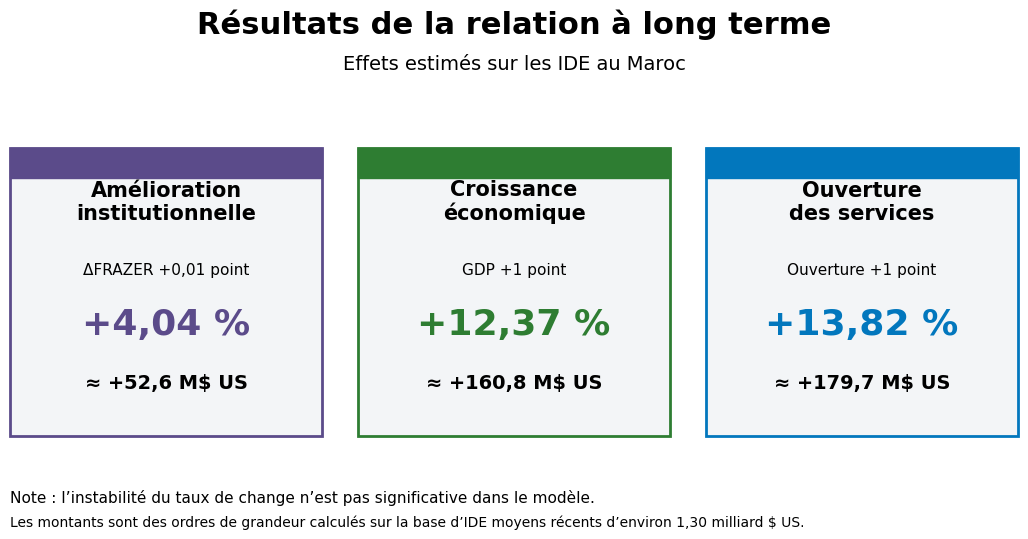

Graphique exporté ici : C:\Users\dell\Desktop\impact_cards_long_terme_IDE.png


In [12]:
import matplotlib.pyplot as plt
from pathlib import Path

# Données
cards = [
    {
        "titre": "Amélioration\ninstitutionnelle",
        "variation": "ΔFRAZER +0,01 point",
        "effet": "+4,04 %",
        "montant": "≈ +52,6 M$ US"
    },
    {
        "titre": "Croissance\néconomique",
        "variation": "GDP +1 point",
        "effet": "+12,37 %",
        "montant": "≈ +160,8 M$ US"
    },
    {
        "titre": "Ouverture\ndes services",
        "variation": "Ouverture +1 point",
        "effet": "+13,82 %",
        "montant": "≈ +179,7 M$ US"
    }
]

colors = ["#5B4B8A", "#2E7D32", "#0277BD"]

fig, ax = plt.subplots(figsize=(12, 6))
ax.axis("off")

# Titre
fig.text(
    0.5, 0.92,
    "Résultats de la relation à long terme",
    ha="center",
    fontsize=22,
    fontweight="bold"
)

fig.text(
    0.5, 0.86,
    "Effets estimés sur les IDE au Maroc",
    ha="center",
    fontsize=14
)

# Création des cartes
x_positions = [0.08, 0.37, 0.66]

for x, card, color in zip(x_positions, cards, colors):
    # Rectangle principal
    rect = plt.Rectangle(
        (x, 0.25), 0.26, 0.48,
        transform=fig.transFigure,
        facecolor="#F3F5F7",
        edgecolor=color,
        linewidth=2
    )
    fig.patches.append(rect)
    
    # Bande supérieure colorée
    band = plt.Rectangle(
        (x, 0.68), 0.26, 0.05,
        transform=fig.transFigure,
        facecolor=color,
        edgecolor=color
    )
    fig.patches.append(band)
    
    # Titre carte
    fig.text(
        x + 0.13, 0.61,
        card["titre"],
        ha="center",
        fontsize=15,
        fontweight="bold"
    )
    
    # Variation
    fig.text(
        x + 0.13, 0.52,
        card["variation"],
        ha="center",
        fontsize=11
    )
    
    # Effet %
    fig.text(
        x + 0.13, 0.42,
        card["effet"],
        ha="center",
        fontsize=26,
        fontweight="bold",
        color=color
    )
    
    # Montant
    fig.text(
        x + 0.13, 0.33,
        card["montant"],
        ha="center",
        fontsize=14,
        fontweight="bold"
    )

# Note
fig.text(
    0.08, 0.14,
    "Note : l’instabilité du taux de change n’est pas significative dans le modèle.",
    fontsize=11
)

fig.text(
    0.08, 0.10,
    "Les montants sont des ordres de grandeur calculés sur la base d’IDE moyens récents d’environ 1,30 milliard $ US.",
    fontsize=10
)

# Export
desktop = Path.home() / "Desktop"
file_path = desktop / "impact_cards_long_terme_IDE.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

print("Graphique exporté ici :", file_path)

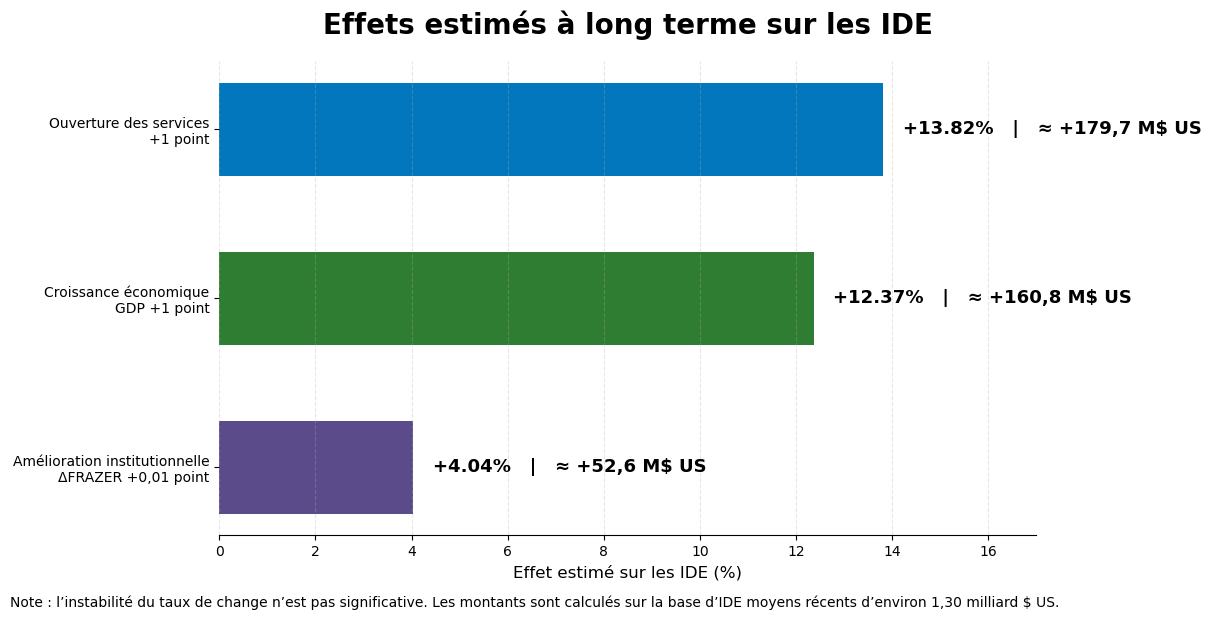

Graphique exporté ici : C:\Users\dell\Desktop\barres_modernes_long_terme_IDE.png


In [13]:
import matplotlib.pyplot as plt
from pathlib import Path

variables = [
    "Amélioration institutionnelle\nΔFRAZER +0,01 point",
    "Croissance économique\nGDP +1 point",
    "Ouverture des services\n+1 point"
]

effets = [4.04, 12.37, 13.82]
montants = ["≈ +52,6 M$ US", "≈ +160,8 M$ US", "≈ +179,7 M$ US"]

colors = ["#5B4B8A", "#2E7D32", "#0277BD"]

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(variables, effets, color=colors, height=0.55)

# Valeurs à droite des barres
for bar, effet, montant in zip(bars, effets, montants):
    ax.text(
        effet + 0.4,
        bar.get_y() + bar.get_height()/2,
        f"+{effet:.2f}%   |   {montant}",
        va="center",
        fontsize=13,
        fontweight="bold"
    )

# Titre
ax.set_title(
    "Effets estimés à long terme sur les IDE",
    fontsize=20,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("Effet estimé sur les IDE (%)", fontsize=12)
ax.set_xlim(0, 17)

# Nettoyage visuel
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.3)

# Note
plt.figtext(
    0.01, -0.02,
    "Note : l’instabilité du taux de change n’est pas significative. "
    "Les montants sont calculés sur la base d’IDE moyens récents d’environ 1,30 milliard $ US.",
    ha="left",
    fontsize=10
)

plt.tight_layout()

desktop = Path.home() / "Desktop"
file_path = desktop / "barres_modernes_long_terme_IDE.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

print("Graphique exporté ici :", file_path)

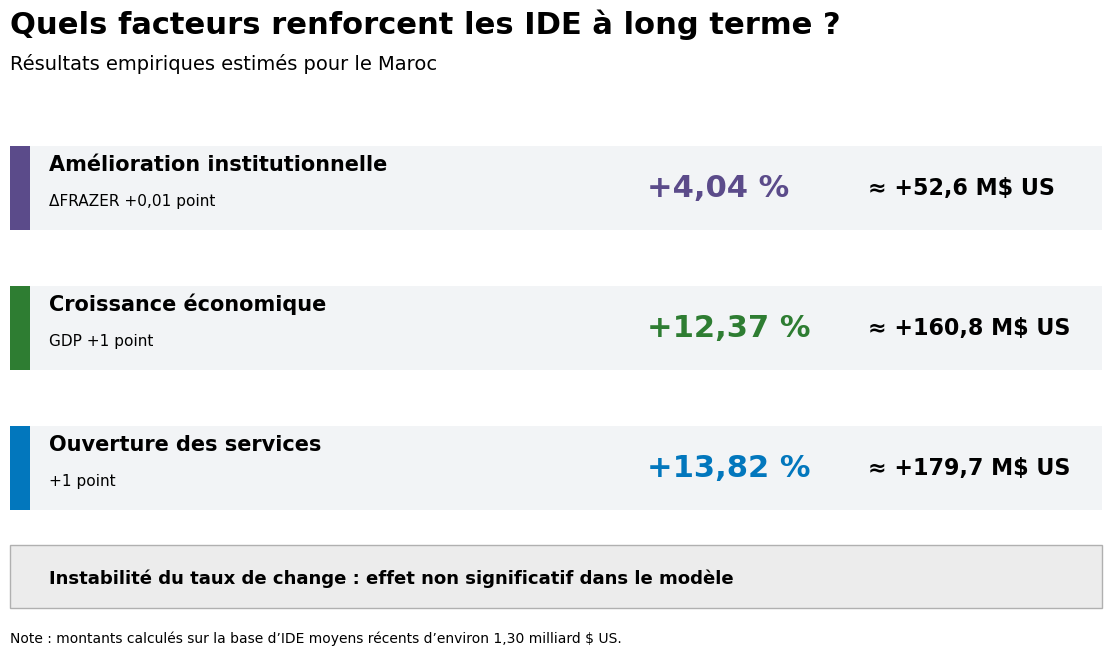

Graphique exporté ici : C:\Users\dell\Desktop\dashboard_policy_long_terme_IDE.png


In [14]:
import matplotlib.pyplot as plt
from pathlib import Path

fig, ax = plt.subplots(figsize=(13, 7))
ax.axis("off")

# Titre
fig.text(
    0.06, 0.90,
    "Quels facteurs renforcent les IDE à long terme ?",
    fontsize=22,
    fontweight="bold"
)

fig.text(
    0.06, 0.85,
    "Résultats empiriques estimés pour le Maroc",
    fontsize=14
)

# Données
items = [
    ("Amélioration institutionnelle", "ΔFRAZER +0,01 point", "+4,04 %", "≈ +52,6 M$ US", "#5B4B8A"),
    ("Croissance économique", "GDP +1 point", "+12,37 %", "≈ +160,8 M$ US", "#2E7D32"),
    ("Ouverture des services", "+1 point", "+13,82 %", "≈ +179,7 M$ US", "#0277BD"),
]

y_positions = [0.68, 0.48, 0.28]

for (titre, variation, effet, montant, color), y in zip(items, y_positions):
    # Bloc gris
    rect = plt.Rectangle(
        (0.06, y - 0.06), 0.84, 0.12,
        transform=fig.transFigure,
        facecolor="#F2F4F6",
        edgecolor="none"
    )
    fig.patches.append(rect)
    
    # Barre colorée à gauche
    bar = plt.Rectangle(
        (0.06, y - 0.06), 0.015, 0.12,
        transform=fig.transFigure,
        facecolor=color,
        edgecolor="none"
    )
    fig.patches.append(bar)
    
    # Textes
    fig.text(0.09, y + 0.025, titre, fontsize=15, fontweight="bold")
    fig.text(0.09, y - 0.025, variation, fontsize=11)
    
    fig.text(0.55, y, effet, fontsize=22, fontweight="bold", color=color, va="center")
    fig.text(0.72, y, montant, fontsize=16, fontweight="bold", va="center")

# Encadré non significatif
rect = plt.Rectangle(
    (0.06, 0.08), 0.84, 0.09,
    transform=fig.transFigure,
    facecolor="#ECECEC",
    edgecolor="#B0B0B0",
    linewidth=1
)
fig.patches.append(rect)

fig.text(
    0.09, 0.115,
    "Instabilité du taux de change : effet non significatif dans le modèle",
    fontsize=13,
    fontweight="bold"
)

fig.text(
    0.06, 0.03,
    "Note : montants calculés sur la base d’IDE moyens récents d’environ 1,30 milliard $ US.",
    fontsize=10
)

desktop = Path.home() / "Desktop"
file_path = desktop / "dashboard_policy_long_terme_IDE.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

print("Graphique exporté ici :", file_path)

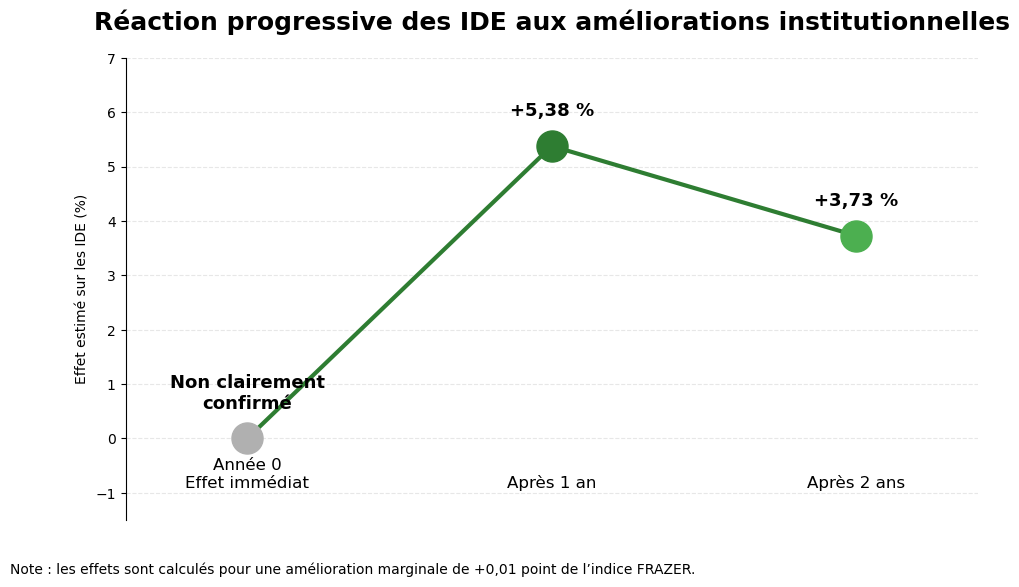

Graphique exporté ici : C:\Users\dell\Desktop\court_terme_timeline_IDE.png


In [15]:
import matplotlib.pyplot as plt
from pathlib import Path

# Données
horizons = ["Année 0\nEffet immédiat", "Après 1 an", "Après 2 ans"]
effets = [0, 5.38, 3.73]
labels = ["Non clairement\nconfirmé", "+5,38 %", "+3,73 %"]

colors = ["#B0B0B0", "#2E7D32", "#4CAF50"]

fig, ax = plt.subplots(figsize=(11, 6))

# Ligne horizontale
ax.plot([0, 1, 2], effets, marker="o", linewidth=3, color="#2E7D32")

# Points
for i, (x, y, label, color) in enumerate(zip(range(3), effets, labels, colors)):
    ax.scatter(x, y, s=500, color=color, zorder=3)
    ax.text(x, y + 0.55, label, ha="center", fontsize=13, fontweight="bold")
    ax.text(x, -0.9, horizons[i], ha="center", fontsize=12)

# Titre
ax.set_title(
    "Réaction progressive des IDE aux améliorations institutionnelles",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.set_ylabel("Effet estimé sur les IDE (%)")
ax.set_ylim(-1.5, 7)
ax.set_xlim(-0.4, 2.4)

# Nettoyage
ax.set_xticks([])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)

# Note
plt.figtext(
    0.02, 0.02,
    "Note : les effets sont calculés pour une amélioration marginale de +0,01 point de l’indice FRAZER.",
    fontsize=10
)

desktop = Path.home() / "Desktop"
file_path = desktop / "court_terme_timeline_IDE.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

print("Graphique exporté ici :", file_path)

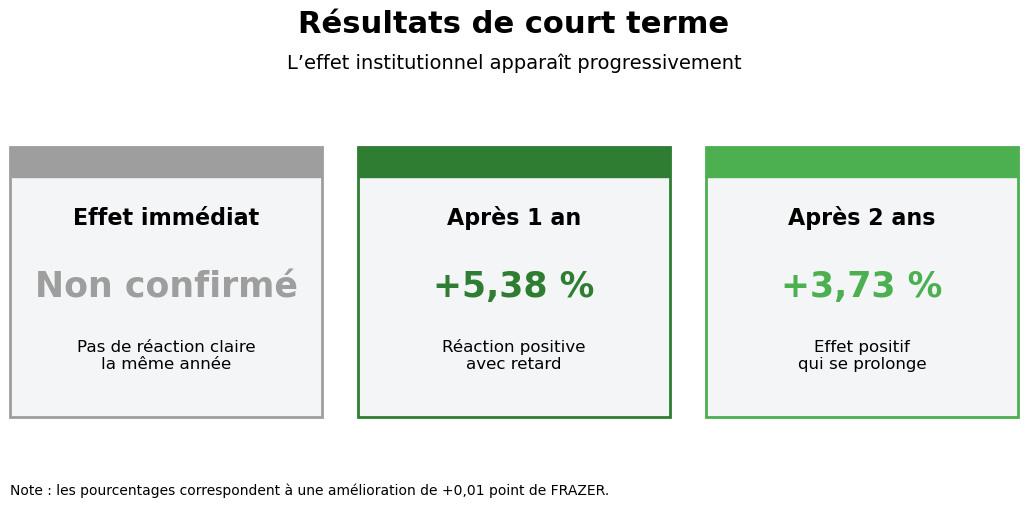

Graphique exporté ici : C:\Users\dell\Desktop\court_terme_impact_cards_IDE.png


In [16]:
import matplotlib.pyplot as plt
from pathlib import Path

cards = [
    {
        "titre": "Effet immédiat",
        "effet": "Non confirmé",
        "interpretation": "Pas de réaction claire\nla même année",
        "color": "#9E9E9E"
    },
    {
        "titre": "Après 1 an",
        "effet": "+5,38 %",
        "interpretation": "Réaction positive\navec retard",
        "color": "#2E7D32"
    },
    {
        "titre": "Après 2 ans",
        "effet": "+3,73 %",
        "interpretation": "Effet positif\nqui se prolonge",
        "color": "#4CAF50"
    }
]

fig, ax = plt.subplots(figsize=(12, 6))
ax.axis("off")

fig.text(
    0.5, 0.92,
    "Résultats de court terme",
    ha="center",
    fontsize=22,
    fontweight="bold"
)

fig.text(
    0.5, 0.86,
    "L’effet institutionnel apparaît progressivement",
    ha="center",
    fontsize=14
)

x_positions = [0.08, 0.37, 0.66]

for x, card in zip(x_positions, cards):
    rect = plt.Rectangle(
        (x, 0.28), 0.26, 0.45,
        transform=fig.transFigure,
        facecolor="#F3F5F7",
        edgecolor=card["color"],
        linewidth=2
    )
    fig.patches.append(rect)
    
    band = plt.Rectangle(
        (x, 0.68), 0.26, 0.05,
        transform=fig.transFigure,
        facecolor=card["color"],
        edgecolor=card["color"]
    )
    fig.patches.append(band)
    
    fig.text(
        x + 0.13, 0.60,
        card["titre"],
        ha="center",
        fontsize=16,
        fontweight="bold"
    )
    
    fig.text(
        x + 0.13, 0.48,
        card["effet"],
        ha="center",
        fontsize=25,
        fontweight="bold",
        color=card["color"]
    )
    
    fig.text(
        x + 0.13, 0.36,
        card["interpretation"],
        ha="center",
        fontsize=12
    )

fig.text(
    0.08, 0.15,
    "Note : les pourcentages correspondent à une amélioration de +0,01 point de FRAZER.",
    fontsize=10
)

desktop = Path.home() / "Desktop"
file_path = desktop / "court_terme_impact_cards_IDE.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

print("Graphique exporté ici :", file_path)

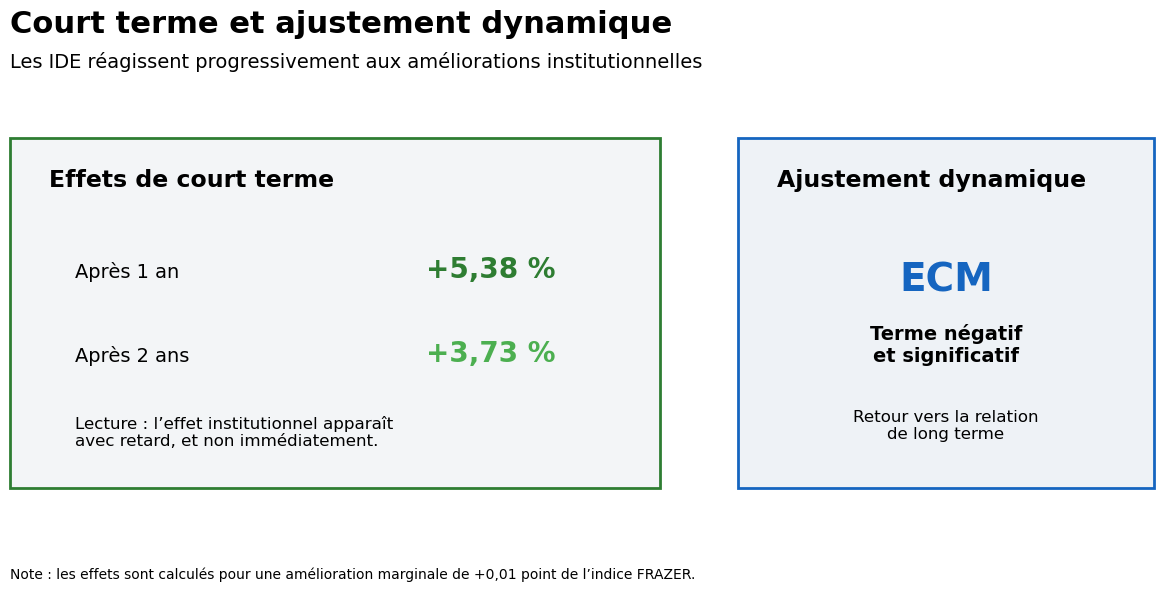

Graphique exporté ici : C:\Users\dell\Desktop\court_terme_ecm_dashboard_IDE.png


In [17]:
import matplotlib.pyplot as plt
from pathlib import Path

fig, ax = plt.subplots(figsize=(13, 7))
ax.axis("off")

# Titre
fig.text(
    0.06, 0.90,
    "Court terme et ajustement dynamique",
    fontsize=22,
    fontweight="bold"
)

fig.text(
    0.06, 0.85,
    "Les IDE réagissent progressivement aux améliorations institutionnelles",
    fontsize=14
)

# Bloc 1 : court terme
rect1 = plt.Rectangle(
    (0.06, 0.25), 0.50, 0.50,
    transform=fig.transFigure,
    facecolor="#F3F5F7",
    edgecolor="#2E7D32",
    linewidth=2
)
fig.patches.append(rect1)

fig.text(0.09, 0.68, "Effets de court terme", fontsize=17, fontweight="bold")

# Effets
fig.text(0.11, 0.55, "Après 1 an", fontsize=14)
fig.text(0.38, 0.55, "+5,38 %", fontsize=20, fontweight="bold", color="#2E7D32")

fig.text(0.11, 0.43, "Après 2 ans", fontsize=14)
fig.text(0.38, 0.43, "+3,73 %", fontsize=20, fontweight="bold", color="#4CAF50")

fig.text(
    0.11, 0.31,
    "Lecture : l’effet institutionnel apparaît\navec retard, et non immédiatement.",
    fontsize=12
)

# Bloc 2 : ECM
rect2 = plt.Rectangle(
    (0.62, 0.25), 0.32, 0.50,
    transform=fig.transFigure,
    facecolor="#EEF2F6",
    edgecolor="#1565C0",
    linewidth=2
)
fig.patches.append(rect2)

fig.text(0.65, 0.68, "Ajustement dynamique", fontsize=17, fontweight="bold")

fig.text(
    0.78, 0.53,
    "ECM",
    ha="center",
    fontsize=28,
    fontweight="bold",
    color="#1565C0"
)

fig.text(
    0.78, 0.43,
    "Terme négatif\net significatif",
    ha="center",
    fontsize=14,
    fontweight="bold"
)

fig.text(
    0.78, 0.32,
    "Retour vers la relation\nde long terme",
    ha="center",
    fontsize=12
)

# Note
fig.text(
    0.06, 0.12,
    "Note : les effets sont calculés pour une amélioration marginale de +0,01 point de l’indice FRAZER.",
    fontsize=10
)

desktop = Path.home() / "Desktop"
file_path = desktop / "court_terme_ecm_dashboard_IDE.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

print("Graphique exporté ici :", file_path)

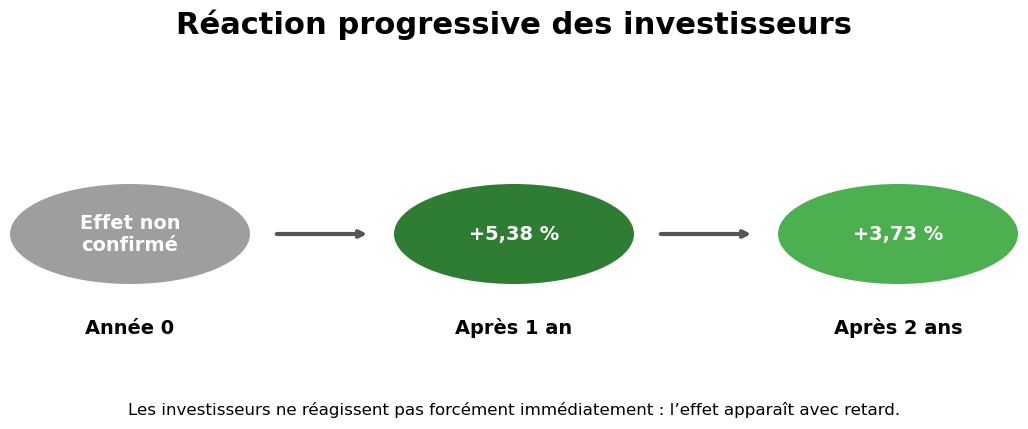

Graphique exporté ici : C:\Users\dell\Desktop\fleche_progression_court_terme_IDE.png


In [18]:
import matplotlib.pyplot as plt
from pathlib import Path

fig, ax = plt.subplots(figsize=(12, 5))
ax.axis("off")

fig.text(
    0.5, 0.88,
    "Réaction progressive des investisseurs",
    ha="center",
    fontsize=22,
    fontweight="bold"
)

steps = [
    ("Année 0", "Effet non\nconfirmé", "#9E9E9E"),
    ("Après 1 an", "+5,38 %", "#2E7D32"),
    ("Après 2 ans", "+3,73 %", "#4CAF50")
]

x_positions = [0.18, 0.50, 0.82]

for i, (x, step) in enumerate(zip(x_positions, steps)):
    title, value, color = step
    
    circle = plt.Circle(
        (x, 0.48), 0.10,
        transform=fig.transFigure,
        facecolor=color,
        edgecolor="none"
    )
    fig.patches.append(circle)
    
    fig.text(
        x, 0.48,
        value,
        ha="center",
        va="center",
        fontsize=14,
        fontweight="bold",
        color="white"
    )
    
    fig.text(
        x, 0.28,
        title,
        ha="center",
        fontsize=14,
        fontweight="bold"
    )
    
    if i < 2:
        ax.annotate(
            "",
            xy=(x_positions[i+1] - 0.12, 0.48),
            xytext=(x + 0.12, 0.48),
            xycoords=fig.transFigure,
            arrowprops=dict(arrowstyle="->", lw=3, color="#555555")
        )

fig.text(
    0.5, 0.12,
    "Les investisseurs ne réagissent pas forcément immédiatement : l’effet apparaît avec retard.",
    ha="center",
    fontsize=12
)

desktop = Path.home() / "Desktop"
file_path = desktop / "fleche_progression_court_terme_IDE.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

print("Graphique exporté ici :", file_path)

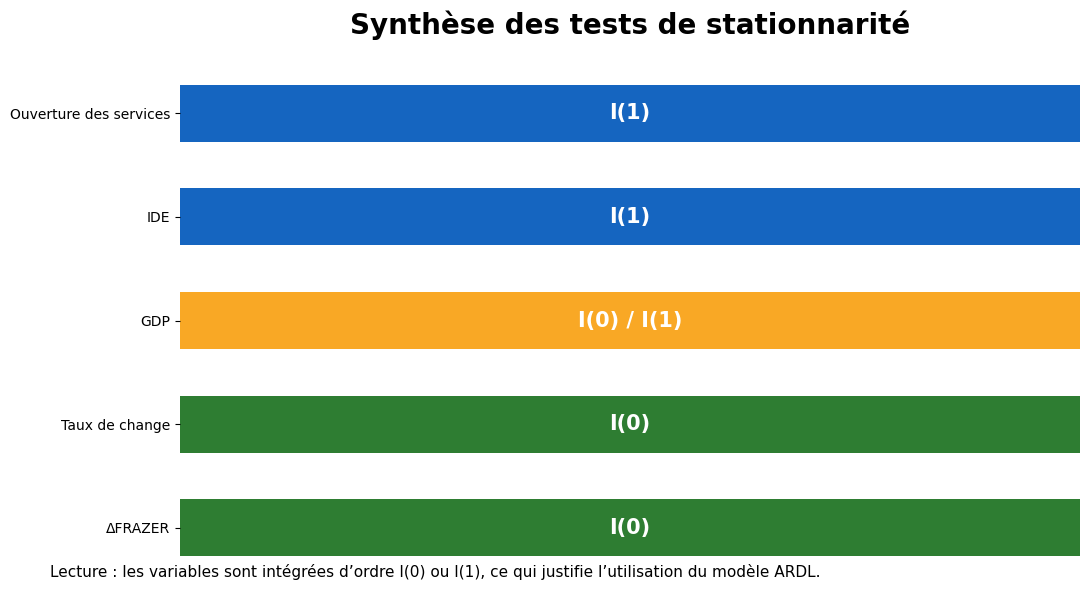

Graphique exporté ici : C:\Users\dell\Desktop\stationnarite_I0_I1.png


In [19]:
import matplotlib.pyplot as plt
from pathlib import Path

# Données stationnarité
variables = ["ΔFRAZER", "Taux de change", "GDP", "IDE", "Ouverture des services"]
categories = ["I(0)", "I(0)", "I(0) / I(1)", "I(1)", "I(1)"]

colors = {
    "I(0)": "#2E7D32",
    "I(1)": "#1565C0",
    "I(0) / I(1)": "#F9A825"
}

bar_colors = [colors[c] for c in categories]

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(variables, [1]*len(variables), color=bar_colors, height=0.55)

for bar, cat in zip(bars, categories):
    ax.text(
        0.5,
        bar.get_y() + bar.get_height()/2,
        cat,
        ha="center",
        va="center",
        fontsize=15,
        fontweight="bold",
        color="white"
    )

ax.set_title(
    "Synthèse des tests de stationnarité",
    fontsize=20,
    fontweight="bold",
    pad=20
)

ax.set_xlim(0, 1)
ax.set_xticks([])
ax.set_xlabel("")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.figtext(
    0.05, 0.03,
    "Lecture : les variables sont intégrées d’ordre I(0) ou I(1), ce qui justifie l’utilisation du modèle ARDL.",
    fontsize=11
)

plt.tight_layout()

desktop = Path.home() / "Desktop"
file_path = desktop / "stationnarite_I0_I1.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

print("Graphique exporté ici :", file_path)

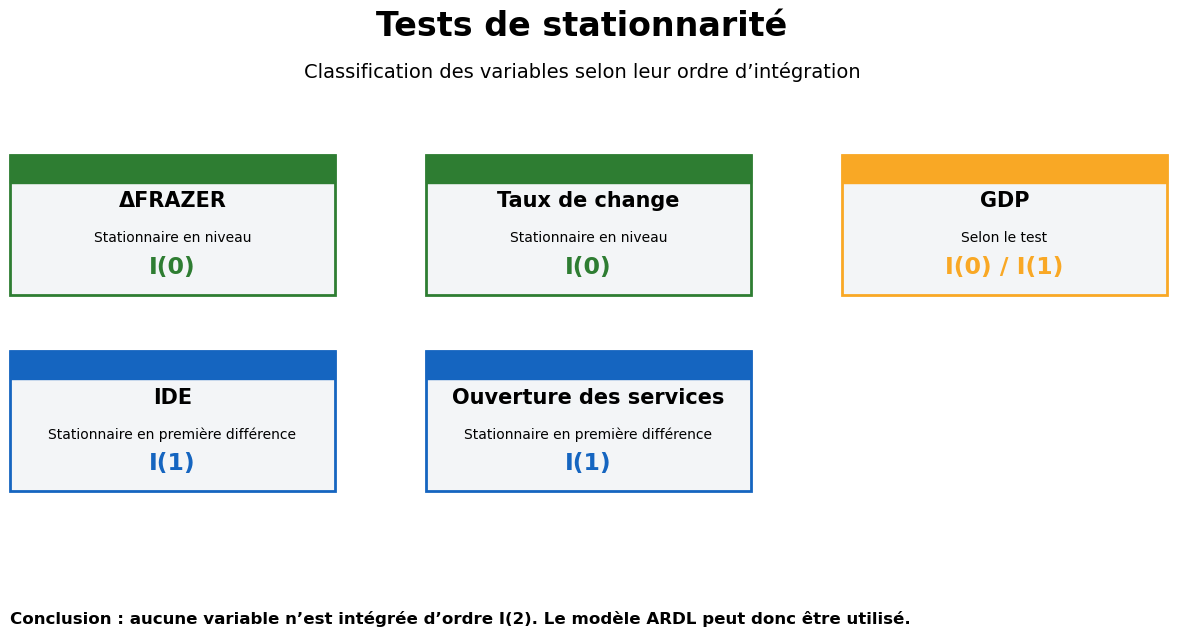

Graphique exporté ici : C:\Users\dell\Desktop\stationnarite_cartes.png


In [20]:
import matplotlib.pyplot as plt
from pathlib import Path

cards = [
    ("ΔFRAZER", "Stationnaire en niveau", "I(0)", "#2E7D32"),
    ("Taux de change", "Stationnaire en niveau", "I(0)", "#2E7D32"),
    ("GDP", "Selon le test", "I(0) / I(1)", "#F9A825"),
    ("IDE", "Stationnaire en première différence", "I(1)", "#1565C0"),
    ("Ouverture des services", "Stationnaire en première différence", "I(1)", "#1565C0"),
]

fig, ax = plt.subplots(figsize=(13, 7))
ax.axis("off")

fig.text(
    0.5, 0.92,
    "Tests de stationnarité",
    ha="center",
    fontsize=24,
    fontweight="bold"
)

fig.text(
    0.5, 0.86,
    "Classification des variables selon leur ordre d’intégration",
    ha="center",
    fontsize=14
)

x_positions = [0.06, 0.38, 0.70]
y_positions = [0.55, 0.27]

positions = [
    (x_positions[0], y_positions[0]),
    (x_positions[1], y_positions[0]),
    (x_positions[2], y_positions[0]),
    (x_positions[0], y_positions[1]),
    (x_positions[1], y_positions[1]),
]

for (x, y), (var, result, decision, color) in zip(positions, cards):
    rect = plt.Rectangle(
        (x, y), 0.25, 0.20,
        transform=fig.transFigure,
        facecolor="#F3F5F7",
        edgecolor=color,
        linewidth=2
    )
    fig.patches.append(rect)
    
    band = plt.Rectangle(
        (x, y + 0.16), 0.25, 0.04,
        transform=fig.transFigure,
        facecolor=color,
        edgecolor=color
    )
    fig.patches.append(band)
    
    fig.text(
        x + 0.125, y + 0.125,
        var,
        ha="center",
        fontsize=15,
        fontweight="bold"
    )
    
    fig.text(
        x + 0.125, y + 0.075,
        result,
        ha="center",
        fontsize=10
    )
    
    fig.text(
        x + 0.125, y + 0.030,
        decision,
        ha="center",
        fontsize=17,
        fontweight="bold",
        color=color
    )

fig.text(
    0.06, 0.08,
    "Conclusion : aucune variable n’est intégrée d’ordre I(2). Le modèle ARDL peut donc être utilisé.",
    fontsize=12,
    fontweight="bold"
)

desktop = Path.home() / "Desktop"
file_path = desktop / "stationnarite_cartes.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

print("Graphique exporté ici :", file_path)

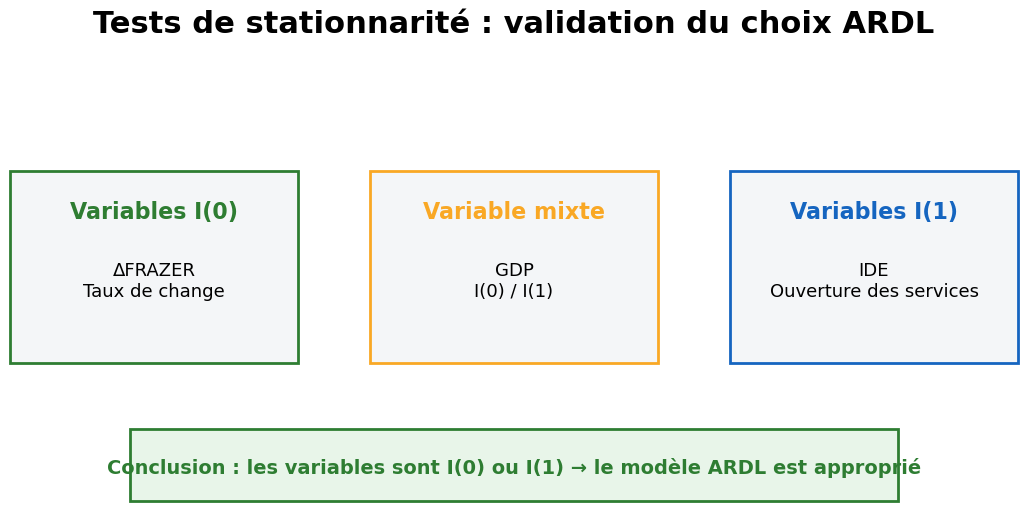

Graphique exporté ici : C:\Users\dell\Desktop\stationnarite_validation_ardl.png


In [21]:
import matplotlib.pyplot as plt
from pathlib import Path

fig, ax = plt.subplots(figsize=(12, 6))
ax.axis("off")

fig.text(
    0.5, 0.90,
    "Tests de stationnarité : validation du choix ARDL",
    ha="center",
    fontsize=22,
    fontweight="bold"
)

# Trois blocs
blocks = [
    ("Variables I(0)", "ΔFRAZER\nTaux de change", "#2E7D32"),
    ("Variable mixte", "GDP\nI(0) / I(1)", "#F9A825"),
    ("Variables I(1)", "IDE\nOuverture des services", "#1565C0"),
]

x_positions = [0.08, 0.38, 0.68]

for x, (title, content, color) in zip(x_positions, blocks):
    rect = plt.Rectangle(
        (x, 0.35), 0.24, 0.32,
        transform=fig.transFigure,
        facecolor="#F4F6F8",
        edgecolor=color,
        linewidth=2
    )
    fig.patches.append(rect)
    
    fig.text(
        x + 0.12, 0.59,
        title,
        ha="center",
        fontsize=16,
        fontweight="bold",
        color=color
    )
    
    fig.text(
        x + 0.12, 0.46,
        content,
        ha="center",
        fontsize=13
    )

# Conclusion
conclusion_box = plt.Rectangle(
    (0.18, 0.12), 0.64, 0.12,
    transform=fig.transFigure,
    facecolor="#E8F5E9",
    edgecolor="#2E7D32",
    linewidth=2
)
fig.patches.append(conclusion_box)

fig.text(
    0.5, 0.165,
    "Conclusion : les variables sont I(0) ou I(1) → le modèle ARDL est approprié",
    ha="center",
    fontsize=14,
    fontweight="bold",
    color="#2E7D32"
)

desktop = Path.home() / "Desktop"
file_path = desktop / "stationnarite_validation_ardl.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

print("Graphique exporté ici :", file_path)

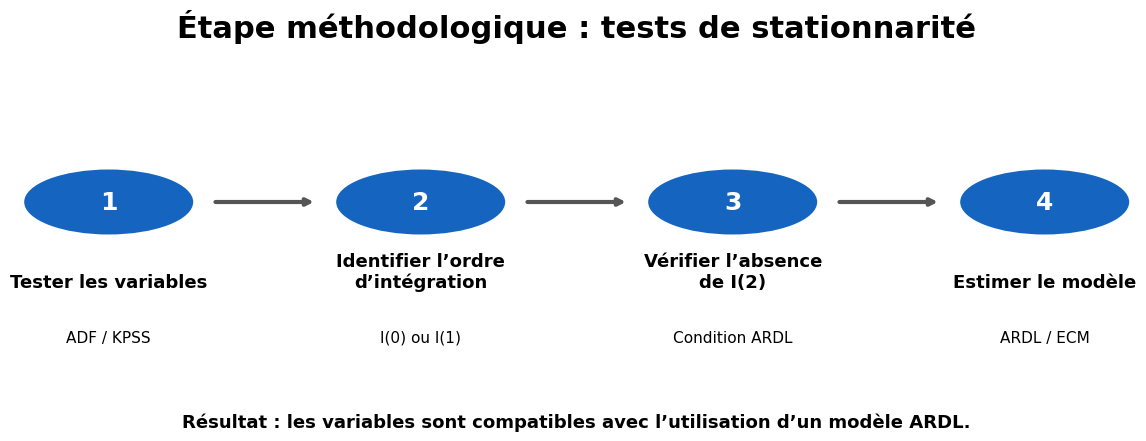

Graphique exporté ici : C:\Users\dell\Desktop\stationnarite_processus_ardl.png


In [22]:
import matplotlib.pyplot as plt
from pathlib import Path

fig, ax = plt.subplots(figsize=(13, 5))
ax.axis("off")

fig.text(
    0.5, 0.88,
    "Étape méthodologique : tests de stationnarité",
    ha="center",
    fontsize=22,
    fontweight="bold"
)

steps = [
    ("1", "Tester les variables", "ADF / KPSS"),
    ("2", "Identifier l’ordre\nd’intégration", "I(0) ou I(1)"),
    ("3", "Vérifier l’absence\nde I(2)", "Condition ARDL"),
    ("4", "Estimer le modèle", "ARDL / ECM"),
]

x_positions = [0.14, 0.38, 0.62, 0.86]

for i, (x, step) in enumerate(zip(x_positions, steps)):
    num, title, subtitle = step
    
    circle = plt.Circle(
        (x, 0.55), 0.065,
        transform=fig.transFigure,
        facecolor="#1565C0",
        edgecolor="none"
    )
    fig.patches.append(circle)
    
    fig.text(
        x, 0.55,
        num,
        ha="center",
        va="center",
        fontsize=18,
        fontweight="bold",
        color="white"
    )
    
    fig.text(
        x, 0.38,
        title,
        ha="center",
        fontsize=13,
        fontweight="bold"
    )
    
    fig.text(
        x, 0.27,
        subtitle,
        ha="center",
        fontsize=11
    )
    
    if i < 3:
        ax.annotate(
            "",
            xy=(x_positions[i+1] - 0.08, 0.55),
            xytext=(x + 0.08, 0.55),
            xycoords=fig.transFigure,
            arrowprops=dict(arrowstyle="->", lw=3, color="#555555")
        )

fig.text(
    0.5, 0.10,
    "Résultat : les variables sont compatibles avec l’utilisation d’un modèle ARDL.",
    ha="center",
    fontsize=13,
    fontweight="bold"
)

desktop = Path.home() / "Desktop"
file_path = desktop / "stationnarite_processus_ardl.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

print("Graphique exporté ici :", file_path)

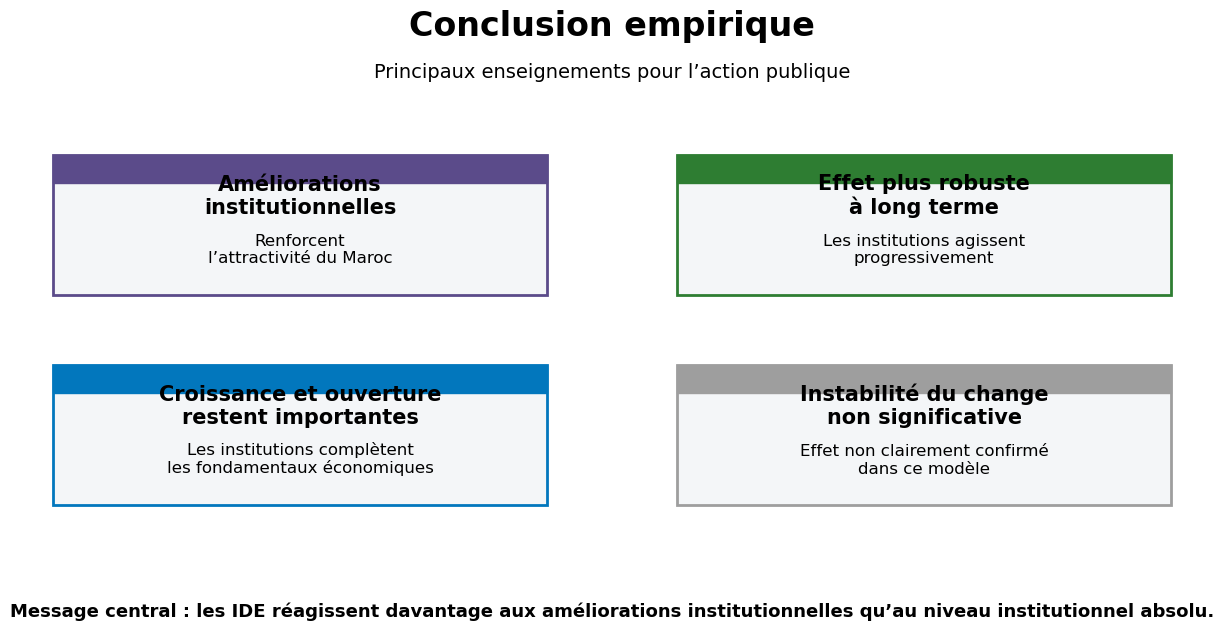

Graphique exporté ici : C:\Users\dell\Desktop\conclusion_empirique_cartes.png


In [23]:
import matplotlib.pyplot as plt
from pathlib import Path

items = [
    {
        "resultat": "Améliorations\ninstitutionnelles",
        "implication": "Renforcent\nl’attractivité du Maroc",
        "color": "#5B4B8A"
    },
    {
        "resultat": "Effet plus robuste\nà long terme",
        "implication": "Les institutions agissent\nprogressivement",
        "color": "#2E7D32"
    },
    {
        "resultat": "Croissance et ouverture\nrestent importantes",
        "implication": "Les institutions complètent\nles fondamentaux économiques",
        "color": "#0277BD"
    },
    {
        "resultat": "Instabilité du change\nnon significative",
        "implication": "Effet non clairement confirmé\ndans ce modèle",
        "color": "#9E9E9E"
    }
]

fig, ax = plt.subplots(figsize=(13, 7))
ax.axis("off")

fig.text(
    0.5, 0.92,
    "Conclusion empirique",
    ha="center",
    fontsize=24,
    fontweight="bold"
)

fig.text(
    0.5, 0.86,
    "Principaux enseignements pour l’action publique",
    ha="center",
    fontsize=14
)

positions = [(0.07, 0.55), (0.55, 0.55), (0.07, 0.25), (0.55, 0.25)]

for (x, y), item in zip(positions, items):
    rect = plt.Rectangle(
        (x, y), 0.38, 0.20,
        transform=fig.transFigure,
        facecolor="#F4F6F8",
        edgecolor=item["color"],
        linewidth=2
    )
    fig.patches.append(rect)

    band = plt.Rectangle(
        (x, y + 0.16), 0.38, 0.04,
        transform=fig.transFigure,
        facecolor=item["color"],
        edgecolor=item["color"]
    )
    fig.patches.append(band)

    fig.text(
        x + 0.19, y + 0.115,
        item["resultat"],
        ha="center",
        fontsize=15,
        fontweight="bold"
    )

    fig.text(
        x + 0.19, y + 0.045,
        item["implication"],
        ha="center",
        fontsize=12
    )

fig.text(
    0.5, 0.09,
    "Message central : les IDE réagissent davantage aux améliorations institutionnelles qu’au niveau institutionnel absolu.",
    ha="center",
    fontsize=13,
    fontweight="bold"
)

desktop = Path.home() / "Desktop"
file_path = desktop / "conclusion_empirique_cartes.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

print("Graphique exporté ici :", file_path)

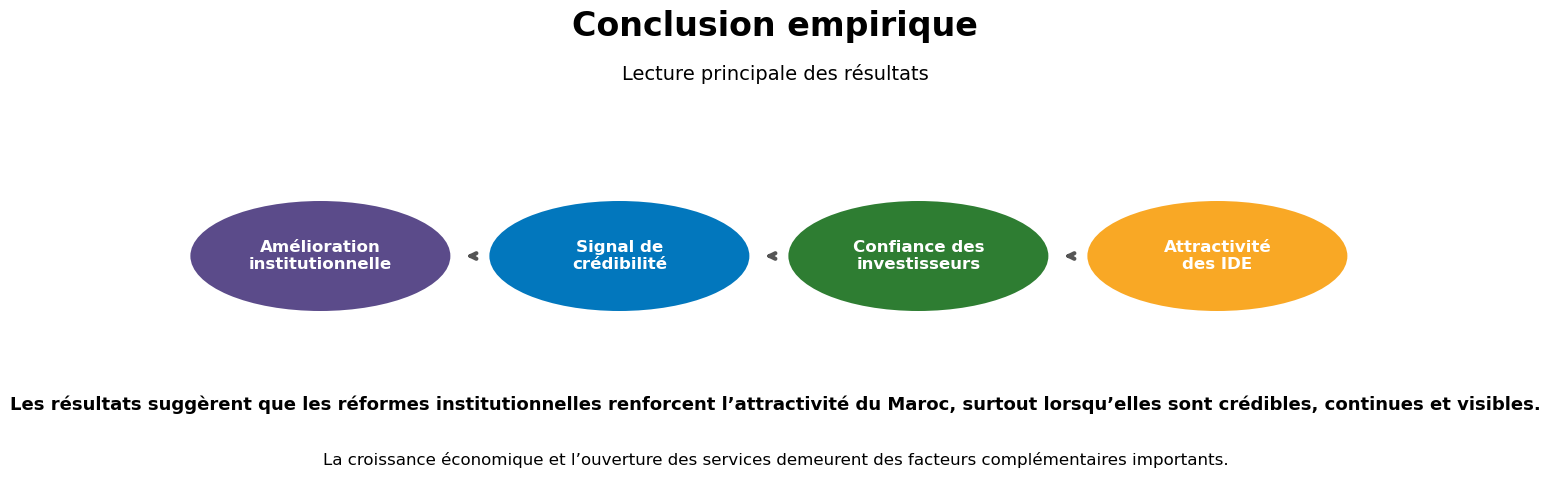

Graphique exporté ici : C:\Users\dell\Desktop\conclusion_empirique_chaine_logique.png


In [24]:
import matplotlib.pyplot as plt
from pathlib import Path

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.axis("off")

fig.text(
    0.5, 0.88,
    "Conclusion empirique",
    ha="center",
    fontsize=24,
    fontweight="bold"
)

fig.text(
    0.5, 0.80,
    "Lecture principale des résultats",
    ha="center",
    fontsize=14
)

steps = [
    ("Amélioration\ninstitutionnelle", "#5B4B8A"),
    ("Signal de\ncrédibilité", "#0277BD"),
    ("Confiance des\ninvestisseurs", "#2E7D32"),
    ("Attractivité\ndes IDE", "#F9A825")
]

x_positions = [0.15, 0.38, 0.61, 0.84]

for i, ((label, color), x) in enumerate(zip(steps, x_positions)):
    circle = plt.Circle(
        (x, 0.48), 0.10,
        transform=fig.transFigure,
        facecolor=color,
        edgecolor="none"
    )
    fig.patches.append(circle)

    fig.text(
        x, 0.48,
        label,
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        color="white"
    )

    if i < len(steps) - 1:
        ax.annotate(
            "",
            xy=(x_positions[i+1] - 0.12, 0.48),
            xytext=(x + 0.12, 0.48),
            xycoords=fig.transFigure,
            arrowprops=dict(arrowstyle="->", lw=3, color="#555555")
        )

fig.text(
    0.5, 0.20,
    "Les résultats suggèrent que les réformes institutionnelles renforcent l’attractivité du Maroc, surtout lorsqu’elles sont crédibles, continues et visibles.",
    ha="center",
    fontsize=13,
    fontweight="bold"
)

fig.text(
    0.5, 0.10,
    "La croissance économique et l’ouverture des services demeurent des facteurs complémentaires importants.",
    ha="center",
    fontsize=12
)

desktop = Path.home() / "Desktop"
file_path = desktop / "conclusion_empirique_chaine_logique.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

print("Graphique exporté ici :", file_path)

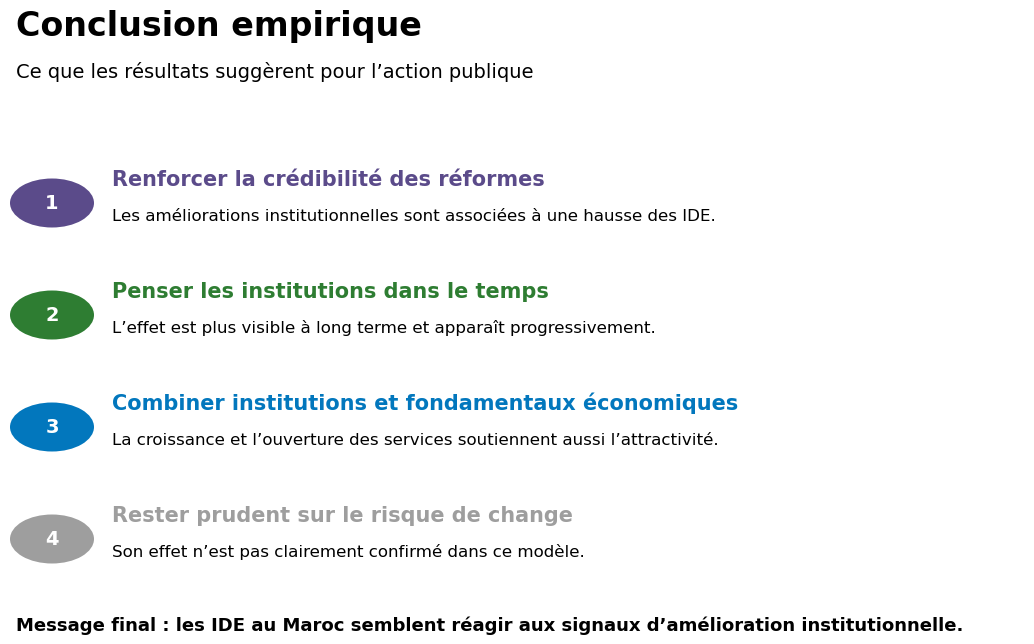

Graphique exporté ici : C:\Users\dell\Desktop\conclusion_empirique_policy_takeaways.png


In [25]:
import matplotlib.pyplot as plt
from pathlib import Path

fig, ax = plt.subplots(figsize=(12, 7))
ax.axis("off")

fig.text(
    0.06, 0.92,
    "Conclusion empirique",
    fontsize=24,
    fontweight="bold"
)

fig.text(
    0.06, 0.86,
    "Ce que les résultats suggèrent pour l’action publique",
    fontsize=14
)

takeaways = [
    ("1", "Renforcer la crédibilité des réformes", 
     "Les améliorations institutionnelles sont associées à une hausse des IDE."),
    ("2", "Penser les institutions dans le temps", 
     "L’effet est plus visible à long terme et apparaît progressivement."),
    ("3", "Combiner institutions et fondamentaux économiques", 
     "La croissance et l’ouverture des services soutiennent aussi l’attractivité."),
    ("4", "Rester prudent sur le risque de change", 
     "Son effet n’est pas clairement confirmé dans ce modèle.")
]

colors = ["#5B4B8A", "#2E7D32", "#0277BD", "#9E9E9E"]
y_positions = [0.68, 0.52, 0.36, 0.20]

for (num, title, desc), color, y in zip(takeaways, colors, y_positions):
    circle = plt.Circle(
        (0.09, y), 0.035,
        transform=fig.transFigure,
        facecolor=color,
        edgecolor="none"
    )
    fig.patches.append(circle)

    fig.text(
        0.09, y,
        num,
        ha="center",
        va="center",
        fontsize=14,
        fontweight="bold",
        color="white"
    )

    fig.text(
        0.14, y + 0.025,
        title,
        fontsize=15,
        fontweight="bold",
        color=color
    )

    fig.text(
        0.14, y - 0.025,
        desc,
        fontsize=12
    )

fig.text(
    0.06, 0.07,
    "Message final : les IDE au Maroc semblent réagir aux signaux d’amélioration institutionnelle.",
    fontsize=13,
    fontweight="bold"
)

desktop = Path.home() / "Desktop"
file_path = desktop / "conclusion_empirique_policy_takeaways.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

print("Graphique exporté ici :", file_path)

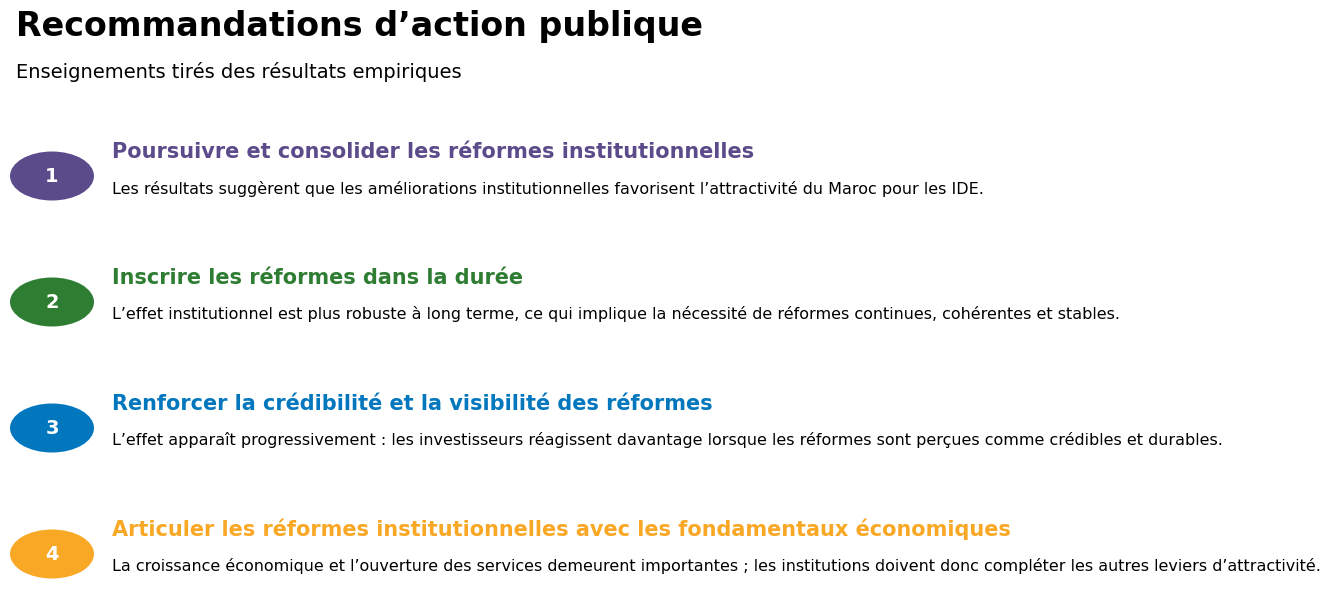

Graphique exporté ici : C:\Users\dell\Desktop\recommandations_action_publique.png


In [26]:
import matplotlib.pyplot as plt
from pathlib import Path

fig, ax = plt.subplots(figsize=(12, 7))
ax.axis("off")

fig.text(
    0.06, 0.92,
    "Recommandations d’action publique",
    fontsize=24,
    fontweight="bold"
)

fig.text(
    0.06, 0.86,
    "Enseignements tirés des résultats empiriques",
    fontsize=14
)

recommendations = [
    (
        "1",
        "Poursuivre et consolider les réformes institutionnelles",
        "Les résultats suggèrent que les améliorations institutionnelles favorisent l’attractivité du Maroc pour les IDE."
    ),
    (
        "2",
        "Inscrire les réformes dans la durée",
        "L’effet institutionnel est plus robuste à long terme, ce qui implique la nécessité de réformes continues, cohérentes et stables."
    ),
    (
        "3",
        "Renforcer la crédibilité et la visibilité des réformes",
        "L’effet apparaît progressivement : les investisseurs réagissent davantage lorsque les réformes sont perçues comme crédibles et durables."
    ),
    (
        "4",
        "Articuler les réformes institutionnelles avec les fondamentaux économiques",
        "La croissance économique et l’ouverture des services demeurent importantes ; les institutions doivent donc compléter les autres leviers d’attractivité."
    )
]

colors = ["#5B4B8A", "#2E7D32", "#0277BD", "#F9A825"]
y_positions = [0.72, 0.54, 0.36, 0.18]

for (num, title, desc), color, y in zip(recommendations, colors, y_positions):
    circle = plt.Circle(
        (0.09, y), 0.035,
        transform=fig.transFigure,
        facecolor=color,
        edgecolor="none"
    )
    fig.patches.append(circle)

    fig.text(
        0.09, y,
        num,
        ha="center",
        va="center",
        fontsize=14,
        fontweight="bold",
        color="white"
    )

    fig.text(
        0.14, y + 0.025,
        title,
        fontsize=15,
        fontweight="bold",
        color=color
    )

    fig.text(
        0.14, y - 0.025,
        desc,
        fontsize=11.5
    )

desktop = Path.home() / "Desktop"
file_path = desktop / "recommandations_action_publique.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

print("Graphique exporté ici :", file_path)

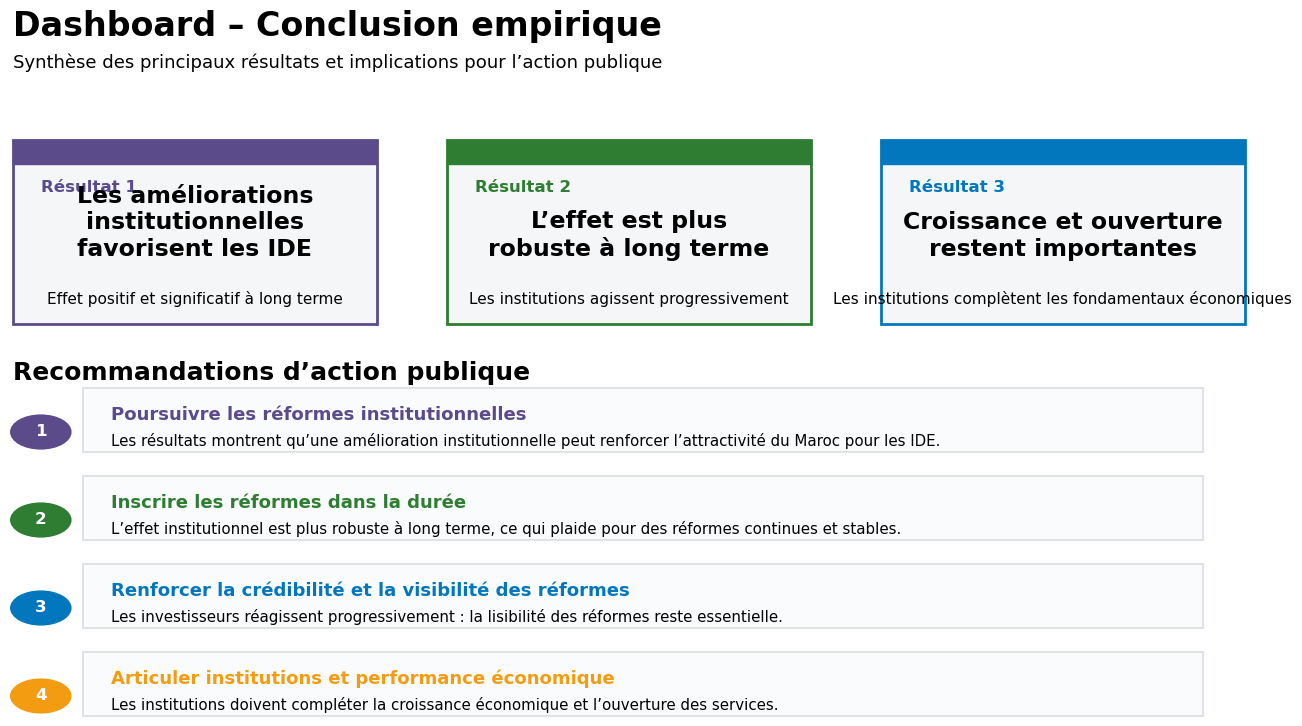

Dashboard exporté ici : C:\Users\dell\Desktop\dashboard_conclusion_empirique.png


In [27]:
import matplotlib.pyplot as plt
from pathlib import Path

fig, ax = plt.subplots(figsize=(14, 8))
ax.axis("off")

# =========================
# TITRE
# =========================
fig.text(
    0.06, 0.93,
    "Dashboard – Conclusion empirique",
    fontsize=24,
    fontweight="bold"
)

fig.text(
    0.06, 0.89,
    "Synthèse des principaux résultats et implications pour l’action publique",
    fontsize=13
)

# =========================
# BLOCS DE RESULTATS (haut)
# =========================
results = [
    {
        "title": "Résultat 1",
        "headline": "Les améliorations\ninstitutionnelles\nfavorisent les IDE",
        "detail": "Effet positif et significatif à long terme",
        "color": "#5B4B8A"
    },
    {
        "title": "Résultat 2",
        "headline": "L’effet est plus\nrobuste à long terme",
        "detail": "Les institutions agissent progressivement",
        "color": "#2E7D32"
    },
    {
        "title": "Résultat 3",
        "headline": "Croissance et ouverture\nrestent importantes",
        "detail": "Les institutions complètent les fondamentaux économiques",
        "color": "#0277BD"
    }
]

x_positions = [0.06, 0.37, 0.68]

for x, item in zip(x_positions, results):
    # carte
    rect = plt.Rectangle(
        (x, 0.57), 0.26, 0.23,
        transform=fig.transFigure,
        facecolor="#F4F6F8",
        edgecolor=item["color"],
        linewidth=2
    )
    fig.patches.append(rect)

    # bande couleur
    band = plt.Rectangle(
        (x, 0.77), 0.26, 0.03,
        transform=fig.transFigure,
        facecolor=item["color"],
        edgecolor=item["color"]
    )
    fig.patches.append(band)

    fig.text(
        x + 0.02, 0.735,
        item["title"],
        fontsize=12,
        fontweight="bold",
        color=item["color"]
    )

    fig.text(
        x + 0.13, 0.655,
        item["headline"],
        ha="center",
        fontsize=17,
        fontweight="bold"
    )

    fig.text(
        x + 0.13, 0.595,
        item["detail"],
        ha="center",
        fontsize=11
    )

# =========================
# SECTION RECOMMANDATIONS
# =========================
fig.text(
    0.06, 0.50,
    "Recommandations d’action publique",
    fontsize=18,
    fontweight="bold"
)

recommendations = [
    (
        "1",
        "Poursuivre les réformes institutionnelles",
        "Les résultats montrent qu’une amélioration institutionnelle peut renforcer l’attractivité du Maroc pour les IDE.",
        "#5B4B8A"
    ),
    (
        "2",
        "Inscrire les réformes dans la durée",
        "L’effet institutionnel est plus robuste à long terme, ce qui plaide pour des réformes continues et stables.",
        "#2E7D32"
    ),
    (
        "3",
        "Renforcer la crédibilité et la visibilité des réformes",
        "Les investisseurs réagissent progressivement : la lisibilité des réformes reste essentielle.",
        "#0277BD"
    ),
    (
        "4",
        "Articuler institutions et performance économique",
        "Les institutions doivent compléter la croissance économique et l’ouverture des services.",
        "#F39C12"
    )
]

y_positions = [0.42, 0.31, 0.20, 0.09]

for (num, title, desc, color), y in zip(recommendations, y_positions):
    # petit cercle numéroté
    circle = plt.Circle(
        (0.08, y + 0.015), 0.022,
        transform=fig.transFigure,
        facecolor=color,
        edgecolor="none"
    )
    fig.patches.append(circle)

    fig.text(
        0.08, y + 0.015,
        num,
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        color="white"
    )

    # bloc texte
    rect = plt.Rectangle(
        (0.11, y - 0.01), 0.80, 0.08,
        transform=fig.transFigure,
        facecolor="#FAFBFC",
        edgecolor="#D9DEE3",
        linewidth=1.2
    )
    fig.patches.append(rect)

    fig.text(
        0.13, y + 0.03,
        title,
        fontsize=13,
        fontweight="bold",
        color=color
    )

    fig.text(
        0.13, y - 0.002,
        desc,
        fontsize=10.8
    )

# =========================
# EXPORT
# =========================
desktop = Path.home() / "Desktop"
file_path = desktop / "dashboard_conclusion_empirique.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

print("Dashboard exporté ici :", file_path)

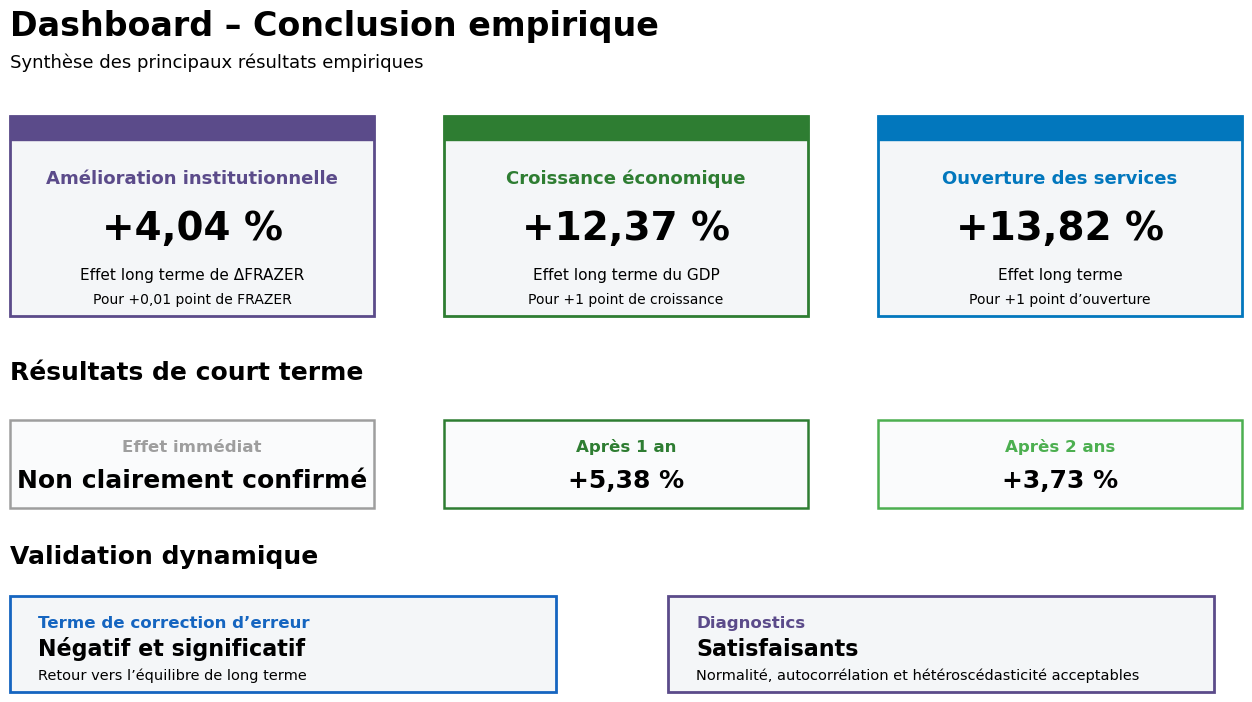

Dashboard exporté ici : C:\Users\dell\Desktop\dashboard_conclusion_empirique_resultats.png


In [28]:
import matplotlib.pyplot as plt
from pathlib import Path

fig, ax = plt.subplots(figsize=(14, 8))
ax.axis("off")

# =========================
# TITRE
# =========================
fig.text(
    0.06, 0.93,
    "Dashboard – Conclusion empirique",
    fontsize=24,
    fontweight="bold"
)

fig.text(
    0.06, 0.89,
    "Synthèse des principaux résultats empiriques",
    fontsize=13
)

# =========================
# KPI CARDS : RÉSULTATS CHIFFRÉS
# =========================
kpis = [
    {
        "title": "Amélioration institutionnelle",
        "value": "+4,04 %",
        "subtitle": "Effet long terme de ΔFRAZER",
        "detail": "Pour +0,01 point de FRAZER",
        "color": "#5B4B8A"
    },
    {
        "title": "Croissance économique",
        "value": "+12,37 %",
        "subtitle": "Effet long terme du GDP",
        "detail": "Pour +1 point de croissance",
        "color": "#2E7D32"
    },
    {
        "title": "Ouverture des services",
        "value": "+13,82 %",
        "subtitle": "Effet long terme",
        "detail": "Pour +1 point d’ouverture",
        "color": "#0277BD"
    }
]

x_positions = [0.06, 0.37, 0.68]

for x, item in zip(x_positions, kpis):
    rect = plt.Rectangle(
        (x, 0.58), 0.26, 0.25,
        transform=fig.transFigure,
        facecolor="#F4F6F8",
        edgecolor=item["color"],
        linewidth=2
    )
    fig.patches.append(rect)

    band = plt.Rectangle(
        (x, 0.80), 0.26, 0.03,
        transform=fig.transFigure,
        facecolor=item["color"],
        edgecolor=item["color"]
    )
    fig.patches.append(band)

    fig.text(
        x + 0.13, 0.745,
        item["title"],
        ha="center",
        fontsize=13,
        fontweight="bold",
        color=item["color"]
    )

    fig.text(
        x + 0.13, 0.675,
        item["value"],
        ha="center",
        fontsize=28,
        fontweight="bold"
    )

    fig.text(
        x + 0.13, 0.625,
        item["subtitle"],
        ha="center",
        fontsize=11
    )

    fig.text(
        x + 0.13, 0.595,
        item["detail"],
        ha="center",
        fontsize=10
    )

# =========================
# BLOC COURT TERME
# =========================
fig.text(
    0.06, 0.50,
    "Résultats de court terme",
    fontsize=18,
    fontweight="bold"
)

short_terms = [
    ("Effet immédiat", "Non clairement confirmé", "#9E9E9E"),
    ("Après 1 an", "+5,38 %", "#2E7D32"),
    ("Après 2 ans", "+3,73 %", "#4CAF50")
]

x_positions_2 = [0.06, 0.37, 0.68]

for x, (title, value, color) in zip(x_positions_2, short_terms):
    rect = plt.Rectangle(
        (x, 0.34), 0.26, 0.11,
        transform=fig.transFigure,
        facecolor="#FAFBFC",
        edgecolor=color,
        linewidth=1.8
    )
    fig.patches.append(rect)

    fig.text(
        x + 0.13, 0.410,
        title,
        ha="center",
        fontsize=12,
        fontweight="bold",
        color=color
    )

    fig.text(
        x + 0.13, 0.365,
        value,
        ha="center",
        fontsize=18,
        fontweight="bold"
    )

# =========================
# BLOC VALIDATION DYNAMIQUE
# =========================
fig.text(
    0.06, 0.27,
    "Validation dynamique",
    fontsize=18,
    fontweight="bold"
)

validation = [
    {
        "title": "Terme de correction d’erreur",
        "value": "Négatif et significatif",
        "detail": "Retour vers l’équilibre de long terme",
        "color": "#1565C0"
    },
    {
        "title": "Diagnostics",
        "value": "Satisfaisants",
        "detail": "Normalité, autocorrélation et hétéroscédasticité acceptables",
        "color": "#5B4B8A"
    }
]

x_positions_3 = [0.06, 0.53]

for x, item in zip(x_positions_3, validation):
    rect = plt.Rectangle(
        (x, 0.11), 0.39, 0.12,
        transform=fig.transFigure,
        facecolor="#F4F6F8",
        edgecolor=item["color"],
        linewidth=2
    )
    fig.patches.append(rect)

    fig.text(
        x + 0.02, 0.190,
        item["title"],
        fontsize=12,
        fontweight="bold",
        color=item["color"]
    )

    fig.text(
        x + 0.02, 0.155,
        item["value"],
        fontsize=16,
        fontweight="bold"
    )

    fig.text(
        x + 0.02, 0.125,
        item["detail"],
        fontsize=10.5
    )

# =========================
# EXPORT
# =========================
desktop = Path.home() / "Desktop"
file_path = desktop / "dashboard_conclusion_empirique_resultats.png"

plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

print("Dashboard exporté ici :", file_path)

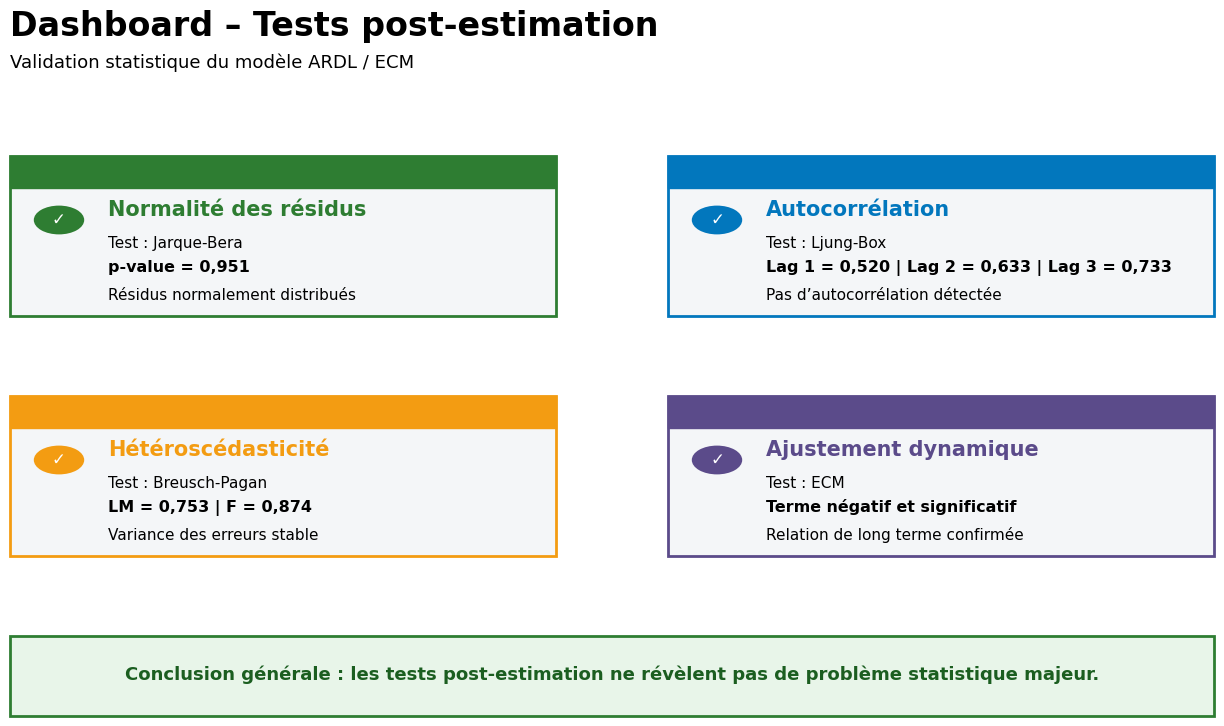

Dashboard exporté ici : C:\Users\dell\Desktop\dashboard_tests_post_estimation.png


In [29]:
import matplotlib.pyplot as plt
from pathlib import Path

fig, ax = plt.subplots(figsize=(14, 8))
ax.axis("off")

# =========================
# TITRE
# =========================
fig.text(
    0.06, 0.93,
    "Dashboard – Tests post-estimation",
    fontsize=24,
    fontweight="bold"
)

fig.text(
    0.06, 0.89,
    "Validation statistique du modèle ARDL / ECM",
    fontsize=13
)

# =========================
# DONNÉES
# =========================
tests = [
    {
        "title": "Normalité des résidus",
        "test": "Jarque-Bera",
        "value": "p-value = 0,951",
        "conclusion": "Résidus normalement distribués",
        "color": "#2E7D32"
    },
    {
        "title": "Autocorrélation",
        "test": "Ljung-Box",
        "value": "Lag 1 = 0,520 | Lag 2 = 0,633 | Lag 3 = 0,733",
        "conclusion": "Pas d’autocorrélation détectée",
        "color": "#0277BD"
    },
    {
        "title": "Hétéroscédasticité",
        "test": "Breusch-Pagan",
        "value": "LM = 0,753 | F = 0,874",
        "conclusion": "Variance des erreurs stable",
        "color": "#F39C12"
    },
    {
        "title": "Ajustement dynamique",
        "test": "ECM",
        "value": "Terme négatif et significatif",
        "conclusion": "Relation de long terme confirmée",
        "color": "#5B4B8A"
    }
]

# positions
positions = [(0.06, 0.58), (0.53, 0.58), (0.06, 0.28), (0.53, 0.28)]

# =========================
# CARTES
# =========================
for (x, y), item in zip(positions, tests):
    # fond carte
    rect = plt.Rectangle(
        (x, y), 0.39, 0.20,
        transform=fig.transFigure,
        facecolor="#F4F6F8",
        edgecolor=item["color"],
        linewidth=2
    )
    fig.patches.append(rect)

    # bande couleur
    band = plt.Rectangle(
        (x, y + 0.16), 0.39, 0.04,
        transform=fig.transFigure,
        facecolor=item["color"],
        edgecolor=item["color"]
    )
    fig.patches.append(band)

    # petit rond check
    circle = plt.Circle(
        (x + 0.035, y + 0.12), 0.018,
        transform=fig.transFigure,
        facecolor=item["color"],
        edgecolor="none"
    )
    fig.patches.append(circle)

    fig.text(
        x + 0.035, y + 0.12,
        "✓",
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        color="white"
    )

    fig.text(
        x + 0.07, y + 0.125,
        item["title"],
        fontsize=15,
        fontweight="bold",
        color=item["color"]
    )

    fig.text(
        x + 0.07, y + 0.085,
        f"Test : {item['test']}",
        fontsize=11
    )

    fig.text(
        x + 0.07, y + 0.055,
        item["value"],
        fontsize=11.5,
        fontweight="bold"
    )

    fig.text(
        x + 0.07, y + 0.020,
        item["conclusion"],
        fontsize=11
    )

# =========================
# BANDEAU BAS
# =========================
bottom = plt.Rectangle(
    (0.06, 0.08), 0.86, 0.10,
    transform=fig.transFigure,
    facecolor="#E8F5E9",
    edgecolor="#2E7D32",
    linewidth=2
)
fig.patches.append(bottom)

fig.text(
    0.49, 0.125,
    "Conclusion générale : les tests post-estimation ne révèlent pas de problème statistique majeur.",
    ha="center",
    fontsize=13,
    fontweight="bold",
    color="#1B5E20"
)

# =========================
# EXPORT
# =========================
desktop = Path.home() / "Desktop"
file_path = desktop / "dashboard_tests_post_estimation.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

print("Dashboard exporté ici :", file_path)

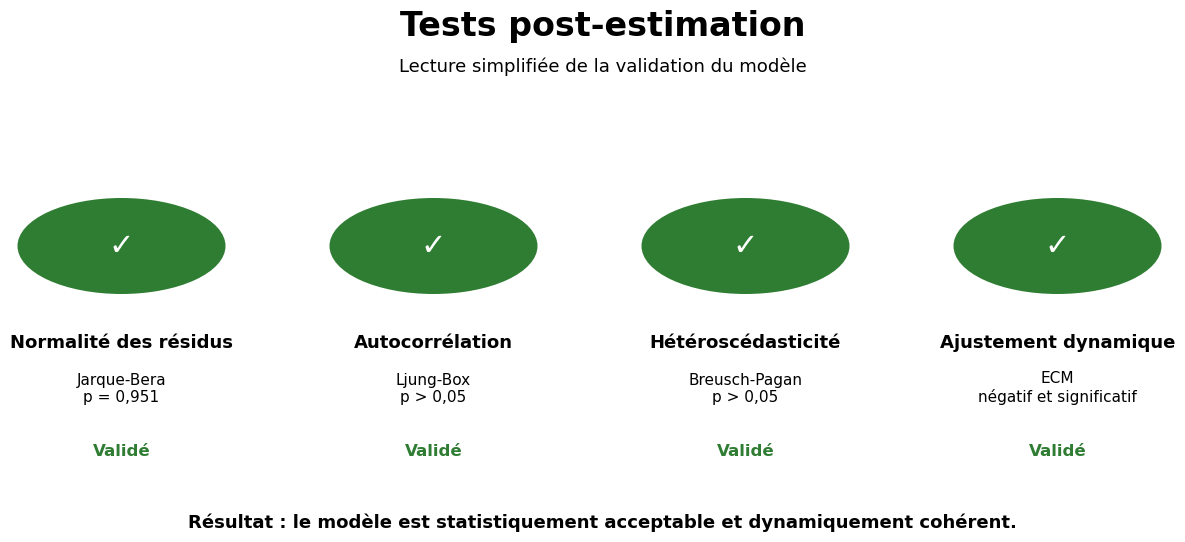

Graphique exporté ici : C:\Users\dell\Desktop\tests_post_estimation_feux.png


In [30]:
import matplotlib.pyplot as plt
from pathlib import Path

fig, ax = plt.subplots(figsize=(13, 6))
ax.axis("off")

fig.text(
    0.5, 0.90,
    "Tests post-estimation",
    ha="center",
    fontsize=24,
    fontweight="bold"
)

fig.text(
    0.5, 0.84,
    "Lecture simplifiée de la validation du modèle",
    ha="center",
    fontsize=13
)

items = [
    ("Normalité des résidus", "Jarque-Bera\np = 0,951", "Validé", "#2E7D32"),
    ("Autocorrélation", "Ljung-Box\np > 0,05", "Validé", "#2E7D32"),
    ("Hétéroscédasticité", "Breusch-Pagan\np > 0,05", "Validé", "#2E7D32"),
    ("Ajustement dynamique", "ECM\nnégatif et significatif", "Validé", "#2E7D32"),
]

x_positions = [0.13, 0.37, 0.61, 0.85]

for x, (title, detail, status, color) in zip(x_positions, items):
    circle = plt.Circle(
        (x, 0.55), 0.08,
        transform=fig.transFigure,
        facecolor=color,
        edgecolor="none"
    )
    fig.patches.append(circle)

    fig.text(
        x, 0.55,
        "✓",
        ha="center",
        va="center",
        fontsize=22,
        fontweight="bold",
        color="white"
    )

    fig.text(
        x, 0.38,
        title,
        ha="center",
        fontsize=13,
        fontweight="bold"
    )

    fig.text(
        x, 0.29,
        detail,
        ha="center",
        fontsize=11
    )

    fig.text(
        x, 0.20,
        status,
        ha="center",
        fontsize=12,
        fontweight="bold",
        color=color
    )

fig.text(
    0.5, 0.08,
    "Résultat : le modèle est statistiquement acceptable et dynamiquement cohérent.",
    ha="center",
    fontsize=13,
    fontweight="bold"
)

desktop = Path.home() / "Desktop"
file_path = desktop / "tests_post_estimation_feux.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

print("Graphique exporté ici :", file_path)

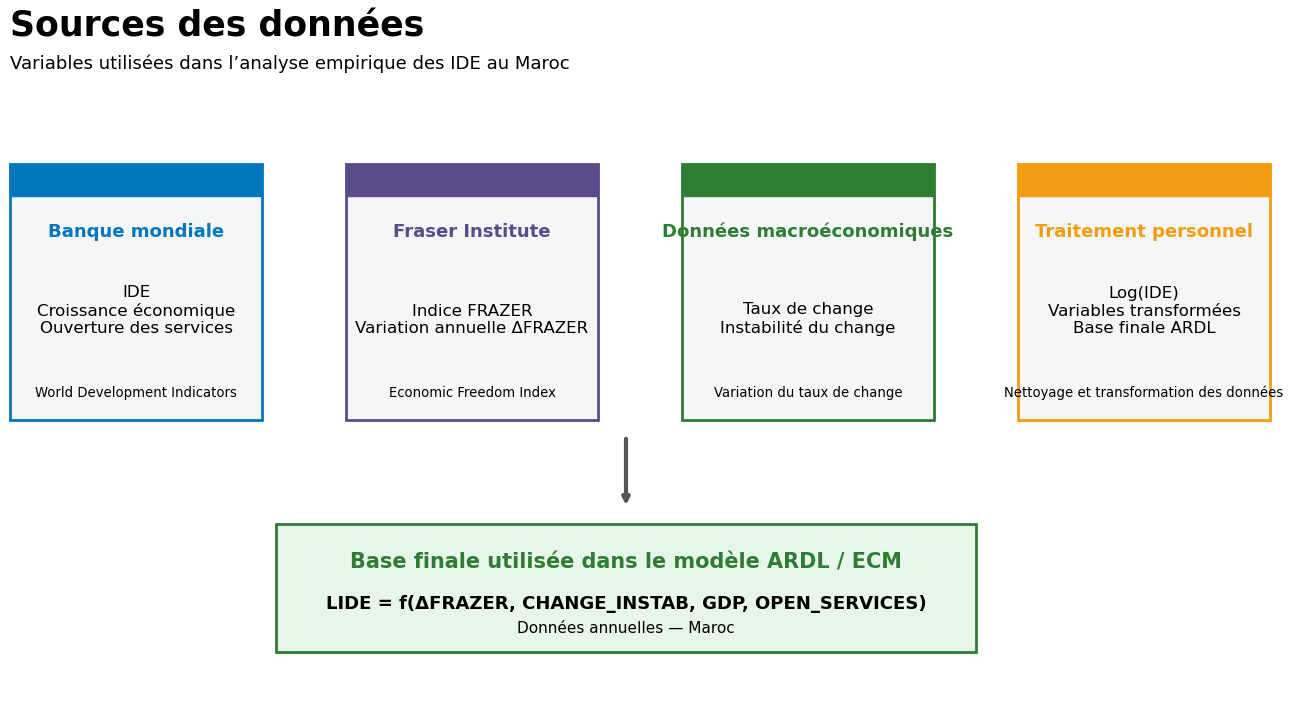

Slide exportée ici : C:\Users\dell\Desktop\sources_donnees_ardl.png


In [31]:
import matplotlib.pyplot as plt
from pathlib import Path

fig, ax = plt.subplots(figsize=(14, 8))
ax.axis("off")

# =========================
# TITRE
# =========================
fig.text(
    0.06, 0.93,
    "Sources des données",
    fontsize=25,
    fontweight="bold"
)

fig.text(
    0.06, 0.89,
    "Variables utilisées dans l’analyse empirique des IDE au Maroc",
    fontsize=13
)

# =========================
# SOURCES ET VARIABLES
# =========================
sources = [
    {
        "source": "Banque mondiale",
        "variables": "IDE\nCroissance économique\nOuverture des services",
        "detail": "World Development Indicators",
        "color": "#0277BD"
    },
    {
        "source": "Fraser Institute",
        "variables": "Indice FRAZER\nVariation annuelle ΔFRAZER",
        "detail": "Economic Freedom Index",
        "color": "#5B4B8A"
    },
    {
        "source": "Données macroéconomiques",
        "variables": "Taux de change\nInstabilité du change",
        "detail": "Variation du taux de change",
        "color": "#2E7D32"
    },
    {
        "source": "Traitement personnel",
        "variables": "Log(IDE)\nVariables transformées\nBase finale ARDL",
        "detail": "Nettoyage et transformation des données",
        "color": "#F39C12"
    }
]

x_positions = [0.06, 0.30, 0.54, 0.78]

for x, item in zip(x_positions, sources):
    # Carte
    rect = plt.Rectangle(
        (x, 0.45), 0.18, 0.32,
        transform=fig.transFigure,
        facecolor="#F4F6F8",
        edgecolor=item["color"],
        linewidth=2
    )
    fig.patches.append(rect)

    # Bande couleur
    band = plt.Rectangle(
        (x, 0.73), 0.18, 0.04,
        transform=fig.transFigure,
        facecolor=item["color"],
        edgecolor=item["color"]
    )
    fig.patches.append(band)

    # Source
    fig.text(
        x + 0.09, 0.68,
        item["source"],
        ha="center",
        fontsize=13,
        fontweight="bold",
        color=item["color"]
    )

    # Variables
    fig.text(
        x + 0.09, 0.56,
        item["variables"],
        ha="center",
        fontsize=12
    )

    # Détail
    fig.text(
        x + 0.09, 0.48,
        item["detail"],
        ha="center",
        fontsize=9.5
    )

# =========================
# FLÈCHE VERS MODÈLE
# =========================
ax.annotate(
    "",
    xy=(0.50, 0.34),
    xytext=(0.50, 0.43),
    xycoords=fig.transFigure,
    arrowprops=dict(arrowstyle="->", lw=3, color="#555555")
)

# Bloc final modèle
model_box = plt.Rectangle(
    (0.25, 0.16), 0.50, 0.16,
    transform=fig.transFigure,
    facecolor="#E8F5E9",
    edgecolor="#2E7D32",
    linewidth=2
)
fig.patches.append(model_box)

fig.text(
    0.50, 0.265,
    "Base finale utilisée dans le modèle ARDL / ECM",
    ha="center",
    fontsize=15,
    fontweight="bold",
    color="#2E7D32"
)

fig.text(
    0.50, 0.215,
    "LIDE = f(ΔFRAZER, CHANGE_INSTAB, GDP, OPEN_SERVICES)",
    ha="center",
    fontsize=13,
    fontweight="bold"
)

fig.text(
    0.50, 0.185,
    "Données annuelles — Maroc",
    ha="center",
    fontsize=11
)

# =========================
# EXPORT
# =========================
desktop = Path.home() / "Desktop"
file_path = desktop / "sources_donnees_ardl.png"

plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

print("Slide exportée ici :", file_path)

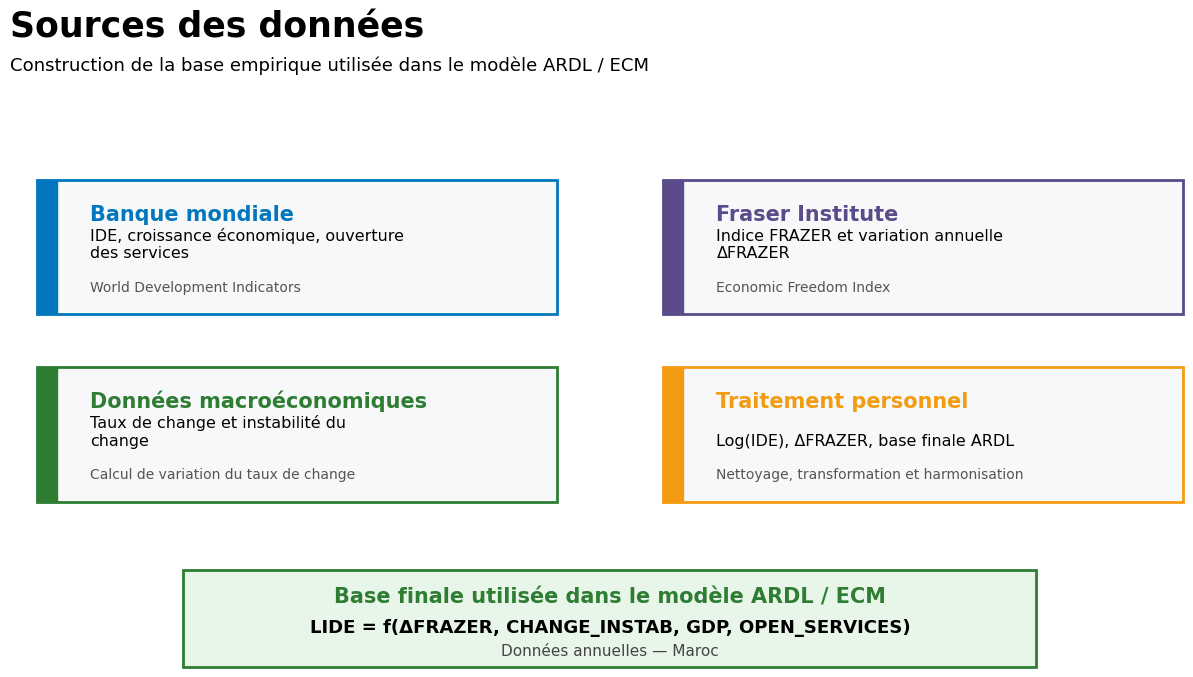

Slide exportée ici : C:\Users\dell\Desktop\sources_donnees_ardl_clean.png


In [32]:
import matplotlib.pyplot as plt
from pathlib import Path
import textwrap

def wrap_text(text, width=22):
    return "\n".join(textwrap.wrap(text, width=width))

fig, ax = plt.subplots(figsize=(13.33, 7.5))  # format 16:9
ax.axis("off")

# Titre
fig.text(
    0.05, 0.92,
    "Sources des données",
    fontsize=25,
    fontweight="bold"
)

fig.text(
    0.05, 0.875,
    "Construction de la base empirique utilisée dans le modèle ARDL / ECM",
    fontsize=13
)

# Sources
sources = [
    {
        "source": "Banque mondiale",
        "variables": "IDE, croissance économique, ouverture des services",
        "detail": "World Development Indicators",
        "color": "#0277BD"
    },
    {
        "source": "Fraser Institute",
        "variables": "Indice FRAZER et variation annuelle ΔFRAZER",
        "detail": "Economic Freedom Index",
        "color": "#5B4B8A"
    },
    {
        "source": "Données macroéconomiques",
        "variables": "Taux de change et instabilité du change",
        "detail": "Calcul de variation du taux de change",
        "color": "#2E7D32"
    },
    {
        "source": "Traitement personnel",
        "variables": "Log(IDE), ΔFRAZER, base finale ARDL",
        "detail": "Nettoyage, transformation et harmonisation",
        "color": "#F39C12"
    }
]

# Positions : 2 lignes x 2 colonnes
positions = [
    (0.07, 0.55),
    (0.54, 0.55),
    (0.07, 0.30),
    (0.54, 0.30)
]

card_w = 0.39
card_h = 0.18

for (x, y), item in zip(positions, sources):
    # Carte
    rect = plt.Rectangle(
        (x, y), card_w, card_h,
        transform=fig.transFigure,
        facecolor="#F6F8FA",
        edgecolor=item["color"],
        linewidth=2
    )
    fig.patches.append(rect)

    # Bande couleur à gauche
    band = plt.Rectangle(
        (x, y), 0.015, card_h,
        transform=fig.transFigure,
        facecolor=item["color"],
        edgecolor=item["color"]
    )
    fig.patches.append(band)

    # Source
    fig.text(
        x + 0.04, y + 0.125,
        item["source"],
        fontsize=15,
        fontweight="bold",
        color=item["color"]
    )

    # Variables
    fig.text(
        x + 0.04, y + 0.075,
        wrap_text(item["variables"], 38),
        fontsize=11.5
    )

    # Détail
    fig.text(
        x + 0.04, y + 0.030,
        wrap_text(item["detail"], 42),
        fontsize=10,
        color="#555555"
    )

# Bloc modèle final
model_box = plt.Rectangle(
    (0.18, 0.08), 0.64, 0.13,
    transform=fig.transFigure,
    facecolor="#E8F5E9",
    edgecolor="#2E7D32",
    linewidth=2
)
fig.patches.append(model_box)

fig.text(
    0.50, 0.165,
    "Base finale utilisée dans le modèle ARDL / ECM",
    ha="center",
    fontsize=15,
    fontweight="bold",
    color="#2E7D32"
)

fig.text(
    0.50, 0.125,
    "LIDE = f(ΔFRAZER, CHANGE_INSTAB, GDP, OPEN_SERVICES)",
    ha="center",
    fontsize=13,
    fontweight="bold"
)

fig.text(
    0.50, 0.095,
    "Données annuelles — Maroc",
    ha="center",
    fontsize=11,
    color="#444444"
)

# Export
desktop = Path.home() / "Desktop"
file_path = desktop / "sources_donnees_ardl_clean.png"

plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

print("Slide exportée ici :", file_path)

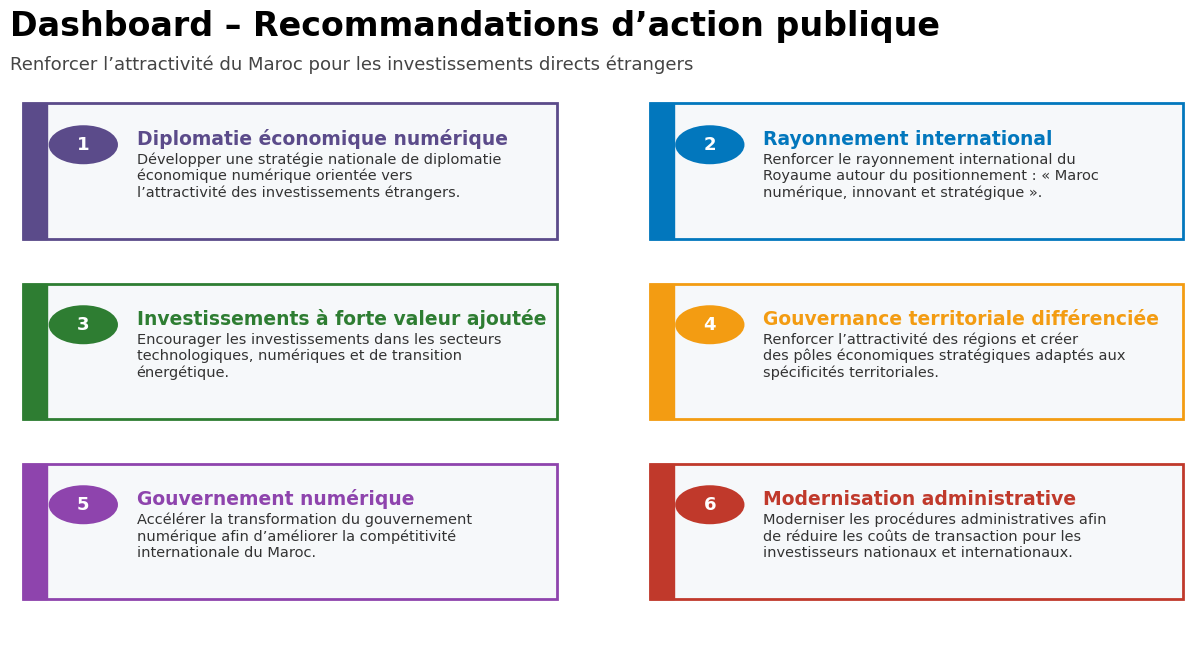

Dashboard exporté ici : C:\Users\dell\Desktop\dashboard_recommandations_action_publique.png


In [33]:
import matplotlib.pyplot as plt
from pathlib import Path
import textwrap

def wrap_text(text, width=42):
    return "\n".join(textwrap.wrap(text, width=width))

# =========================
# RECOMMANDATIONS
# =========================
recommendations = [
    {
        "num": "1",
        "title": "Diplomatie économique numérique",
        "text": "Développer une stratégie nationale de diplomatie économique numérique orientée vers l’attractivité des investissements étrangers.",
        "color": "#5B4B8A"
    },
    {
        "num": "2",
        "title": "Rayonnement international",
        "text": "Renforcer le rayonnement international du Royaume autour du positionnement : « Maroc numérique, innovant et stratégique ».",
        "color": "#0277BD"
    },
    {
        "num": "3",
        "title": "Investissements à forte valeur ajoutée",
        "text": "Encourager les investissements dans les secteurs technologiques, numériques et de transition énergétique.",
        "color": "#2E7D32"
    },
    {
        "num": "4",
        "title": "Gouvernance territoriale différenciée",
        "text": "Renforcer l’attractivité des régions et créer des pôles économiques stratégiques adaptés aux spécificités territoriales.",
        "color": "#F39C12"
    },
    {
        "num": "5",
        "title": "Gouvernement numérique",
        "text": "Accélérer la transformation du gouvernement numérique afin d’améliorer la compétitivité internationale du Maroc.",
        "color": "#8E44AD"
    },
    {
        "num": "6",
        "title": "Modernisation administrative",
        "text": "Moderniser les procédures administratives afin de réduire les coûts de transaction pour les investisseurs nationaux et internationaux.",
        "color": "#C0392B"
    }
]

# =========================
# FIGURE
# =========================
fig, ax = plt.subplots(figsize=(13.33, 7.5))  # 16:9
ax.axis("off")

# Titre
fig.text(
    0.05, 0.93,
    "Dashboard – Recommandations d’action publique",
    fontsize=24,
    fontweight="bold"
)

fig.text(
    0.05, 0.885,
    "Renforcer l’attractivité du Maroc pour les investissements directs étrangers",
    fontsize=13,
    color="#444444"
)

# =========================
# CARDS : 2 colonnes x 3 lignes
# =========================
positions = [
    (0.06, 0.66), (0.53, 0.66),
    (0.06, 0.42), (0.53, 0.42),
    (0.06, 0.18), (0.53, 0.18)
]

card_w = 0.40
card_h = 0.18

for (x, y), item in zip(positions, recommendations):
    # Carte
    rect = plt.Rectangle(
        (x, y), card_w, card_h,
        transform=fig.transFigure,
        facecolor="#F6F8FA",
        edgecolor=item["color"],
        linewidth=2
    )
    fig.patches.append(rect)

    # Bande couleur gauche
    band = plt.Rectangle(
        (x, y), 0.018, card_h,
        transform=fig.transFigure,
        facecolor=item["color"],
        edgecolor=item["color"]
    )
    fig.patches.append(band)

    # Cercle numéro
    circle = plt.Circle(
        (x + 0.045, y + 0.125),
        0.026,
        transform=fig.transFigure,
        facecolor=item["color"],
        edgecolor="none"
    )
    fig.patches.append(circle)

    fig.text(
        x + 0.045,
        y + 0.125,
        item["num"],
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
        color="white"
    )

    # Titre
    fig.text(
        x + 0.085,
        y + 0.125,
        item["title"],
        fontsize=13.5,
        fontweight="bold",
        color=item["color"]
    )

    # Texte
    fig.text(
        x + 0.085,
        y + 0.055,
        wrap_text(item["text"], 48),
        fontsize=10.5,
        color="#333333"
    )

# =========================
# EXPORT
# =========================
desktop = Path.home() / "Desktop"
file_path = desktop / "dashboard_recommandations_action_publique.png"

plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

print("Dashboard exporté ici :", file_path)

In [1]:
from pathlib import Path

project_dir = Path.home() / "Desktop" / "morocco-fdi-institutions-ardl"

folders = ["data", "results", "figures", "notebooks", "scripts"]

project_dir.mkdir(exist_ok=True)

for folder in folders:
    (project_dir / folder).mkdir(exist_ok=True)

print("Projet créé ici :", project_dir)


Projet créé ici : C:\Users\dell\Desktop\morocco-fdi-institutions-ardl


In [2]:
print(Path.cwd())

C:\Users\dell


In [ ]:
from pathlib import Path

matches = list(Path.home().rglob("ARDL CONFERANCE FINAL.ipynb"))

print("Résultats trouvés :")
for m in matches:
    print(m)